# **QM640 Data Analytics Capstone Project**

## **Machine Learning-Based One-Hour-Ahead PM2.5 Forecasting Using Environmental and Meteorological Data**

**Student:** Vinita R. Shetty

**Course:** QM640 Data Analytics Capstone

**Mentor:** Karthik Umesh Sharma

**Dataset:** Beijing Multi-Site Air Quality Dataset (UCI Machine Learning Repository)

## **Project Summary**

This notebook presents the complete analytical workflow for **one-hour-ahead PM2.5 forecasting** using the Beijing Multi-Site Air Quality Dataset.

The workflow includes:

* Data loading and integration
* Data quality assessment and preprocessing
* Exploratory Data Analysis
* Feature engineering
* One-hour-ahead target construction
* Development and comparison of eight machine learning regression models
* Chronological train-test evaluation
* Expanding-window time-series cross-validation
* **Gain-based feature importance analysis of the selected LightGBM model**
* **SHAP-based model explainability**
* Interpretation of model performance and predictive drivers

# **Problem Statement**

Urban air pollution poses significant environmental and public health challenges. Accurate short-term forecasting of **PM2.5 concentrations** can support air quality monitoring, early warning systems, public health advisories, and environmental decision-making.

This study develops and compares **eight supervised machine learning regression models** to forecast PM2.5 concentrations **one hour ahead** using current-hour air pollutant, meteorological, temporal, and monitoring-station information from the **Beijing Multi-Site Air Quality Dataset**.

Model performance is evaluated using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²)**.


# **Research Questions**

**RQ1.** Which current-hour pollutant and meteorological variables are most strongly associated with PM2.5 concentration one hour ahead?

**RQ2.** How accurately can machine learning regression models forecast PM2.5 concentration one hour ahead using current-hour pollutant, meteorological, temporal, wind-direction, and monitoring-station information?

**RQ3.** Which machine learning regression model provides the best predictive performance for one-hour-ahead PM2.5 forecasting?

**RQ4.** Which predictor variables contribute most strongly to the forecasts of the selected machine learning model?


# **Data Dictionary**

| Variable            | Description                                                             |
| ------------------- | ----------------------------------------------------------------------- |
| **PM2.5_next_hour** | Target variable representing PM2.5 concentration one hour ahead (µg/m³) |
| **PM2.5**           | Current-hour PM2.5 concentration (µg/m³)                                |
| **PM10**            | Current-hour particulate matter (≤10 µm) concentration (µg/m³)          |
| **SO₂**             | Current-hour sulfur dioxide concentration (µg/m³)                       |
| **NO₂**             | Current-hour nitrogen dioxide concentration (µg/m³)                     |
| **CO**              | Current-hour carbon monoxide concentration (mg/m³)                      |
| **O₃**              | Current-hour ozone concentration (µg/m³)                                |
| **TEMP**            | Current-hour air temperature (°C)                                       |
| **PRES**            | Current-hour atmospheric pressure (hPa)                                 |
| **DEWP**            | Current-hour dew point temperature (°C)                                 |
| **RAIN**            | Current-hour rainfall (mm)                                              |
| **WSPM**            | Current-hour wind speed (m/s)                                           |
| **wd**              | Current-hour wind direction                                             |
| **station**         | Air quality monitoring station                                          |
| **year**            | Year of observation                                                     |
| **month**           | Month of observation                                                    |
| **day**             | Day of observation                                                      |
| **hour**            | Hour of observation                                                     |


### **Note**

The target variable, **PM2.5_next_hour**, represents the PM2.5 concentration one hour ahead within the same monitoring station. It was constructed using the subsequent observed PM2.5 value after verifying that the time difference between consecutive observations was exactly one hour. All remaining variables represent information available at the current hour and were used as predictor variables during model development.


# **Environment Setup**

In [1]:
# ==========================================
# Install Required Packages
# ==========================================

!pip install xgboost lightgbm catboost shap -q   # Installs four ML libraries quietly (-q suppresses logs)

print("Required packages installed successfully!")  # Confirmation message


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.3 MB/s eta 0:00:00
Required packages installed successfully!


### **Note:**
*  The required external Python packages were successfully installed to support the machine learning modelling and model interpretation stages of the analysis.

# **1. Import Libraries**

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd                 # Pandas: data handling and DataFrames
import numpy as np                  # NumPy: numerical and mathematical operations

import matplotlib.pyplot as plt     # Matplotlib: plots and charts
import seaborn as sns               # Seaborn: statistical data visualization

# Machine Learning Models
from sklearn.linear_model import LinearRegression           # Linear Regression baseline
from sklearn.tree import DecisionTreeRegressor              # Decision Tree Regressor
from sklearn.ensemble import (                              # Ensemble models
    RandomForestRegressor,                                  # Random Forest
    GradientBoostingRegressor,                              # Gradient Boosting
    AdaBoostRegressor                                       # AdaBoost
)

# Time-Series Validation
from sklearn.model_selection import TimeSeriesSplit         # Chronological CV splitter

# Model Evaluation Metrics
from sklearn.metrics import (                               # Performance metrics
    mean_absolute_error,            # MAE: average absolute prediction error
    mean_squared_error,             # MSE: squared prediction error
    r2_score                        # R²: proportion of variance explained
)

# Advanced Machine Learning Models
from xgboost import XGBRegressor                            # XGBoost Regressor
from lightgbm import LGBMRegressor                          # LightGBM Regressor
from catboost import CatBoostRegressor                      # CatBoost Regressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")                           # Suppress warnings for clean output

# Display settings
pd.set_option("display.max_columns", None)                  # Show all columns in DataFrames

print("Libraries imported successfully!")                   # Confirmation message


Libraries imported successfully!


### **Interpretation**

* All the required Python libraries for data manipulation, visualization, machine learning, and model evaluation were successfully imported. This confirms that the computational environment was properly configured before proceeding with data loading, preprocessing, exploratory data analysis, and predictive modeling.

## **1.1 Mount Google Drive**

In [3]:
from google.colab import drive        # Import the Colab Drive module, which lets you mount Google Drive
drive.mount('/content/drive')         # Mount your Google Drive at the folder path '/content/drive'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Interpretation**

* Google Drive was successfully mounted, enabling access to the project dataset and associated files stored in the user's Drive. This ensured that the data could be loaded directly into the Colab environment for subsequent preprocessing, analysis, and model development.

# **2. Data Loading and Integration**

* The dataset consists of **hourly air quality and meteorological observations** collected from **12 monitoring stations in Beijing**.

* The individual station datasets were combined into a single DataFrame to create an integrated dataset for subsequent **data preprocessing, exploratory analysis, and one-hour-ahead PM2.5 forecasting**.


## **2.1 Locate the Dataset**
* The project directory was inspected to verify that the required dataset files were available in Google Drive before loading and integrating the data.

In [4]:
import os                                      # Import Python’s built-in OS module for file and directory operations

base_path = "/content/drive/MyDrive/QM640_Air_Quality_Capstone"
# Define the base directory path where your project files are stored in Google Drive

for root, dirs, files in os.walk(base_path):   # Recursively walk through the directory tree starting at base_path
    for file in files:                         # Loop through each file found in the current folder
        print(os.path.join(root, file))        # Print the full file path by joining folder path (root) and file name


/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Aotizhongxin_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Changping_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Dingling_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Dongsi_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Guanyuan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Gucheng_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Huairou_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Nongzhanguan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Shunyi_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Tiantan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quali

### **Interpretation**

* The dataset consists of **12 CSV files**, each representing hourly air quality and meteorological observations from a different monitoring station in Beijing.

* The files collectively cover the period from **1 March 2013 to 28 February 2017** and contain measurements of major air pollutants and meteorological variables.

* Combining data from all 12 monitoring stations provides a comprehensive multi-location dataset covering different environmental conditions across Beijing.

* This integrated dataset supports the development and evaluation of machine learning models for **one-hour-ahead PM2.5 forecasting**.


## **2.2 Load and Combine All Air Quality Datasets**

In [5]:
# ==========================================
# Load and Combine All Air Quality Datasets
# ==========================================

import os                                   # OS module for file and directory operations
import glob                                 # Glob module for pattern matching file paths
import pandas as pd                         # Pandas for data handling and analysis

# Folder containing all CSV files
folder_path = "/content/drive/MyDrive/QM640_Air_Quality_Capstone/data"
# Define the path to the folder where all your CSV datasets are stored

# Find all CSV files
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
# Use glob to search for all files ending with .csv inside the folder

print(f"Number of CSV files found: {len(csv_files)}")
# Print how many CSV files were found in the folder

# Read and combine all files
df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)
# Read each CSV file into a DataFrame and combine them into one large DataFrame
# ignore_index=True resets the row index so it runs continuously across all files

print("Dataset loaded successfully!")
# Confirmation message once the dataset is combined

# Display first five rows
df.head()
# Show the first 5 rows of the combined dataset to verify it loaded correctly


Number of CSV files found: 12
Dataset loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### **Interpretation**

* A total of **12 CSV files**, representing different Beijing air quality monitoring stations, were successfully identified and combined into a single dataset.

* The combined dataset was loaded successfully, and the preview confirms that observations from the station-level files are available for subsequent analysis.

* The dataset contains **temporal variables, air pollutant concentrations, meteorological variables, and monitoring station information**.

* The current-hour PM2.5 measurements and other available predictor variables will subsequently be used to develop machine learning models for **one-hour-ahead PM2.5 forecasting**.


 ## **2.3 Initial Data Inspection**
* The first and last five records are displayed to verify that the datasets have been merged correctly and to obtain an initial understanding of the dataset structure.

### **2.3.1 First Five Records of the Dataset**

In [6]:
print("First Five Records")     # Print a header message to indicate what is being displayed

df.head()                       # Show the first 5 rows of the DataFrame 'df'
                                # Useful for quickly checking that the dataset loaded correctly
                                # and to preview the structure, column names, and sample values

First Five Records


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### **Interpretation**

* The first five records provide an initial overview of the **integrated air quality dataset**.

* Each row represents an **hourly observation** containing temporal information, pollutant concentrations, meteorological variables, and the monitoring station name.

* The preview shows that the dataset is organized in a structured tabular format with the expected variables available for subsequent analysis.

* The available variables provide the information required for **data preprocessing, exploratory data analysis, and the subsequent development of machine learning models for one-hour-ahead PM2.5 forecasting**.

### **2.3.2 Last Five Records of the Dataset**

In [7]:
print("Last Five Records")     # Print a header message to indicate what is being displayed

df.tail()                      # Show the last 5 rows of the DataFrame 'df'
                               # Useful for checking the dataset’s ending rows
                               # Helps confirm that all files were combined correctly
                               # and lets you preview how the dataset concludes


Last Five Records


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong
420767,35064,2017,2,28,23,13.0,19.0,4.0,38.0,600.0,49.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Wanshouxigong


### **Interpretation**

* The last five records provide a view of the final observations in the integrated dataset and show data from the **Wanshouxigong monitoring station**.

* The records maintain the same structure as the initial observations, containing temporal information, air pollutant concentrations, meteorological variables, and the monitoring station identifier.

* The final records correspond to **28 February 2017**, which is consistent with the stated end date of the study period.

* Together with the first-record inspection, this provides an initial verification of the structure and temporal coverage of the combined dataset. Further checks on dataset dimensions, monitoring stations, missing values, duplicates, and data types are performed during subsequent data inspection and preprocessing.

* The integrated dataset will subsequently be prepared for **one-hour-ahead PM2.5 forecasting**.

# **3. Dataset Overview**
* This section examines the overall dimensions, variables, data types, descriptive statistics, and missing values before data preprocessing.

## **3.1 Dataset Dimensions**

In [8]:
df.shape                          # Returns a tuple with (number of rows, number of columns)
                                  # First value = total records in the dataset
                                  # Second value = total features/columns in the dataset
                                  # Useful for quickly checking dataset size and structure


(420768, 18)

### **Interpretation**

* The integrated dataset contains **420,768 observations and 18 variables**, confirming that a substantial volume of hourly air quality and meteorological data is available for analysis.

* The 18 variables include **temporal information, air pollutant concentrations, meteorological parameters, wind direction, and the monitoring station identifier**.

* The large number of observations provides sufficient data for **exploratory data analysis, feature engineering, model development, and time-based model evaluation**.

* The available variables provide a comprehensive set of information for developing machine learning models for **one-hour-ahead PM2.5 forecasting**.

## **3.2 Data Types**

In [9]:
df.info()
# Displays a concise summary of the DataFrame 'df'
# Shows:
#   - Index range (row count)
#   - Column names
#   - Number of non-null (non-missing) values per column
#   - Data types of each column (int, float, object, etc.)
#   - Memory usage of the DataFrame
# Useful for quickly checking dataset structure, column types, and missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


### **Interpretation**

* The dataset contains **420,768 observations and 18 variables**, consisting of **5 integer variables, 11 floating-point variables, and 2 object-type variables**.

* The integer variables primarily represent temporal and record-related information, while the floating-point variables contain air pollutant concentrations and meteorological measurements.

* The two object-type variables are **wind direction (`wd`)** and **monitoring station (`station`)**, which are categorical variables and will require appropriate encoding before machine learning model development.

* Several variables, including **PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, and WSPM**, contain missing values. These will be examined and handled during the data preprocessing stage.

* The dataset uses approximately **57.8 MB of memory**, indicating that the complete integrated dataset can be handled efficiently within the current computational environment.

* The combination of pollutant, meteorological, temporal, and categorical information provides the predictor information required for subsequent exploratory analysis, feature engineering, and **one-hour-ahead PM2.5 forecasting**.

## **3.3 Variable Names**

In [10]:
df.columns                       # Returns all column names in the DataFrame
                                 # Output is an Index object listing features/variables
                                 # Useful for quickly checking dataset structure


Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

### **Interpretation**

* The dataset contains **18 columns**, including the record identifier (**No**), temporal variables (**year**, **month**, **day**, and **hour**), air pollutant variables (**PM2.5**, **PM10**, **SO2**, **NO2**, **CO**, and **O3**), meteorological variables (**TEMP**, **PRES**, **DEWP**, **RAIN**, and **WSPM**), wind direction (**wd**), and the monitoring station identifier (**station**).

* The column names are clearly defined and consistently labelled, facilitating systematic data preprocessing, exploratory data analysis, feature engineering, and machine learning model development.

* The dataset contains both **numerical and categorical variables**, providing information on pollutant levels, meteorological conditions, time, and monitoring location that can be examined as potential predictors of **one-hour-ahead PM2.5 concentrations**.

* The `No` column functions as a **record identifier** and does not represent an environmental, meteorological, temporal, or location-related predictor. Therefore, it is excluded during the feature selection stage before machine learning model development.

## **3.4 Summary Statistics**

In [11]:
df.describe().T                 # Generates summary statistics for numeric columns
                                # Includes count, mean, std, min, 25%, 50%, 75%, max
                                # '.T' transposes the table so each column’s stats are listed vertically
                                # Easier to scan values feature by feature


,count,mean,std,min,25%,50%,75%,max
No,420768.0,17532.500000,10122.116943,1.0000,8766.75,17532.5,26298.25,35064.0
year,420768.0,2014.662560,1.177198,2013.0000,2014.00,2015.0,2016.00,2017.0
month,420768.0,6.522930,3.448707,1.0000,4.00,7.0,10.00,12.0
day,420768.0,15.729637,8.800102,1.0000,8.00,16.0,23.00,31.0
hour,420768.0,11.500000,6.922195,0.0000,5.75,11.5,17.25,23.0
PM2.5,412029.0,79.793428,80.822391,2.0000,20.00,55.0,111.00,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.00,82.0,145.00,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.00,7.0,20.00,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.00,43.0,71.00,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.00,900.0,1500.00,10000.0


### **Interpretation**

#### **PM2.5**

* The average **PM2.5** concentration is **79.79 µg/m³**, with values ranging from **2** to **999 µg/m³**, indicating substantial variation in fine particulate matter concentrations across the observations.
* The maximum value is considerably higher than the upper quartile (**111 µg/m³**), suggesting the presence of potential extreme observations that require further assessment.

#### **PM10**

* **PM10** concentrations have a mean of **104.60 µg/m³** and range from **2** to **999 µg/m³**, indicating considerable variability throughout the study period.
* Similar to PM2.5, the maximum value is substantially higher than the upper quartile (**145 µg/m³**), suggesting potential extreme observations.

#### **SO₂**

* **SO₂** concentrations have a mean of **15.83 µg/m³** and range from **0.29** to **500 µg/m³**, indicating generally lower concentrations with occasional elevated observations.

#### **NO₂**

* **NO₂** has an average concentration of **50.64 µg/m³**, with values ranging from **1.03** to **290 µg/m³**, demonstrating substantial variability across the dataset.

#### **CO**

* **CO** concentrations range from **100** to **10,000**, with a mean of **1,230.77**, indicating considerable variation in carbon monoxide levels.

#### **O₃**

* **O₃** concentrations vary considerably, with values ranging from **0.21** to **1,071 µg/m³**, reflecting substantial variation in ozone concentrations across the observations.

#### **TEMP**

* **Temperature (TEMP)** ranges from **−19.9°C** to **41.6°C**, demonstrating the wide seasonal variation captured during the study period.

#### **PRES**

* **Atmospheric pressure (PRES)** has a mean of **1,010.75 hPa**, with a relatively small standard deviation of **10.47 hPa**, indicating comparatively limited variation across the observations.

#### **DEWP**

* **Dew point (DEWP)** ranges from **−43.4°C** to **29.1°C**, indicating substantial variation in atmospheric moisture conditions.

#### **RAIN**

* **Rainfall (RAIN)** is zero for at least 75% of the observations, as indicated by both the median and 75th percentile being **0 mm**, while occasional rainfall events are reflected by the maximum value of **72.5 mm**.

#### **WSPM**

* **Wind speed (WSPM)** has an average value of **1.73 m/s**, with observations ranging from **0** to **13.2 m/s**, indicating varying wind conditions throughout the study period.

#### **Overall Observation**

* The descriptive statistics indicate substantial variability in both air pollutant concentrations and meteorological conditions across the dataset.
* Several variables exhibit maximum values substantially higher than their upper quartiles, suggesting **potential extreme observations** that will be further examined during data preprocessing.
* The diversity of pollutant, meteorological, and temporal information provides a strong foundation for developing machine learning models for **one-hour-ahead PM2.5 forecasting**.


## **3.5 Missing Value Summary**

In [12]:
df.isnull().sum()              # Counts missing (null) values in each column
                               # .isnull() creates True/False mask (True = missing)
                               # .sum() adds up True values per column
                               # Result: number of nulls per column


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


### **Interpretation**

#### **Overall Missing Values**

* The dataset contains missing values in several air pollutant and meteorological variables, while the temporal variables (**No, year, month, day, and hour**) and the **station** identifier contain no missing values.

#### **Air Pollutant Variables**

* Missing values are observed in **PM2.5 (8,739)**, **PM10 (6,449)**, **SO₂ (9,021)**, **NO₂ (12,116)**, **CO (20,701)**, and **O₃ (13,277)**.
* Among the air pollutant variables, **CO** has the highest number of missing observations, followed by **O₃** and **NO₂**.

#### **Meteorological Variables**

* The meteorological variables contain comparatively fewer missing values, including **TEMP (398)**, **PRES (393)**, **DEWP (403)**, **RAIN (390)**, and **WSPM (318)**.
* The categorical wind direction variable (**wd**) contains **1,822 missing observations**.

#### **Overall Observation**

* Missing values are present across several predictor variables and therefore require appropriate handling during the data preprocessing stage before exploratory analysis and machine learning model development.
* Since the study focuses on **one-hour-ahead PM2.5 forecasting**, the missing-value treatment should preserve the temporal structure of the data and avoid introducing information from future observations into earlier time periods.
* The specific missing-value handling strategy will therefore be applied and documented during the preprocessing stage before model development.


## **3.6 Monitoring Stations**

In [13]:
# Number of monitoring stations
df['station'].nunique()      # Counts unique values in the 'station' column
                             # Returns total distinct monitoring stations in the dataset


12

### **Interpretation**

* The dataset contains observations from **12 unique air quality monitoring stations** across Beijing.

* The inclusion of multiple monitoring stations provides multi-location coverage, allowing the analysis to capture variations in air pollutant concentrations and meteorological conditions across different monitoring locations.

* Combining observations from all **12 stations** increases the diversity of environmental conditions represented in the integrated dataset.

* The **station** variable is retained as location-related information and will subsequently be encoded for use in the machine learning models for **one-hour-ahead PM2.5 forecasting**.

## **3.7 Time Period Covered**

In [14]:
# Date range
print("Start Year:", df['year'].min())   # Finds the smallest (earliest) year in the 'year' column
print("End Year:", df['year'].max())     # Finds the largest (latest) year in the 'year' column


Start Year: 2013
End Year: 2017


### **Interpretation**

* The dataset contains hourly air quality and meteorological observations spanning the calendar years **2013 to 2017**.

* The inclusion of observations across multiple years provides substantial temporal coverage for examining variations in pollutant concentrations and meteorological conditions.

* The multi-year dataset enables subsequent exploratory analysis of **temporal and seasonal patterns** in PM2.5 and related environmental variables.

* This temporal structure is particularly important for the forecasting framework because the machine learning models will be trained and evaluated using a **chronological approach**, preserving the natural ordering of observations for **one-hour-ahead PM2.5 forecasting**.

## **3.8 Air Pollutants Considered**

In [15]:
# Number of pollutants
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']   # Define a list of pollutant names
print(pollutants)                                          # Print the list to confirm or display


['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']


### **Interpretation**

* The dataset contains six major air pollutant variables: **PM2.5, PM10, SO2, NO2, CO, and O3**.

* These pollutant variables provide information on different aspects of ambient air quality and allow their relationships with **PM2.5** concentrations to be examined during exploratory analysis.

* In the forecasting framework, current-hour pollutant measurements are retained as potential predictor variables for forecasting **PM2.5 concentration one hour ahead**.

* Their predictive contribution will subsequently be evaluated through model performance, feature importance, and model interpretation analyses.

# **4. Data Preprocessing**

## **4.1 Data Quality Assessment**

* Before preprocessing, the integrated dataset was assessed for **completeness, consistency, and overall data quality**. Missing values, duplicate records, and the distribution of numerical variables were examined to identify potential data quality issues and guide subsequent preprocessing decisions.

* This assessment was conducted before exploratory analysis and machine learning model development to ensure that the preprocessing strategy was appropriate for the **one-hour-ahead PM2.5 forecasting framework**.

## **4.2 Missing Value Analysis**

In [16]:
# ==========================================
# Missing Values Analysis
# ==========================================

# Count missing values in each variable
missing_values = df.isnull().sum()                          # Number of NaNs per column

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(df)) * 100       # % of NaNs relative to dataset size

# Create a summary table containing missing counts and percentages
missing_df = pd.DataFrame({                                 # Build DataFrame with counts + %
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

# Retain only variables containing missing values
missing_df = missing_df[missing_df["Missing Values"] > 0]   # Filter out columns with no missing data

# Sort variables from highest to lowest percentage of missing values
missing_df = missing_df.sort_values(                        # Sort by % descending
    by="Percentage (%)",
    ascending=False
)

# Display the missing values summary
display(missing_df)                                         # Show table of missing values + %


,Missing Values,Percentage (%)
CO,20701,4.919813
O3,13277,3.155421
NO2,12116,2.879497
SO2,9021,2.143937
PM2.5,8739,2.076916
PM10,6449,1.532674
wd,1822,0.433018
DEWP,403,0.095777
TEMP,398,0.094589
PRES,393,0.093401


### **Interpretation**

#### **Missing Values Overview**

* Missing values are present in **12 variables**, while the remaining variables contain complete observations.

* No variable has more than **5% missing data**, indicating that missingness is relatively limited compared with the overall dataset size.

#### **Air Pollutant Variables**

* **CO** has the highest proportion of missing values, with **20,701 observations (4.92%)**, followed by **O3 (3.16%)**, **NO2 (2.88%)**, **SO2 (2.14%)**, **PM2.5 (2.08%)**, and **PM10 (1.53%)**.

* Although missing observations are present across all six pollutant variables, each pollutant retains more than **95% of its observations**.

#### **Meteorological Variables**

* The numerical meteorological variables contain comparatively few missing observations, with missing percentages below **0.1%**.

* The categorical wind direction variable (**wd**) also contains a relatively small proportion of missing observations (**0.43%**).

#### **Overall Observation**

* The missing-value analysis indicates that the dataset is largely complete, although missing observations require appropriate handling before subsequent analysis and machine learning model development.

* Because the study uses a **time-based forecasting framework**, the missing-value treatment should preserve the chronological structure of the data and avoid introducing information from future observations into earlier observations.

* The specific treatment of missing values is therefore addressed in the subsequent preprocessing stage.

## **4.3 Visualize Missing Values**

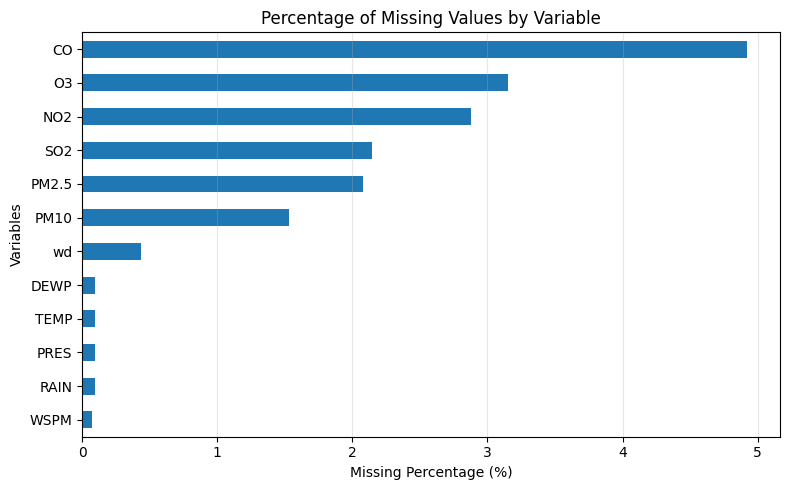

In [17]:
# ==========================================
# Visualize Missing Values
# ==========================================

import matplotlib.pyplot as plt

# Sort missing percentages in ascending order for horizontal plotting
plot_data = missing_df.sort_values(                        # Sort by % ascending
    by="Percentage (%)",
    ascending=True                                         # So least missing at bottom, most at top
)

# Create horizontal bar chart
plot_data.plot(                                            # Plot DataFrame
    kind="barh",                                           # Horizontal bar chart
    y="Percentage (%)",                                    # Use % column for bar length
    legend=False,                                          # Hide legend (not needed)
    figsize=(8, 5)                                         # Set figure size
)

# Add chart labels and title
plt.xlabel("Missing Percentage (%)")                       # Label x-axis
plt.ylabel("Variables")                                    # Label y-axis
plt.title("Percentage of Missing Values by Variable")      # Chart title

# Add gridlines for easier comparison
plt.grid(axis="x", alpha=0.3)                              # Light grid on x-axis

# Adjust layout and display the chart
plt.tight_layout()                                         # Optimize spacing
plt.show()                                                 # Render chart


### **Interpretation**

#### **Missing Values Distribution**

* The bar chart provides a visual comparison of the percentage of missing observations across variables containing missing data.

* **CO** has the highest percentage of missing values at approximately **4.92%**, followed by **O3 (3.16%)**, **NO2 (2.88%)**, **SO2 (2.14%)**, **PM2.5 (2.08%)**, and **PM10 (1.53%)**.

#### **Meteorological Variables**

* The numerical meteorological variables contain substantially lower levels of missing data, with missing percentages below **0.1%**.

* Wind direction (**wd**) also contains a relatively small proportion of missing observations (**0.43%**) compared with the overall dataset.

#### **Overall Observation**

* The visualization confirms that no variable exceeds **5% missing observations**, with the highest level of missingness occurring in **CO**.

* Missingness is therefore limited relative to the total dataset size, but appropriate treatment is still required before exploratory analysis and machine learning model development.

* The missing-value handling strategy will be selected with consideration of the **temporal structure of the data and the one-hour-ahead forecasting objective**.

## **4.4 Distribution Analysis of Numerical Variables**

In [18]:
# ==========================================
# Distribution Analysis of Numerical Variables
# ==========================================

# Define numerical variables for distribution analysis
numerical_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Generate descriptive statistics
summary_stats = df[numerical_cols].describe().T

print("=" * 60)
print("DESCRIPTIVE STATISTICS OF NUMERICAL VARIABLES")
print("=" * 60)

display(summary_stats)

# Calculate skewness for each numerical variable
skewness = df[numerical_cols].skew().sort_values(
    ascending=False
)

print("\n" + "=" * 60)
print("SKEWNESS OF NUMERICAL VARIABLES")
print("=" * 60)

display(skewness.to_frame(name="Skewness"))

DESCRIPTIVE STATISTICS OF NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
PM2.5,412029.0,79.793428,80.822391,2.0000,20.0,55.0,111.0,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.0,82.0,145.0,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.0,7.0,20.0,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.0,43.0,71.0,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.0,900.0,1500.0,10000.0
O3,407491.0,57.372271,56.661607,0.2142,11.0,45.0,82.0,1071.0
TEMP,420370.0,13.538976,11.436139,-19.9000,3.1,14.5,23.3,41.6
PRES,420375.0,1010.746982,10.474055,982.4000,1002.3,1010.4,1019.0,1042.8
DEWP,420365.0,2.490822,13.793847,-43.4000,-8.9,3.1,15.1,29.1
RAIN,420378.0,0.064476,0.821004,0.0000,0.0,0.0,0.0,72.5



SKEWNESS OF NUMERICAL VARIABLES


,Skewness
RAIN,30.043633
SO2,3.009503
CO,2.570129
PM2.5,2.013975
PM10,1.885835
O3,1.660095
WSPM,1.625590
NO2,1.050055
PRES,0.106314
TEMP,-0.104267


### **Interpretation**

#### **Distribution of Numerical Variables**

* The skewness analysis indicates that several numerical variables have asymmetric distributions, with substantial variation in the degree of skewness across the dataset.

* **DEWP (-0.19)** and **TEMP (-0.10)** exhibit slight negative skewness, while **PRES (0.11)** is approximately symmetric, indicating relatively balanced distributions for these meteorological variables.

#### **Air Pollutant Variables**

* All six air pollutant variables exhibit **positive skewness**, indicating that observations are concentrated primarily at lower to moderate concentrations, with fewer observations occurring at substantially higher levels.

* **SO₂ (3.01)** and **CO (2.57)** show particularly strong positive skewness, followed by **PM2.5 (2.01)**, **PM10 (1.89)**, **O₃ (1.66)**, and **NO₂ (1.05)**.

* The large maximum values observed for several pollutants, such as **PM2.5 and PM10 (999 µg/m³)** and **CO (10,000 µg/m³)**, further indicate the presence of high-concentration observations that warrant examination during outlier analysis.

#### **Meteorological Variables**

* **Wind Speed (WSPM)** is positively skewed (**1.63**), indicating that lower wind speeds occur more frequently than very high wind speeds.

* **Rainfall (RAIN)** exhibits extremely high positive skewness (**30.04**). Its median and both the 25th and 75th percentiles are **0**, indicating that rainfall is absent for a large proportion of the hourly observations, while relatively few observations record substantial rainfall.

#### **Overall Observation**

* The descriptive statistics reveal substantial differences in the distributions and variability of the numerical variables, particularly among the pollutant measurements and rainfall.

* The strongly skewed distributions and high maximum values indicate the presence of potential extreme observations. These values should therefore be examined during the subsequent outlier analysis rather than automatically removed, as some may represent genuine high-pollution or meteorological events relevant to the forecasting objective.

## **4.5 Duplicate Record Analysis**

In [19]:
# ==========================================
# Duplicate Record Analysis
# ==========================================

# Count the total number of completely duplicated rows
duplicate_count = df.duplicated().sum()                     # .duplicated() flags duplicate rows, .sum() counts them

# Display the number of duplicate records
print(f"Number of duplicate records: {duplicate_count}")    # Print total duplicate count


Number of duplicate records: 0


### **Interpretation**

* The dataset contains **no duplicate records**, indicating that each row represents a unique observation in the dataset.

* Therefore, **no duplicate records were removed**, and the dataset was retained without modification at this stage of preprocessing.

## **4.6 Feature Engineering - Create Datetime**

In [20]:
# ==========================================
# Feature Engineering
# Create Datetime Variable
# ==========================================

# Combine year, month, day, and hour into a single datetime variable
df["datetime"] = pd.to_datetime(                            # Build datetime column
    df[["year", "month", "day", "hour"]]                    # Combine year, month, day, hour
)

# Display the first few datetime values with monitoring station
display(df[["datetime", "station"]].head())                 # Preview datetime + station columns

# Verify the complete temporal coverage
print("Earliest Date and Time:", df["datetime"].min())      # Print earliest timestamp
print("Latest Date and Time:", df["datetime"].max())        # Print latest timestamp


,datetime,station
0,2013-03-01 00:00:00,Aotizhongxin
1,2013-03-01 01:00:00,Aotizhongxin
2,2013-03-01 02:00:00,Aotizhongxin
3,2013-03-01 03:00:00,Aotizhongxin
4,2013-03-01 04:00:00,Aotizhongxin


Earliest Date and Time: 2013-03-01 00:00:00
Latest Date and Time: 2017-02-28 23:00:00


### **Interpretation**

#### **Feature Engineering**

* A new **datetime** feature was created by combining the existing **year, month, day, and hour** variables into a single timestamp.

* The resulting datetime feature spans from **March 1, 2013 at 00:00** to **February 28, 2017 at 23:00**, representing approximately four years of hourly observations.

* The **station** variable was retained to identify the monitoring location associated with each observation.

* The preview confirms that the datetime feature was created successfully and that each timestamp remains correctly associated with its corresponding monitoring station.

#### **Overall Observation**

* Creating the datetime feature provides a consistent temporal reference for arranging observations chronologically within each monitoring station.

* This temporal structure is essential for the subsequent **one-hour-ahead target construction, chronological train-test split, time-series cross-validation, and PM2.5 forecasting framework**.

## **4.7 Create One-Hour-Ahead Forecasting Target**

In [21]:
# ============================================================
# One-Hour-Ahead PM2.5 Forecasting Dataset
# ============================================================

# Sort observations chronologically within each monitoring station
df = df.sort_values(
    by=['station', 'datetime']                            # Sort by station and timestamp
).reset_index(drop=True)

# Obtain the timestamp of the next observation per station
df['next_datetime'] = (
    df.groupby('station')['datetime'].shift(-1)           # Shift datetime up by 1 row
)

# Obtain the PM2.5 value of the next observation per station
df['PM2.5_next_hour'] = (
    df.groupby('station')['PM2.5'].shift(-1)              # Shift PM2.5 up by 1 row
)

# Calculate time difference between consecutive observations
df['time_gap'] = (
    df['next_datetime'] - df['datetime']                  # Difference between current and next timestamp
)

# Retain only observations where the next reading is exactly one hour later
df_forecast = df[
    df['time_gap'] == pd.Timedelta(hours=1)               # Filter rows with 1-hour gap
].copy()


## **4.8 Missing Value Imputation**

In [22]:
# ==========================================
# Missing Value Imputation
# ==========================================

# Define numerical variables containing missing values
numerical_cols = [                                          # List of numeric columns to impute
     'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# ------------------------------------------------------------
# Sort observations chronologically within each station
# ------------------------------------------------------------

df = df.sort_values(                                        # Ensure time order per station
    by=['station', 'year', 'month', 'day', 'hour']          # Sort by station + timestamp parts
).reset_index(drop=True)                                    # Reset index after sorting

# ------------------------------------------------------------
# Forward-fill missing numerical values within each station
# Uses only previously observed values
# ------------------------------------------------------------

df[numerical_cols] = (                                      # Fill missing numeric values
    df.groupby('station')[numerical_cols]                   # Group by station
      .ffill()                                              # Forward-fill within each station
)

# ------------------------------------------------------------
# Forward-fill missing wind direction within each station
# ------------------------------------------------------------

df['wd'] = (                                                # Fill missing categorical values
    df.groupby('station')['wd']                             # Group by station
      .ffill()                                              # Forward-fill wind direction
)

# ------------------------------------------------------------
# Remove observations that still contain missing values
# after forward filling.
# These observations cannot be forward-filled because no
# previous valid observation is available within the station.
# ------------------------------------------------------------

required_cols = numerical_cols + ['PM2.5', 'wd']                  # Columns required for modeling

remaining_before_drop = df[required_cols].isnull().any(axis=1).sum()
# Count rows still containing missing values after forward fill

df = df.dropna(                                             # Drop rows with missing values
    subset=required_cols                                    # Only check required columns
).reset_index(drop=True)                                    # Reset index after dropping

# ------------------------------------------------------------
# Verify missing values after preprocessing
# ------------------------------------------------------------

print("=" * 60)
print("MISSING VALUE IMPUTATION COMPLETED")
print("=" * 60)

print(                                                      # Report how many rows were removed
    "Rows removed because no previous observation was "
    "available for forward filling:",
    remaining_before_drop
)

print("\nRemaining Missing Values:")

display(                                                    # Show missing counts per column
    df[required_cols]
      .isnull()
      .sum()
      .to_frame(name="Missing Values")
)

print(                                                      # Show total missing values
    "\nTotal Remaining Missing Values:",
    df[required_cols].isnull().sum().sum()
)

print("\nDataset Shape After Missing Value Handling:", df.shape)
# Show final dataset dimensions


MISSING VALUE IMPUTATION COMPLETED
Rows removed because no previous observation was available for forward filling: 8761

Remaining Missing Values:


,Missing Values
PM10,0
SO2,0
NO2,0
CO,0
O3,0
TEMP,0
PRES,0
DEWP,0
RAIN,0
WSPM,0



Total Remaining Missing Values: 0

Dataset Shape After Missing Value Handling: (412007, 22)


### **Interpretation**

#### **Missing Value Treatment**

* Missing values were handled using **station-wise forward filling**, with observations first arranged in chronological order within each monitoring station.
* This approach uses the most recently available preceding observation within the same station and therefore preserves the **temporal structure of the dataset** without using future observations to fill earlier missing values.
* **8,761 observations** were removed because no previous observation was available within the corresponding station to provide a value.

#### **Post-Imputation Verification**

* Following missing-value treatment, all required pollutant, meteorological, and wind-direction variables contained **zero missing values**.
* The dataset size decreased from **420,768 to 412,007 observations**, meaning that approximately **97.92% of the original observations were retained**.

#### **Overall Observation**

* The missing-value treatment successfully produced a complete dataset for subsequent analysis, while retaining the large majority of the original observations.
* The use of **forward filling rather than backward filling** is consistent with the study's **one-hour-ahead forecasting framework**, as values from future observations were not used to impute earlier observations.


### **4.8.1 Post-Imputation Missing Value Verification**

In [23]:
# ==========================================
# Verify Missing Values After Imputation
# ==========================================

# Count remaining missing values in each variable
remaining_missing = df.isnull().sum()                       # Count NaNs per column after imputation

print("=" * 60)
print("MISSING VALUES AFTER IMPUTATION")
print("=" * 60)

# Convert to DataFrame for cleaner display
display(remaining_missing.to_frame(name="Missing Values"))  # Show counts in a single-column DataFrame


MISSING VALUES AFTER IMPUTATION


,Missing Values
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


### **Interpretation**

* The post-imputation verification confirms that all original pollutant, meteorological, temporal, and categorical variables contain **zero missing values**, indicating that the missing-value treatment was completed successfully.

* The forecasting-related variables **`next_datetime`**, **`PM2.5_next_hour`**, and **`time_gap`** contain missing values because the final observation within each monitoring station has no subsequent observation from which to construct a one-hour-ahead target.

* **`PM2.5_next_hour`** contains **2,849 missing values**, representing observations for which a valid next-hour PM2.5 target is not available. These observations will be excluded when constructing the final forecasting dataset.

* The remaining missing values in **`next_datetime`** and **`time_gap`** are similarly associated with the absence of a subsequent observation and do not represent incomplete values in the original predictor variables.

* The completed predictor variables are therefore ready for subsequent exploratory analysis and model development, while the forecasting dataset will retain only observations with a valid one-hour-ahead target and an exact one-hour time gap.


## **4.9 Outlier Detection**

### **4.9.1 Count Outliers using the IQR Method**

In [24]:
# ==========================================
# Potential Outlier Analysis Using IQR Method
# ==========================================

outlier_summary = []                                        # Empty list to store results

# Examine each numerical variable
for col in numerical_cols:

    # Calculate first and third quartiles
    Q1 = df[col].quantile(0.25)                             # 25th percentile
    Q3 = df[col].quantile(0.75)                             # 75th percentile

    # Calculate interquartile range
    IQR = Q3 - Q1                                           # Spread between Q3 and Q1

    # Define IQR-based lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR                            # Lower cutoff for outliers
    upper_bound = Q3 + 1.5 * IQR                            # Upper cutoff for outliers

    # Identify observations outside the IQR bounds
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    # Count potential outliers
    outlier_count = outlier_mask.sum()                      # Number of flagged rows

    # Calculate percentage of observations flagged
    outlier_percentage = (outlier_count / len(df)) * 100    # % of dataset flagged

    # Store results
    outlier_summary.append({
        "Variable": col,
        "Number of Potential Outliers": outlier_count,
        "Percentage (%)": round(outlier_percentage, 2)
    })

# Create summary DataFrame
outlier_df = pd.DataFrame(outlier_summary)                  # Convert list to DataFrame

# Display results
display(outlier_df)                                         # Show table of outlier counts + %


,Variable,Number of Potential Outliers,Percentage (%)
0,PM10,14679,3.56
1,SO2,35751,8.68
2,NO2,7049,1.71
3,CO,29589,7.18
4,O3,17327,4.21
5,TEMP,0,0.00
6,PRES,0,0.00
7,DEWP,0,0.00
8,RAIN,16135,3.92
9,WSPM,22520,5.47


### **Interpretation**

* The IQR-based outlier assessment identified potential extreme observations in several pollutant and meteorological variables.

* **SO₂** has the highest number of potential outliers, with **35,751 observations (8.68%)**, followed by **CO** with **29,589 (7.18%)** and **WSPM** with **22,520 (5.47%)**.

* **O₃** has **17,327 potential outliers (4.21%)**, while **RAIN** has **16,135 (3.92%)** and **PM10** has **14,679 (3.56%)**.

* **NO₂** has a relatively smaller proportion of potential outliers, with **7,049 observations (1.71%)**.

* No potential outliers were identified for **TEMP, PRES, or DEWP** using the IQR-based criterion.

* The relatively high number of potential outliers in some variables indicates substantial variability and the presence of extreme observations. However, these observations were not automatically removed because they may represent genuine environmental and meteorological conditions relevant to air quality forecasting.

* The identified potential outliers were therefore retained for subsequent analysis, while their influence on the forecasting models was assessed through the model evaluation process.


### **4.9.2 Boxplots for Outlier Detection**

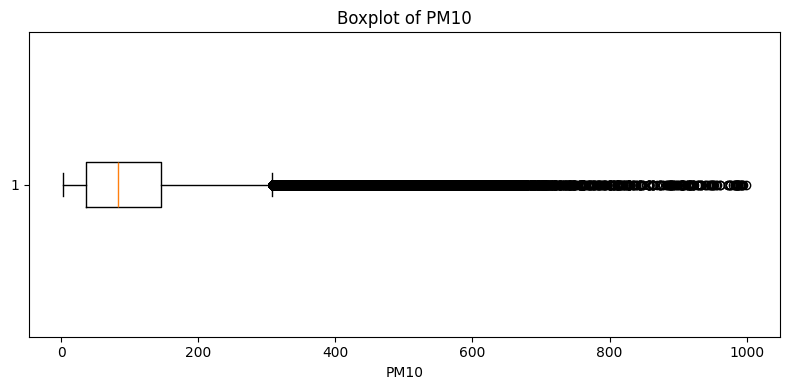

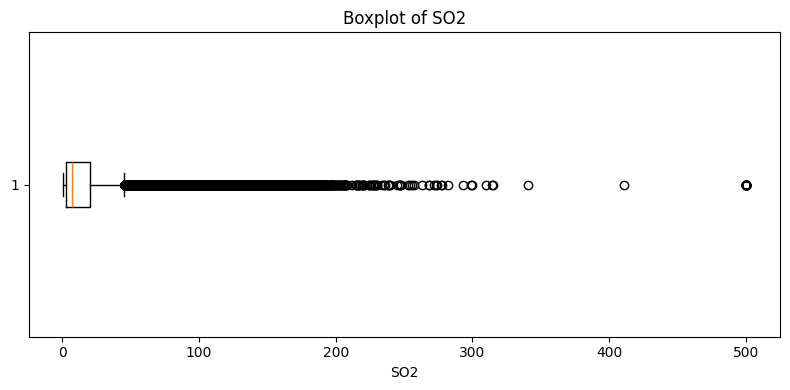

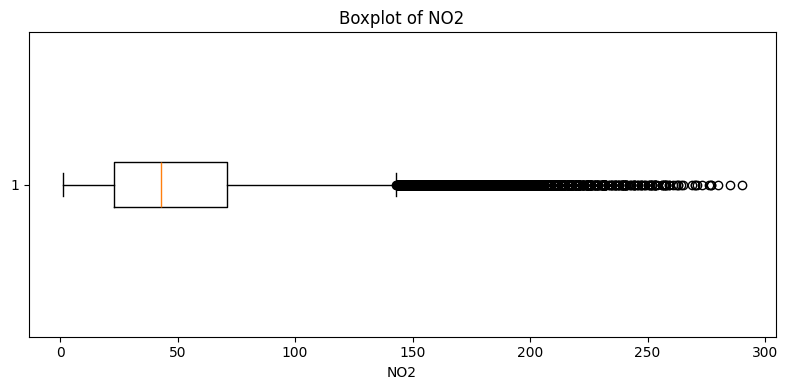

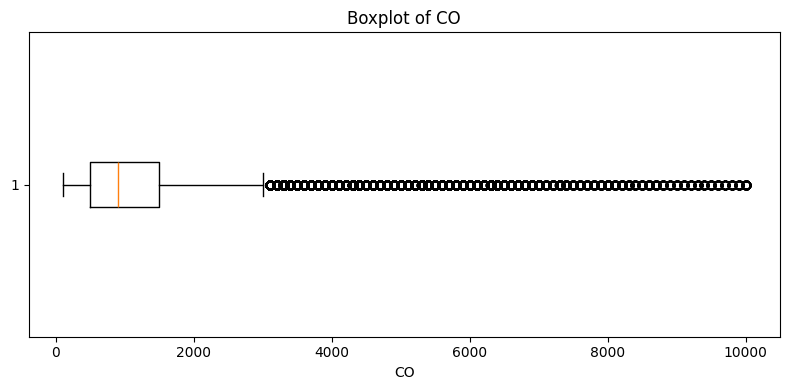

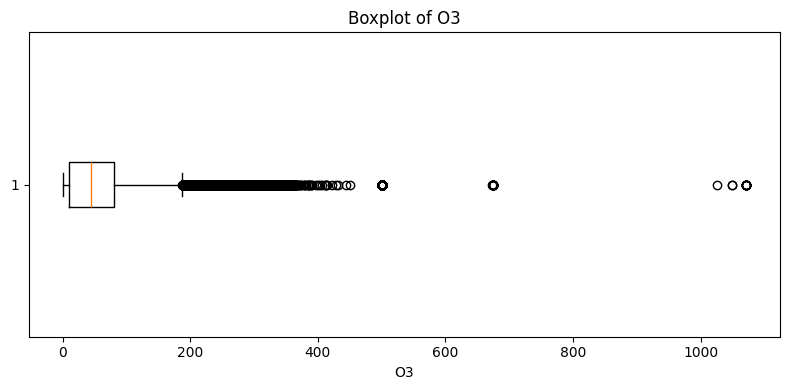

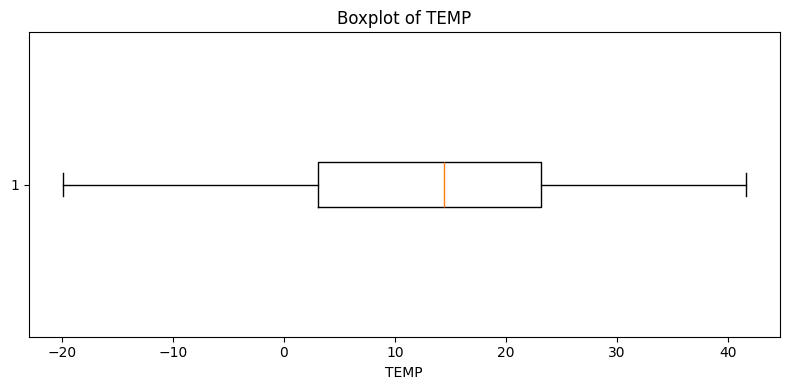

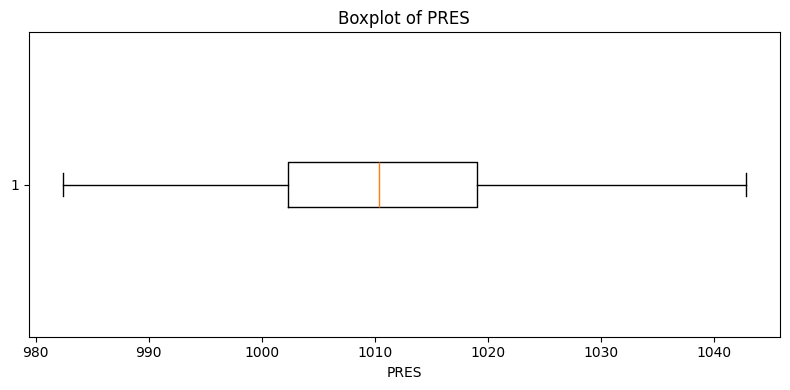

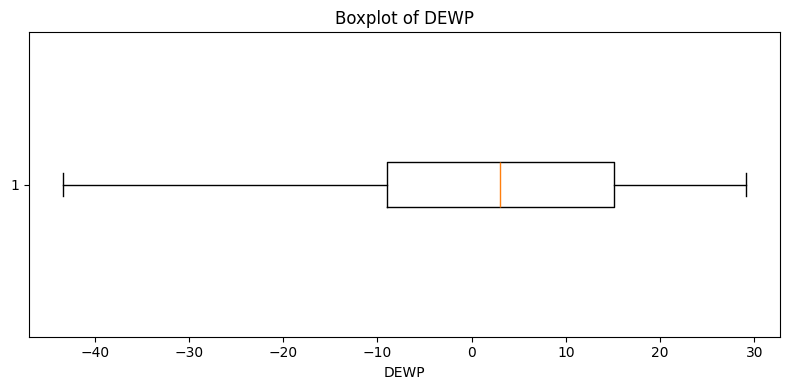

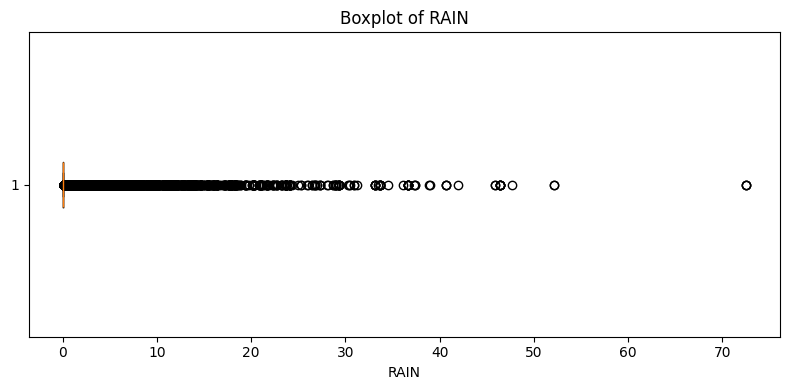

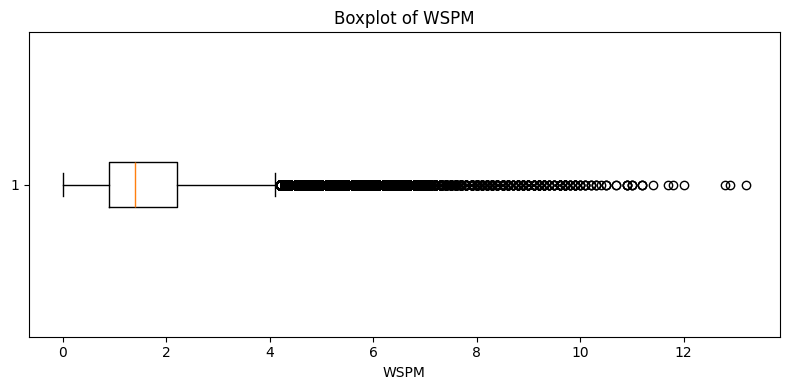

In [25]:
# ==========================================
# Boxplots for Potential Outlier Detection
# ==========================================

import matplotlib.pyplot as plt

# Create an individual boxplot for each numerical variable
for col in numerical_cols:                                 # Loop through each numeric column

    plt.figure(figsize=(8, 4))                             # Set figure size for clarity

    # Create horizontal boxplot
    plt.boxplot(                                           # Boxplot shows quartiles + outliers
        df[col].dropna(),                                  # Drop NaNs before plotting
        vert=False                                         # Horizontal orientation
    )

    # Add title and axis label
    plt.title(f"Boxplot of {col}")                         # Title with variable name
    plt.xlabel(col)                                        # Label x-axis with variable name

    # Improve layout
    plt.tight_layout()                                     # Adjust spacing for readability

    # Display plot
    plt.show()                                             # Render the plot


### **Interpretation**

#### **Boxplot Analysis**

* The boxplots show that **PM10, SO₂, NO₂, CO, O₃, RAIN, and WSPM** contain numerous observations beyond their upper whiskers, confirming the presence of potential extreme values identified through the IQR-based outlier analysis.

* **PM10** and **NO₂** show substantial numbers of high-end observations beyond their upper whiskers, indicating right-skewed distributions with occasional elevated concentrations.

* **SO₂** and **CO** exhibit particularly pronounced right-skewed distributions, with many observations extending well beyond the upper whisker.

* **O₃** also shows a right-skewed distribution with several high-concentration observations, including a small number of very high values.

* **RAIN** is highly concentrated near zero, while a smaller number of observations extend to substantially higher rainfall amounts. This pattern is consistent with the highly positively skewed rainfall distribution identified earlier.

* **WSPM** shows a concentration of observations at lower wind speeds with a long upper tail, indicating occasional periods of higher wind speed.

* In contrast, **TEMP, PRES, and DEWP** show relatively compact distributions without visible individual points beyond the whiskers, consistent with the IQR-based assessment that identified no potential outliers for these variables.

#### **Overall Observation**

* The boxplots confirm that several environmental variables have **right-skewed distributions and potential extreme observations**.
* These observations were **retained rather than automatically removed**, as extreme pollutant concentrations, rainfall events, and wind speeds may represent genuine environmental conditions relevant to one-hour-ahead PM2.5 forecasting.
* The boxplots therefore support the decision to retain the observations while allowing the machine learning models to account for the observed variability.


### **4.10 Final Preprocessed Dataset Verification**

In [26]:
# ==========================================
# Final Preprocessed Dataset Verification
# ==========================================

# Display the dimensions of the preprocessed dataset
print("Dataset Shape:", df.shape)                          # Show total rows × columns

# Check for any remaining missing values
print("\nMissing Values After Preprocessing:")
remaining_missing = df.isnull().sum()                      # Count NaNs per column
display(remaining_missing.to_frame(name="Missing Values")) # Display as DataFrame for clarity

# Display the total number of remaining missing values
print("Total Remaining Missing Values:", remaining_missing.sum())  # Sum across all columns

# Display the first five rows of the preprocessed dataset
print("\nFirst Five Rows of the Preprocessed Dataset:")
display(df.head())                                         # Preview first 5 rows


Dataset Shape: (412007, 22)

Missing Values After Preprocessing:


,Missing Values
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


Total Remaining Missing Values: 2873

First Five Rows of the Preprocessed Dataset:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,next_datetime,PM2.5_next_hour,time_gap
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00,2013-03-01 01:00:00,8.0,0 days 01:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00,2013-03-01 02:00:00,7.0,0 days 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00,2013-03-01 03:00:00,6.0,0 days 01:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00,2013-03-01 04:00:00,3.0,0 days 01:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00,2013-03-01 05:00:00,5.0,0 days 01:00:00


### **Interpretation**

#### **Preprocessed Dataset**

* Following missing-value treatment and datetime feature creation, the preprocessed dataset contains **412,007 observations and 22 variables**.

* The original pollutant, meteorological, temporal, categorical, and `datetime` variables contain **zero missing values** after preprocessing.

* The forecasting-related variables **`next_datetime`**, **`PM2.5_next_hour`**, and **`time_gap`** contain **2,873 missing values in total**. These missing values arise because a subsequent observation is not available for some records, so a valid one-hour-ahead forecasting target cannot be constructed for those observations.

* The first five observations confirm that the **`datetime`** variable correctly represents the hourly timestamps and that the corresponding `next_datetime`, `PM2.5_next_hour`, and `time_gap` values are correctly aligned.

#### **Overall Observation**

* The preprocessing stage successfully completed the missing-value treatment for the original predictor variables while preserving the temporal structure required for forecasting.

* The remaining missing values are confined to the **forecasting-related variables** and will be addressed when constructing the final one-hour-ahead forecasting dataset by retaining observations with a valid target and an exact one-hour time gap.

* The resulting dataset is therefore ready for **exploratory data analysis and preparation of the final forecasting dataset**.


## **Save Final Preprocessed Dataset**


In [27]:
# ==========================================
# Save Final Preprocessed Dataset
# ==========================================

# Save the preprocessed dataset as a CSV file
df.to_csv(                                                  # Export DataFrame to CSV
    "air_quality_processed.csv",                            # File name
    index=False                                             # Exclude row indices from file
)

# Confirmation message
print("Preprocessed dataset saved successfully as 'air_quality_processed.csv'.")


Preprocessed dataset saved successfully as 'air_quality_processed.csv'.


### **Note:  Preprocessed Dataset Export**

The final preprocessed dataset was successfully saved as **`air_quality_processed.csv`** for use in subsequent exploratory analysis and machine learning model development.

# **5. Exploratory Data Analysis (EDA)**

* Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify trends, detect anomalies, and examine relationships between air pollutants and meteorological factors. These insights support feature selection and model development.

## **5.1: Distribution of PM2.5 Concentration**

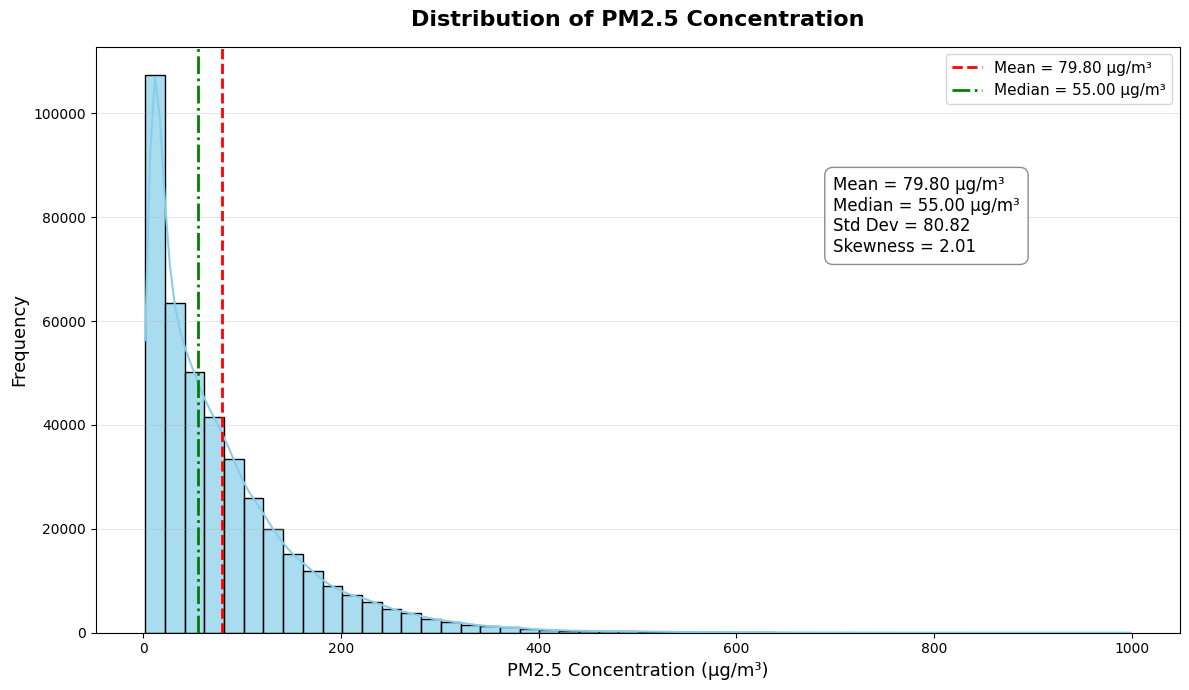

In [28]:
# ==========================================
# Distribution of PM2.5 Concentration
# ==========================================

import matplotlib.pyplot as plt                             # For plotting
import seaborn as sns                                       # For advanced plots (histogram + KDE)
from scipy.stats import skew                                # For skewness calculation

# Extract PM2.5 values
pm25 = df['PM2.5'].dropna()                                # Take PM2.5 column, drop missing values

# Calculate distribution statistics
mean_val = pm25.mean()                                     # Arithmetic mean (average)
median_val = pm25.median()                                 # Median (middle value)
skewness_val = skew(pm25)                                  # Skewness (symmetry/asymmetry measure)
std_val = pm25.std()                                       # Standard deviation (spread of values)

# Create histogram with density curve
plt.figure(figsize=(12, 7))                                # Set figure size (width=12, height=7)

sns.histplot(                                              # Histogram with density curve
    pm25,                                                  # Data: PM2.5 values
    bins=50,                                               # Number of bins
    kde=True,                                              # Add kernel density estimate curve
    color='skyblue',                                       # Bar color
    edgecolor='black',                                     # Bar edge color
    alpha=0.7                                              # Transparency
)

# Add reference line for mean
plt.axvline(
    mean_val,                                              # Position at mean
    color='red',                                           # Line color
    linestyle='--',                                        # Dashed line
    linewidth=2,                                           # Line thickness
    label=f'Mean = {mean_val:.2f} µg/m³'                   # Legend label with formatted mean
)

# Add reference line for median
plt.axvline(
    median_val,                                            # Position at median
    color='green',                                         # Line color
    linestyle='-.',                                        # Dash-dot line
    linewidth=2,                                           # Line thickness
    label=f'Median = {median_val:.2f} µg/m³'               # Legend label with formatted median
)

# Add title and axis labels
plt.title(
    'Distribution of PM2.5 Concentration',                 # Chart title
    fontsize=16,                                           # Title font size
    fontweight='bold',                                     # Bold title
    pad=15                                                 # Padding above title
)

plt.xlabel(
    'PM2.5 Concentration (µg/m³)',                         # X-axis label
    fontsize=13                                            # Font size
)

plt.ylabel(
    'Frequency',                                           # Y-axis label
    fontsize=13                                            # Font size
)

# Create statistical summary box
stats_text = (                                             # Text block with stats
    f'Mean = {mean_val:.2f} µg/m³\n'
    f'Median = {median_val:.2f} µg/m³\n'
    f'Std Dev = {std_val:.2f}\n'
    f'Skewness = {skewness_val:.2f}'
)

# Display statistics clearly inside the plot
plt.text(
    0.68,                                                  # X-position (relative to axes)
    0.78,                                                  # Y-position (relative to axes)
    stats_text,                                            # Text content
    transform=plt.gca().transAxes,                         # Use axis coordinates
    fontsize=12,                                           # Font size
    verticalalignment='top',                               # Align text at top
    bbox=dict(                                             # Box styling
        boxstyle='round,pad=0.5',                          # Rounded box with padding
        facecolor='white',                                 # White background
        edgecolor='gray',                                  # Gray border
        alpha=0.9                                          # Slight transparency
    )
)

# Improve readability
plt.grid(                                                  # Add gridlines
    axis='y',                                              # Only horizontal lines
    alpha=0.3                                              # Transparency
)

plt.legend(fontsize=11)                                    # Show legend for mean/median lines

plt.tight_layout()                                         # Optimize spacing

# Display plot
plt.show()                                                 # Render the plot


### **Interpretation**

#### **Analysis of PM2.5 Distribution**

* PM2.5 concentrations are concentrated at lower values, while relatively fewer observations occur at very high concentration levels, resulting in a pronounced **right-skewed distribution**.

* The calculated **skewness (2.01)** confirms substantial positive skewness, with high PM2.5 observations contributing to the extended upper tail of the distribution.

* The **mean PM2.5 concentration (79.80 µg/m³)** is considerably higher than the **median (55.00 µg/m³)**, further reflecting the influence of high-concentration observations on the overall average.

* The **standard deviation (80.82 µg/m³)** indicates considerable variability in PM2.5 concentrations across the dataset.

* Such variability is characteristic of air-quality data, where pollutant concentrations may fluctuate across different temporal, meteorological, and environmental conditions.

#### **Overall Observation**

* The analysis demonstrates that PM2.5 concentrations exhibit substantial variability and a strongly positively skewed distribution, with relatively few high-concentration observations forming a long upper tail.

* These high-concentration observations were retained because they may represent meaningful pollution episodes and are relevant to evaluating model performance across the full range of PM2.5 conditions.


### **5.1.1 Descriptive Statistics of PM2.5**

In [29]:
# ==========================================
# Descriptive Statistics of PM2.5
# ==========================================

pm25_summary = pd.DataFrame({
    'Statistic': [
        'Count',                        # Number of observations
        'Mean',                         # Average PM2.5 concentration
        'Median',                       # Middle value
        'Standard Deviation',           # Spread of values
        'Minimum',                      # Lowest observed value
        '25th Percentile (Q1)',         # Lower quartile
        '75th Percentile (Q3)',         # Upper quartile
        'Maximum',                      # Highest observed value
        'Skewness',                     # Asymmetry of distribution
        'Kurtosis'                      # Tail heaviness of distribution
    ],
    'Value': [
        round(pm25.count(), 0),         # Count of values
        round(pm25.mean(), 2),          # Mean
        round(pm25.median(), 2),        # Median
        round(pm25.std(), 2),           # Standard deviation
        round(pm25.min(), 2),           # Minimum
        round(pm25.quantile(0.25), 2),  # Q1
        round(pm25.quantile(0.75), 2),  # Q3
        round(pm25.max(), 2),           # Maximum
        round(pm25.skew(), 2),          # Skewness
        round(pm25.kurt(), 2)           # Kurtosis
    ]
})

# Display PM2.5 descriptive statistics
display(pm25_summary)

,Statistic,Value
0,Count,412007.00
1,Mean,79.80
2,Median,55.00
3,Standard Deviation,80.82
4,Minimum,2.00
5,25th Percentile (Q1),20.00
6,75th Percentile (Q3),111.00
7,Maximum,999.00
8,Skewness,2.01
9,Kurtosis,5.96


### **Interpretation**

#### **Summary Statistics of PM2.5**

* The PM2.5 variable contains **412,007 observations**, with concentrations ranging from **2.00 µg/m³ to 999.00 µg/m³**.

* The mean PM2.5 concentration is **79.80 µg/m³**, while the median is **55.00 µg/m³**. The higher mean relative to the median indicates that high-concentration observations influence the overall average.

* The middle 50% of PM2.5 observations lie between **20.00 µg/m³ (Q1)** and **111.00 µg/m³ (Q3)**, demonstrating substantial variation in pollutant concentrations across the dataset.

* The standard deviation of **80.82 µg/m³** further indicates considerable variability in PM2.5 concentrations.

* The positive **skewness of 2.01** confirms a strongly right-skewed distribution, with relatively fewer observations extending toward very high PM2.5 concentrations.

* The **kurtosis value of 5.96** indicates relatively heavy tails, consistent with the presence of extreme high-concentration observations.

#### **Overall Observation**

* The summary statistics confirm substantial variability and positive skewness in PM2.5 concentrations, consistent with the histogram and boxplot findings.

* The high-concentration observations were retained because they may represent meaningful pollution episodes and are relevant to the study's **one-hour-ahead PM2.5 forecasting objective**.


## **5.2 Correlation Analysis**

### **5.2.1 Correlation Matrix**

In [30]:
# ==========================================
# Correlation Matrix
# ==========================================

# Define numerical variables for correlation analysis
numerical_cols = [                                          # List of numeric columns
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Calculate Pearson correlation coefficients
correlation_matrix = df[numerical_cols].corr()              # Default method = Pearson correlation

# Display correlation matrix rounded to two decimal places
display(correlation_matrix.round(2))                        # Show clean table with 2-decimal precision


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.00,0.88,0.47,0.66,0.78,-0.15,-0.13,0.02,0.11,-0.01,-0.27
PM10,0.88,1.00,0.45,0.64,0.69,-0.11,-0.10,-0.02,0.07,-0.03,-0.18
SO2,0.47,0.45,1.00,0.48,0.51,-0.16,-0.32,0.22,-0.26,-0.04,-0.11
NO2,0.66,0.64,0.48,1.00,0.68,-0.46,-0.27,0.17,-0.03,-0.04,-0.39
CO,0.78,0.69,0.51,0.68,1.00,-0.30,-0.33,0.19,-0.07,-0.01,-0.29
O3,-0.15,-0.11,-0.16,-0.46,-0.30,1.00,0.58,-0.44,0.31,0.02,0.29
TEMP,-0.13,-0.10,-0.32,-0.27,-0.33,0.58,1.00,-0.81,0.82,0.04,0.03
PRES,0.02,-0.02,0.22,0.17,0.19,-0.44,-0.81,1.00,-0.75,-0.06,0.07
DEWP,0.11,0.07,-0.26,-0.03,-0.07,0.31,0.82,-0.75,1.00,0.09,-0.30
RAIN,-0.01,-0.03,-0.04,-0.04,-0.01,0.02,0.04,-0.06,0.09,1.00,0.02


### **Interpretation**

#### **Correlation of Predictor Variables with PM2.5**

* **PM10** shows the strongest positive correlation with PM2.5 (**r = 0.88**), indicating that higher PM10 concentrations tend to occur alongside higher PM2.5 concentrations.

* **CO** also exhibits a strong positive correlation with PM2.5 (**r = 0.78**), while **NO₂** shows a moderately strong positive correlation (**r = 0.66**).

* **SO₂** has a moderate positive correlation with PM2.5 (**r = 0.47**).

* Among the meteorological variables, **wind speed (WSPM)** has the strongest relationship with PM2.5 and shows a negative correlation (**r = −0.27**). This indicates that higher wind speeds tend to be associated with lower PM2.5 concentrations.

* **O₃ (r = −0.15)** and **TEMP (r = −0.13)** show weak negative correlations with PM2.5, while **DEWP (r = 0.11)** shows a weak positive correlation.

* **PRES (r = 0.02)** and **RAIN (r = −0.01)** show very weak linear relationships with PM2.5.

#### **Relationships Among Predictor Variables**

* Strong correlations are also observed among some predictor variables. **TEMP and DEWP** are strongly positively correlated (**r = 0.82**), while **TEMP and PRES** show a strong negative correlation (**r = −0.81**).

* **PRES and DEWP** also exhibit a strong negative correlation (**r = −0.75**), indicating substantial relationships among the meteorological variables.

#### **Overall Observation**

* The correlation analysis indicates that PM2.5 is most strongly associated with other pollutant variables, particularly **PM10, CO, and NO₂**, while meteorological variables generally show weaker direct linear relationships with PM2.5.

* These correlations describe statistical associations and should **not be interpreted as evidence of causation**.

* The presence of correlations among predictor variables will be considered during model development and interpretation.


### **5.2.2 Correlation Heatmap**

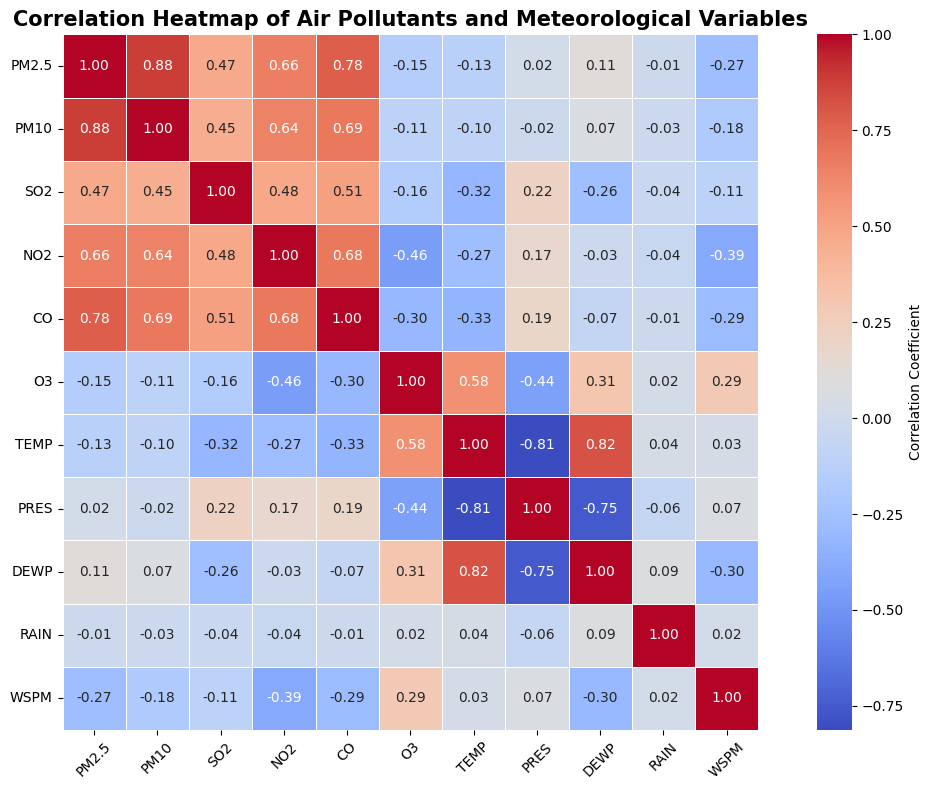

In [31]:
# ==========================================
# 5.2.2 Correlation Heatmap
# ==========================================

plt.figure(figsize=(12, 8))                  # Set figure size

sns.heatmap(                                 # Create heatmap
    correlation_matrix,                      # Use correlation matrix
    annot=True,                              # Show correlation values
    cmap='coolwarm',                         # Color scheme (blue-red)
    fmt='.2f',                               # Format numbers to 2 decimals
    linewidths=0.5,                          # Thin lines between cells
    square=True,                             # Keep cells square-shaped
    cbar_kws={'label': 'Correlation Coefficient'}  # Label for color bar
)

plt.title(                                   # Add title
    'Correlation Heatmap of Air Pollutants and Meteorological Variables',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=45)                      # Rotate x-axis labels for readability
plt.yticks(rotation=0)                       # Keep y-axis labels horizontal

plt.tight_layout()                           # Adjust layout to fit labels
plt.show()                                   # Display the heatmap


### **Interpretation**

* The heatmap provides a visual representation of the relationships among air pollutants and meteorological variables, where warmer colours indicate positive correlations and cooler colours indicate negative correlations.

* **PM2.5** exhibits a strong positive correlation with **PM10 (r = 0.88)** and **CO (r = 0.78)**, indicating that higher concentrations of these pollutants tend to occur alongside higher PM2.5 concentrations.

* A moderately strong positive correlation is observed between **PM2.5 and NO₂ (r = 0.66)**, while **SO₂ (r = 0.47)** shows a moderate positive relationship with PM2.5.

* Meteorological variables display comparatively weaker direct linear relationships with PM2.5. **WSPM (r = −0.27)** and **TEMP (r = −0.13)** show negative correlations, while **PRES (r = 0.02)** shows very little linear relationship with PM2.5.

* Strong relationships are also evident among some meteorological variables, particularly between **TEMP and DEWP (r = 0.82)**, **TEMP and PRES (r = −0.81)**, and **PRES and DEWP (r = −0.75)**.

### **Overall Observation**

* The heatmap indicates that **PM2.5 exhibits stronger correlations with other air pollutants than with the individual meteorological variables**.

* The observed correlations represent statistical associations and **should not be interpreted as evidence of causal relationships**.


## **5.3 Monthly Variation of PM2.5**

,month,PM2.5
0,1,93.667037
1,2,87.572234
2,3,94.715242
3,4,72.734890
4,5,63.105338
5,6,69.091971
6,7,71.744853
7,8,53.473014
8,9,61.478105
9,10,91.726800


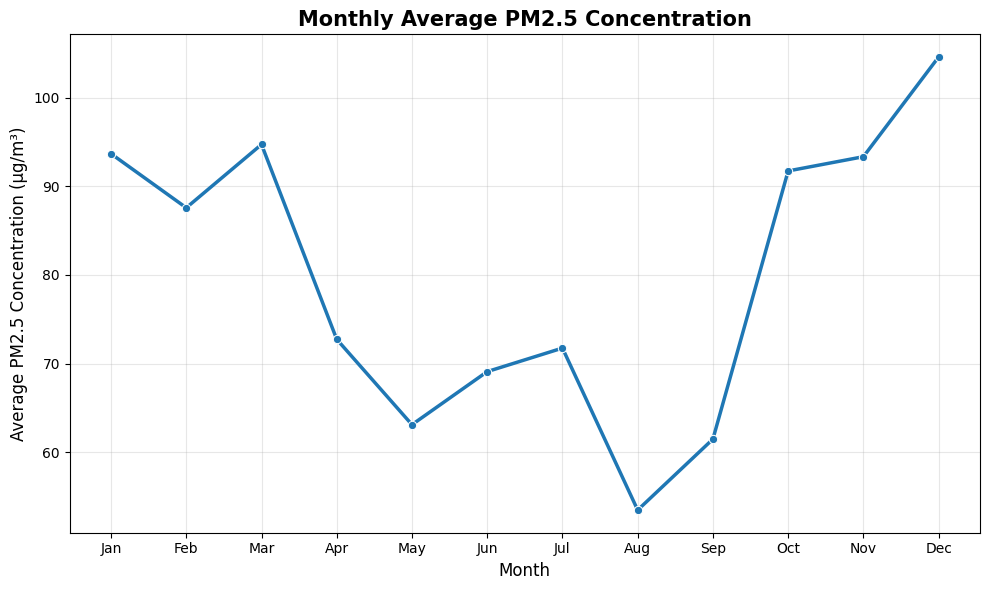

In [32]:
# ==========================================
# Monthly Average PM2.5 Analysis
# ==========================================

# Calculate average PM2.5 concentration for each calendar month
monthly_pm25 = (                                            # Group by month
    df.groupby('month')['PM2.5']                            # Select PM2.5 column
      .mean()                                               # Compute mean per month
      .reset_index()                                        # Reset index for clean DataFrame
)

# Display monthly average PM2.5 concentrations
display(monthly_pm25)                                       # Show table of monthly averages

# Create line plot
plt.figure(figsize=(10, 6))                                 # Set figure size

sns.lineplot(                                               # Line plot of monthly averages
    data=monthly_pm25,
    x='month',
    y='PM2.5',
    marker='o',                                             # Add markers at each point
    linewidth=2.5                                           # Thicker line for clarity
)

# Add chart title and axis labels
plt.title(
    'Monthly Average PM2.5 Concentration',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=12)                            # Label x-axis
plt.ylabel('Average PM2.5 Concentration (µg/m³)', fontsize=12) # Label y-axis

# Display month names on x-axis
plt.xticks(                                                 # Replace numbers with month names
    ticks=range(1, 13),
    labels=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
    ]
)

# Improve readability
plt.grid(alpha=0.3)                                         # Light gridlines
plt.tight_layout()                                          # Optimize spacing

# Display plot
plt.show()


### **Interpretation of the PM2.5 Graph**

1. **Highest concentration:** December has the highest PM2.5 concentration at **104.58 µg/m³**.

2. **Lowest concentration:** August has the lowest concentration at **53.47 µg/m³**.

3. **Overall trend:** PM2.5 levels are relatively high at the beginning of the year, decrease gradually toward August, and then **increase sharply from September onward**.

4. **January-March:** The concentration fluctuates slightly, ranging from about **87.57 to 94.72 µg/m³**.

5. **April-August:** There is a general decline, reaching the yearly minimum in August. There is a small increase in **June and July**.

6. **September-December:** PM2.5 rises significantly, increasing from **61.48 µg/m³ in September** to **104.58 µg/m³ in December**.

7. **Key observation:** The data shows a clear **seasonal pattern**, with PM2.5 concentrations generally lower during the middle of the year and substantially higher toward the end of the year.

**In simple words:**
*Air pollution is highest around the beginning and especially the end of the year, while the cleanest period is around August.*


## **5.4 Station-wise PM2.5 Analysis**

### **5.4.1 Average PM2.5 by Station**

In [33]:
# ==========================================
# Average PM2.5 Concentration by Station
# ==========================================

station_pm25 = (                              # Create new DataFrame
    df.groupby('station')['PM2.5']            # Group data by station
      .mean()                                 # Calculate mean PM2.5 for each station
      .sort_values(ascending=False)           # Sort stations by average PM2.5 (highest first)
      .reset_index()                          # Reset index so 'station' becomes a column
)

# Display station-wise average PM2.5 concentrations
display(station_pm25)


,station,PM2.5
0,Dongsi,86.194297
1,Wanshouxigong,85.024136
2,Nongzhanguan,84.838483
3,Gucheng,83.896570
4,Wanliu,83.374716
5,Guanyuan,82.933372
6,Aotizhongxin,82.773611
7,Tiantan,82.164911
8,Shunyi,79.491602
9,Changping,71.099743


### **Interpretation**

* Average PM2.5 concentrations vary across the **12 monitoring stations**, indicating spatial variation in air pollution levels within the dataset.

* **Dongsi** records the highest average PM2.5 concentration at approximately **86.19 µg/m³**, followed by **Wanshouxigong (85.02 µg/m³)** and **Nongzhanguan (84.84 µg/m³)**.

* In contrast, **Dingling** records the lowest average PM2.5 concentration at approximately **65.99 µg/m³**, followed by **Huairou (69.63 µg/m³)** and **Changping (71.10 µg/m³)**.

* The difference between the highest and lowest station averages is approximately **20.20 µg/m³**, showing a noticeable variation in PM2.5 concentrations across monitoring locations.

### **Overall Observation**

* The station-level analysis indicates that PM2.5 concentrations are **not uniform across monitoring locations**.

* Some stations consistently show higher average concentrations, while others have comparatively lower levels.

* This spatial variation suggests that the **station variable may provide useful predictive information** when modelling one-hour-ahead PM2.5 concentrations.



### **5.4.2 Bar Chart**

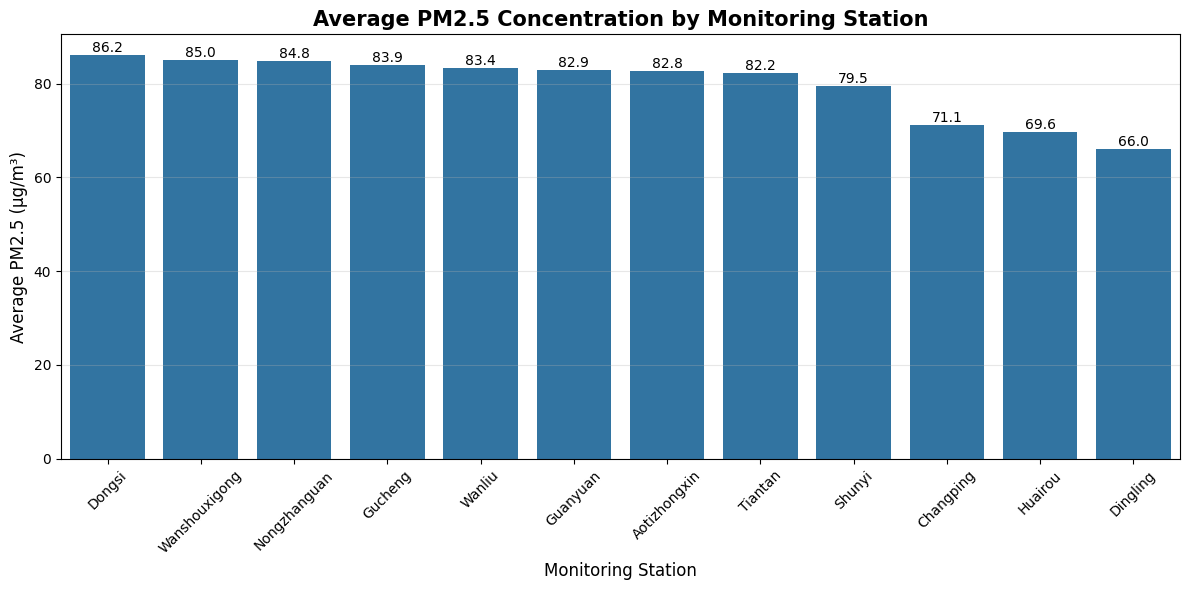

In [34]:
# ==========================================
# Bar Chart of Average PM2.5 by Station
# ==========================================

plt.figure(figsize=(12,6))                     # Set figure size

ax = sns.barplot(                              # Create bar chart
    data=station_pm25,                         # Use station-level averages
    x='station',                               # Stations on x-axis
    y='PM2.5'                                  # Average PM2.5 on y-axis
)

# Add value labels on top of bars
for container in ax.containers:                # Loop through bar containers
    ax.bar_label(container, fmt='%.1f', fontsize=10)  # Show values with 1 decimal

plt.title(                                     # Add chart title
    'Average PM2.5 Concentration by Monitoring Station',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Monitoring Station', fontsize=12)  # Label x-axis
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12) # Label y-axis

plt.xticks(rotation=45)                        # Rotate station names for readability

plt.grid(axis='y', alpha=0.3)                  # Add horizontal gridlines

plt.tight_layout()                             # Adjust layout to fit labels

plt.show()                                     # Display the plot


### **Interpretation**

* The chart shows that the **average PM2.5 concentration varies across the 12 monitoring stations**, indicating differences in air pollution levels by location.

* **Dongsi** has the highest average PM2.5 concentration at approximately **86.2 µg/m³**, followed by **Wanshouxigong (85.0 µg/m³)** and **Nongzhanguan (84.8 µg/m³)**.

* **Dingling** has the lowest average concentration at approximately **66.0 µg/m³**, followed by **Huairou (69.6 µg/m³)** and **Changping (71.1 µg/m³)**.

* The difference between the highest and lowest stations is about **20.2 µg/m³**, showing a noticeable spatial variation in PM2.5 levels.

* The first several stations—**Dongsi, Wanshouxigong, Nongzhanguan, Gucheng, Wanliu, Guanyuan, Aotizhongxin, and Tiantan**—have relatively similar averages, all between approximately **82 and 86 µg/m³**.

* The lower concentrations at **Shunyi, Changping, Huairou, and Dingling** create a clear downward pattern toward the right side of the chart.

### **Overall Observation**

**PM2.5 concentration is not uniform across monitoring stations.** Some locations experience considerably higher average pollution levels than others, suggesting that **monitoring station/location could be an important variable when predicting PM2.5 concentrations**.

**One-line conclusion:**

> *The chart indicates clear spatial variation in PM2.5 levels, with Dongsi recording the highest average concentration and Dingling the lowest.*


### **5.4.3 Highest and Lowest Pollution Stations**

In [35]:
# ==========================================
# Highest and Lowest Average PM2.5 Stations
# ==========================================

# Identify the station with the highest average PM2.5 concentration
highest_station = station_pm25.iloc[0]                     # First row (sorted descending)

# Identify the station with the lowest average PM2.5 concentration
lowest_station = station_pm25.iloc[-1]                     # Last row (lowest average)

# Display highest average PM2.5 station
print("Highest Average PM2.5 Station:")
print(
    f"{highest_station['station']} : "                     # Station name
    f"{highest_station['PM2.5']:.2f} µg/m³"                # Value formatted to 2 decimals
)

# Display lowest average PM2.5 station
print("\nLowest Average PM2.5 Station:")
print(
    f"{lowest_station['station']} : "                      # Station name
    f"{lowest_station['PM2.5']:.2f} µg/m³"                 # Value formatted to 2 decimals
)


Highest Average PM2.5 Station:
Dongsi : 86.19 µg/m³

Lowest Average PM2.5 Station:
Dingling : 65.99 µg/m³


### **Key Observation:**
Dongsi records the highest average PM2.5 concentration (86.19 µg/m³), while Dingling records the lowest (65.99 µg/m³). This indicates a spatial variation of approximately 20.20 µg/m³ in average PM2.5 levels across the monitoring stations.


## **5.5 Relationship Between Meteorological Variables and PM2.5**

### **5.5.1 Scatter Plots**

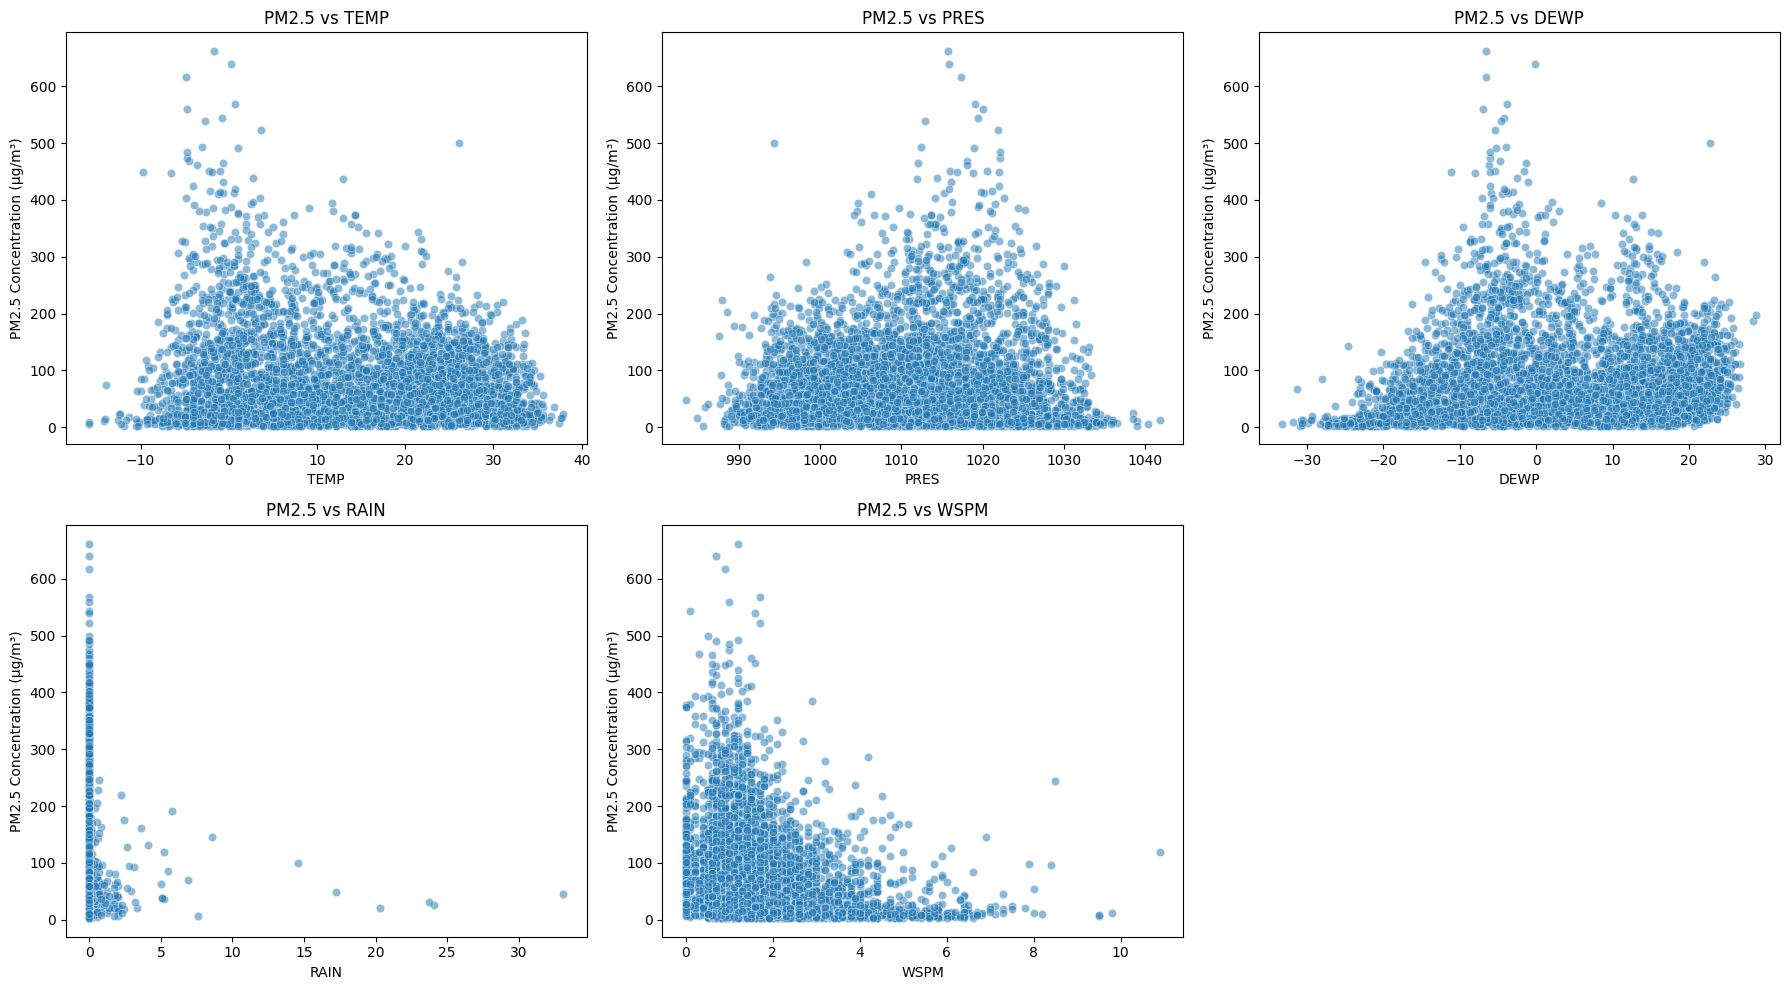

In [36]:
# ==========================================
# Relationship Between Meteorological Variables and PM2.5
# ==========================================

# Define meteorological variables
meteorological_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']   # Weather variables to compare

# Create one reproducible sample for visualization
sample_df = df.sample(                                          # Random sample for faster plotting
    n=5000,                                                     # Use 5,000 rows
    random_state=42                                             # Fixed seed for reproducibility
)

# Create figure
plt.figure(figsize=(18, 10))                                    # Large figure for multiple subplots

# Generate scatterplots for each meteorological variable
for i, var in enumerate(meteorological_vars, 1):                # Loop through variables with index

    plt.subplot(2, 3, i)                                        # Create subplot grid (2 rows × 3 cols)

    sns.scatterplot(                                            # Scatter plot for each variable
        data=sample_df,
        x=var,                                                  # Meteorological variable on x-axis
        y='PM2.5',                                              # PM2.5 concentration on y-axis
        alpha=0.5                                               # Semi-transparent points
    )

    # Add subplot title and axis labels
    plt.title(f'PM2.5 vs {var}')                                # Title for each subplot
    plt.xlabel(var)                                             # Label x-axis
    plt.ylabel('PM2.5 Concentration (µg/m³)')                   # Label y-axis

# Adjust layout and display
plt.tight_layout()                                              # Prevent overlap
plt.show()                                                      # Display all subplots


### **Interpretation of the Scatter Plots**

* **PM2.5 vs TEMP:** PM2.5 shows a **weak to moderate negative relationship** with temperature. Higher PM2.5 values are more concentrated at lower temperatures, while PM2.5 levels generally decrease as temperature increases.

* **PM2.5 vs PRES:** There appears to be a **weak relationship** between pressure and PM2.5. Higher PM2.5 concentrations are mostly observed around the middle range of atmospheric pressure, but the relationship is not clearly linear.

* **PM2.5 vs DEWP:** PM2.5 shows a **non-linear relationship** with dew point. Higher PM2.5 concentrations are more frequently observed at lower-to-moderate dew point values, with considerable variation.

* **PM2.5 vs RAIN:** There is a **negative relationship** between rainfall and PM2.5. Most high PM2.5 values occur when rainfall is close to zero, while higher rainfall generally corresponds to lower PM2.5 concentrations.

* **PM2.5 vs WSPM:** PM2.5 generally shows a **negative relationship with wind speed**. High PM2.5 concentrations are concentrated at low wind speeds, whereas higher wind speeds are associated with relatively lower PM2.5 levels.

### **Overall Observation**

> **Among the variables shown, rainfall and wind speed exhibit the clearest negative relationships with PM2.5. Temperature also shows a tendency for PM2.5 to be higher at lower temperatures, while pressure and dew point show weaker and less clearly defined relationships.**



### **5.5.2 Correlation of Meteorological Variables with PM2.5**

* This analysis describes the contemporaneous relationships between meteorological variables and current-hour PM2.5 concentrations in the original dataset. Forecasting-specific relationships with the one-hour-ahead PM2.5 target are examined separately before model development.

In [37]:
# ==========================================
# Correlation of Meteorological Variables with PM2.5
# ==========================================

pm25_corr = (                                # Create correlation series
    df[meteorological_vars + ['PM2.5']]      # Select meteorological variables + PM2.5
      .corr()['PM2.5']                       # Compute correlation matrix, extract PM2.5 column
      .drop('PM2.5')                         # Drop self-correlation (always 1.0)
      .sort_values(ascending=False)          # Sort correlations from strongest positive to weakest
)

# Display correlations rounded to three decimal places
display(
    pm25_corr.round(3).to_frame(
        name='Correlation with PM2.5'
    )
)


,Correlation with PM2.5
DEWP,0.115
PRES,0.018
RAIN,-0.014
TEMP,-0.131
WSPM,-0.272


### **5.5.2 Correlation of Meteorological Variables with PM2.5**

* **WSPM** shows the strongest correlation with PM2.5 (**r = -0.272**), indicating a weak-to-moderate negative relationship. Higher wind speeds tend to be associated with lower PM2.5 concentrations.

* **TEMP** shows a weak negative correlation (**r = -0.131**), suggesting that PM2.5 tends to decrease slightly as temperature increases.

* **DEWP** shows a weak positive correlation (**r = 0.115**), indicating a slight tendency for PM2.5 to increase with dew point.

* **PRES** shows a negligible positive correlation (**r = 0.018**), indicating almost no linear relationship with PM2.5.

* **RAIN** shows a negligible negative correlation (**r = -0.014**), indicating virtually no linear relationship with PM2.5.

**Overall Observation:** WSPM has the strongest linear relationship with current-hour PM2.5, followed by TEMP. DEWP shows a weak positive relationship, while PRES and RAIN exhibit negligible linear correlations.


## **5.6 Transition to One-Hour-Ahead Forecasting**

* The exploratory data analysis above examined the patterns and relationships present in the original air quality dataset. Based on mentor feedback, the predictive task was subsequently defined as a **one-hour-ahead PM2.5 forecasting problem**.

* Accordingly, the modelling stage uses information available at the current hour **(t)** to forecast the PM2.5 concentration one hour ahead **(t+1)**. The forecasting target and modelling framework are defined in the following section.


# **6. Model Development**

## **6.1 Forecasting Horizon**

* Based on mentor feedback, the prediction task was defined as a **one-hour-ahead forecasting problem**. The objective is to use environmental, meteorological, temporal, and location-related information available at the current hour **(t)** to predict PM2.5 concentration one hour ahead **(t+1)**.

* A **one-hour forecasting horizon** was selected because the dataset contains hourly observations, providing a practical short-term air quality forecasting framework.


In [38]:
# ============================================================
# Prepare One-Hour-Ahead PM2.5 Forecasting Dataset
# ============================================================

# The forecasting target PM2.5_next_hour was created before
# missing-value imputation and is therefore based only on
# the originally observed PM2.5 values.

# Retain only observations where:
# 1. The next observation is exactly one hour later
# 2. The next-hour PM2.5 target is actually observed

df_forecast = df[
    (df['time_gap'] == pd.Timedelta(hours=1)) &
    (df['PM2.5_next_hour'].notna())
].copy()

print("Preprocessed dataset shape:", df.shape)
print("Forecasting dataset shape:", df_forecast.shape)

# Display a preview of the forecasting dataset
display(
    df_forecast[
        [
            'station',
            'datetime',
            'PM2.5',
            'next_datetime',
            'PM2.5_next_hour'
        ]
    ].head(10)
)

Preprocessed dataset shape: (412007, 22)
Forecasting dataset shape: (409158, 22)


,station,datetime,PM2.5,next_datetime,PM2.5_next_hour
0,Aotizhongxin,2013-03-01 00:00:00,4.0,2013-03-01 01:00:00,8.0
1,Aotizhongxin,2013-03-01 01:00:00,8.0,2013-03-01 02:00:00,7.0
2,Aotizhongxin,2013-03-01 02:00:00,7.0,2013-03-01 03:00:00,6.0
3,Aotizhongxin,2013-03-01 03:00:00,6.0,2013-03-01 04:00:00,3.0
4,Aotizhongxin,2013-03-01 04:00:00,3.0,2013-03-01 05:00:00,5.0
5,Aotizhongxin,2013-03-01 05:00:00,5.0,2013-03-01 06:00:00,3.0
6,Aotizhongxin,2013-03-01 06:00:00,3.0,2013-03-01 07:00:00,3.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,2013-03-01 08:00:00,3.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,2013-03-01 09:00:00,3.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,2013-03-01 10:00:00,3.0


### **6.2 Target Variable Construction**

* The preprocessed dataset contains **412,007 observations and 22 variables**.

* To formulate the one-hour-ahead forecasting problem, the PM2.5 value at the **next hour (t+1)** was created as the target variable using the current-hour observation **(t)**.

* The corresponding **next-hour timestamp** was also created to verify that the target represents exactly one hour after the current observation.

* For example, for **Aotizhongxin at 00:00**, the current PM2.5 value is **4.0 µg/m³**, while the PM2.5 value at **01:00** is **8.0 µg/m³**. Thus, **8.0 µg/m³ becomes the forecasting target** for the 00:00 observation.

* After constructing the one-hour-ahead target and retaining observations with a valid next-hour value, the forecasting dataset contains **409,158 observations and 22 variables**.

* This target construction ensures that the modelling task is explicitly defined as predicting **PM2.5(t+1) using information available at time t**.


### **6.1.1 Forecasting-Specific Exploratory Analysis**

* Following the creation of the **PM2.5_next_hour** target variable, an additional exploratory analysis was conducted to examine the relationships between information available at the current hour **(t)** and PM2.5 concentration one hour ahead **(t+1)**.

* This forecasting-specific analysis complements the earlier EDA, which examined relationships with **current-hour PM2.5 concentrations**, and ensures that the analysis is aligned with the defined forecasting objective.


#### **Correlation with One-Hour-Ahead PM2.5**

In [39]:
# ============================================================
# Correlation with One-Hour-Ahead PM2.5
# ============================================================

forecast_numeric_vars = [                                   # Variables to include in correlation
    'PM2.5',
    'PM10',
    'SO2',
    'NO2',
    'CO',
    'O3',
    'TEMP',
    'PRES',
    'DEWP',
    'RAIN',
    'WSPM',
    'PM2.5_next_hour'                                       # Forecast target
]

# Calculate correlations with the forecasting target
forecast_corr = (                                           # Compute correlation series
    df_forecast[forecast_numeric_vars]                      # Select relevant variables
    .corr()['PM2.5_next_hour']                              # Extract correlations with target
    .drop('PM2.5_next_hour')                                # Drop trivial self-correlation
    .sort_values(ascending=False)                           # Sort descending (strongest positive first)
)

print("CORRELATION WITH ONE-HOUR-AHEAD PM2.5")
print("=" * 50)

display(forecast_corr)                                      # Show ranked correlations


CORRELATION WITH ONE-HOUR-AHEAD PM2.5


,PM2.5_next_hour
PM2.5,0.969012
PM10,0.863553
CO,0.761605
NO2,0.658167
SO2,0.465318
DEWP,0.115133
PRES,0.020448
RAIN,-0.029271
TEMP,-0.131479
O3,-0.151486


### **Interpretation**

* **PM2.5** has the strongest positive correlation with one-hour-ahead PM2.5 (**r = 0.969**), indicating a very strong relationship between current-hour and next-hour PM2.5 concentrations.

* **PM10** also shows a strong positive correlation (**r = 0.864**), followed by **CO (r = 0.762)** and **NO2 (r = 0.658)**. These variables therefore show substantial linear relationships with the forecasting target.

* **SO2** has a moderate positive correlation (**r = 0.465**), indicating a weaker but noticeable relationship with one-hour-ahead PM2.5.

* **DEWP** shows a weak positive correlation (**r = 0.115**), while **PRES (r = 0.020)** and **RAIN (r = -0.029)** show negligible linear relationships with the target.

* **TEMP** (**r = -0.131**), **O3** (**r = -0.151**), and **WSPM** (**r = -0.289**) show weak negative correlations. Among these, **WSPM has the strongest negative relationship**, suggesting that higher wind speeds tend to be associated with lower PM2.5 concentrations one hour ahead.

### **Overall Observation**

* The analysis shows that **current-hour PM2.5 is the strongest linear predictor of one-hour-ahead PM2.5**, followed by PM10, CO, and NO2.
* The results support the inclusion of **lagged/current-hour pollutant and meteorological variables** in the forecasting models.
* However, correlation measures only **linear association** and do not by themselves establish causation or determine the final importance of variables in the predictive models.


#### **Correlation Plot of Current-Hour Predictors with One-Hour-Ahead PM2.5**

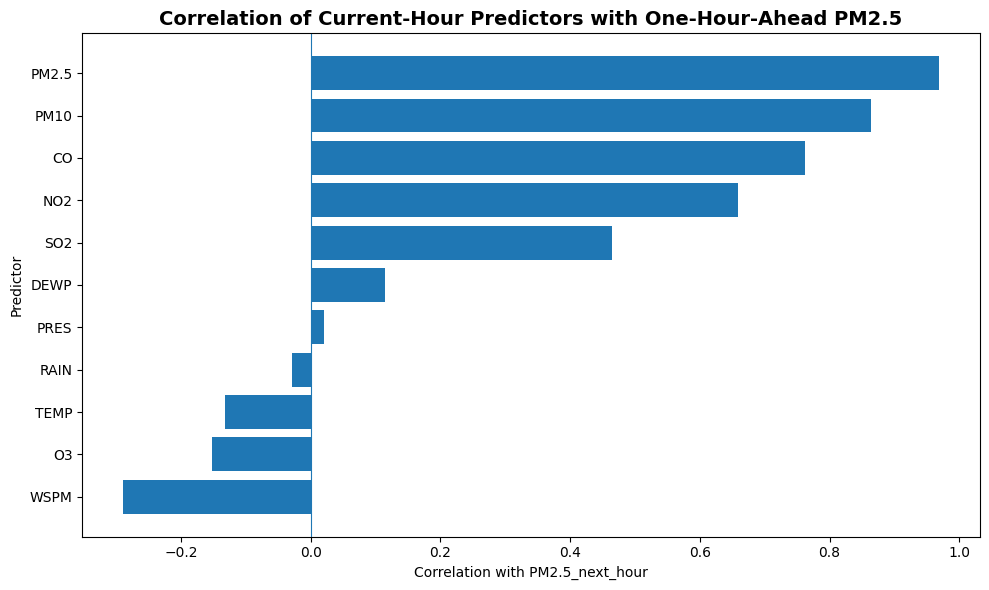

In [40]:
# ============================================================
# Correlation Plot
# ============================================================

import matplotlib.pyplot as plt

# Sort correlations so lowest appears at the bottom
plot_corr = forecast_corr.sort_values()

plt.figure(figsize=(10, 6))                                # Set figure size

plt.barh(                                                  # Horizontal bar chart
    plot_corr.index,                                       # Predictor names on y-axis
    plot_corr.values                                       # Correlation values on x-axis
)

# Add chart title and axis labels
plt.title(
    'Correlation of Current-Hour Predictors with One-Hour-Ahead PM2.5',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Correlation with PM2.5_next_hour')             # Label x-axis
plt.ylabel('Predictor')                                    # Label y-axis

plt.axvline(0, linewidth=0.8)                              # Reference line at zero correlation

plt.tight_layout()                                         # Optimize spacing
plt.show()                                                 # Display plot


### **Interpretation**

* **PM2.5** has the strongest positive correlation with one-hour-ahead PM2.5 (**r = 0.969**), indicating a very strong relationship between current and next-hour PM2.5 concentrations.

* **PM10 (r = 0.864)**, **CO (r = 0.762)**, and **NO2 (r = 0.658)** also show strong positive correlations with the forecasting target.

* **SO2 (r = 0.465)** shows a moderate positive correlation, while **DEWP (r = 0.115)** and **PRES (r = 0.020)** show very weak positive relationships.

* **RAIN (r = -0.029)** has an almost negligible negative correlation with one-hour-ahead PM2.5.

* **TEMP (r = -0.131)**, **O3 (r = -0.151)**, and **WSPM (r = -0.289)** show negative correlations. **WSPM** has the strongest negative correlation among the meteorological variables.

### **Overall Observation**

* The correlation analysis indicates that **current-hour PM2.5 is the strongest linear predictor of PM2.5 one hour ahead**, followed by PM10, CO, and NO2.
* The results indicate that both **pollutant and meteorological variables contain potentially useful information for one-hour-ahead forecasting**.
* These correlations describe **linear associations** and therefore should not be interpreted as causal relationships or as definitive measures of model feature importance.


#### **Correlation Between Current-Hour and One-Hour-Ahead PM2.5**

In [41]:
# ============================================================
# Current PM2.5 vs One-Hour-Ahead PM2.5
# ============================================================

# Calculate correlation between current-hour PM2.5 and next-hour PM2.5
current_next_corr = df_forecast[
    ['PM2.5', 'PM2.5_next_hour']                            # Select relevant columns
].corr().iloc[0, 1]                                         # Extract correlation coefficient

# Display result with formatting
print(
    f"Correlation between current-hour PM2.5 "
    f"and one-hour-ahead PM2.5: {current_next_corr:.4f}"    # Format to 4 decimal places
)


Correlation between current-hour PM2.5 and one-hour-ahead PM2.5: 0.9690


### **Interpretation**

* **Correlation between current-hour PM2.5 and one-hour-ahead PM2.5: 0.9690**, indicating a **very strong positive linear relationship**.

* This suggests that PM2.5 concentration at the current hour is highly associated with the PM2.5 concentration one hour later.

* Therefore, **current-hour PM2.5 is an important predictor for one-hour-ahead PM2.5 forecasting**.


## **6.2 Feature Selection**

* For the **one-hour-ahead PM2.5 forecasting task**, **PM2.5_next_hour** was defined as the target variable. The predictor variables consisted of environmental, meteorological, temporal, and location-related information available at the current hour **(t)**.

* Current-hour **PM2.5** was retained as a predictor because it is available at the time the forecast is made and provides relevant information for predicting PM2.5 concentration one hour ahead **(t+1)**.

* The record identifier (**No**) and the constructed **datetime** variable were excluded from the predictor set.

In [42]:
# ============================================================
# Feature Selection for One-Hour-Ahead PM2.5 Forecasting
# ============================================================

# Target variable: PM2.5 concentration one hour ahead
y = df_forecast['PM2.5_next_hour'].copy()                   # Define target (dependent variable)

# Predictor variables: information available at the current hour
# Exclude target, record identifier, and helper time-verification variables
X = df_forecast.drop(                                       # Define predictors (independent variables)
    columns=[
        'PM2.5_next_hour',                                  # Target variable
        'datetime',                                         # Current timestamp
        'next_datetime',                                    # Next timestamp
        'time_gap',                                         # Helper column for time difference
        'No'                                                # Record identifier
    ]
).copy()

# Display dimensions of predictors and target
print("Predictor Variables Shape:", X.shape)                # Show dimensions of X (rows × features)
print("Target Variable Shape:", y.shape)                    # Show dimensions of y (rows,)

# Preview predictors and target
display(X.head())                                           # Preview first 5 rows of predictors
display(y.head())                                           # Preview first 5 values of target


Predictor Variables Shape: (409158, 17)
Target Variable Shape: (409158,)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


,PM2.5_next_hour
0,8.0
1,7.0
2,6.0
3,3.0
4,5.0


### **Interpretation**

* The forecasting dataset contains **409,158 observations** with **17 predictor variables**.
* The predictors include **pollutant variables (PM2.5, PM10, SO2, NO2, CO, O3)**, **meteorological variables (TEMP, PRES, DEWP, RAIN, wd, WSPM)**, **temporal variables (year, month, day, hour)**, and the **station** variable.
* **PM2.5_next_hour** is the target variable, containing **409,158 corresponding one-hour-ahead PM2.5 values**.
* The first few records demonstrate the forecasting structure: information available at hour **t** is used to predict the PM2.5 concentration at hour **t+1**.
* The **No** identifier and constructed **datetime** variable are not included among the predictors, consistent with the feature-selection approach.


## **6.3 Encode Categorical Variables**

In [43]:
# ============================================================
# One-Hot Encoding of Categorical Variables
# ============================================================

X = pd.get_dummies(                          # Apply one-hot encoding
    X,                                       # DataFrame of predictors
    columns=['station', 'wd'],               # Encode categorical columns: station, wind direction
    drop_first=True                          # Drop first category to avoid dummy variable trap
)

print("Shape after encoding:", X.shape)      # Show new shape after encoding (rows × features)

display(X.head())                            # Preview first 5 rows of encoded predictors


Shape after encoding: (409158, 41)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,station_Changping,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong,wd_ENE,wd_ESE,wd_N,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


### **Interpretation**

* After encoding the categorical variables, the dataset contains **409,158 observations and 41 features**.

* The categorical variables **station** and **wind direction (wd)** were converted into numerical **binary indicator variables** using one-hot encoding.

* The **station** variable was expanded into separate station-specific columns, allowing the models to capture differences in PM2.5 levels across monitoring locations.

* The **wd** variable was similarly converted into separate binary columns for the different wind directions.

* The original numerical environmental and meteorological variables, including **PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, and WSPM**, were retained as numerical predictors.

* The resulting encoded dataset is therefore suitable for use with machine-learning models that require numerical input features.


## **6.4 Chronological Train-Test Split**

* A chronological time-based train-test split was used, with the cutoff determined at approximately 80% of the observations. All observations before the cutoff timestamp were used for training, while observations from the cutoff timestamp onward were reserved for testing. Complete timestamps were kept together to avoid splitting observations from the same time point across the training and testing sets.


In [44]:
# ============================================================
# Time-Based Train-Test Split
# ============================================================

# Create chronological order using the original datetime information
time_order = df_forecast.sort_values(                 # Sort rows chronologically
    by=['datetime', 'station']                        # Order by datetime first, then station
).index                                               # Get sorted index

# Reorder predictors, target, and datetime consistently
X_time = X.loc[time_order].reset_index(drop=True)     # Apply sorted order to predictors
y_time = y.loc[time_order].reset_index(drop=True)     # Apply sorted order to target
datetime_time = (                                     # Extract datetime column in same order
    df_forecast.loc[time_order, 'datetime']
    .reset_index(drop=True)
)

# Find approximate 80% split point
approx_split = int(len(X_time) * 0.80)                # Calculate index for 80% cutoff

# Use the timestamp at the approximate 80% point as the cutoff
cutoff_time = datetime_time.iloc[approx_split]        # Get datetime at cutoff index

# Keep complete timestamps together
train_mask = datetime_time < cutoff_time              # Training mask → rows before cutoff
test_mask = datetime_time >= cutoff_time              # Testing mask → rows at/after cutoff

X_train = X_time.loc[train_mask].reset_index(drop=True)  # Training predictors
y_train = y_time.loc[train_mask].reset_index(drop=True)  # Training target

X_test = X_time.loc[test_mask].reset_index(drop=True)    # Testing predictors
y_test = y_time.loc[test_mask].reset_index(drop=True)    # Testing target

print("Training set shape:", X_train.shape)           # Print training set shape
print("Testing set shape:", X_test.shape)             # Print testing set shape

print("\nTraining period:")                           # Print training period range
print(datetime_time.loc[train_mask].min(), "to",      # First training timestamp
      datetime_time.loc[train_mask].max())            # Last training timestamp

print("\nTesting period:")                            # Print testing period range
print(datetime_time.loc[test_mask].min(), "to",       # First testing timestamp
      datetime_time.loc[test_mask].max())             # Last testing timestamp

print("\nForecasting horizon: 1 hour ahead")          # State forecasting horizon
print("Cutoff time:", cutoff_time)                    # Print cutoff timestamp


Training set shape: (327325, 41)
Testing set shape: (81833, 41)

Training period:
2013-03-01 00:00:00 to 2016-05-12 17:00:00

Testing period:
2016-05-12 18:00:00 to 2017-02-28 22:00:00

Forecasting horizon: 1 hour ahead
Cutoff time: 2016-05-12 18:00:00


### **Interpretation**


* The chronological split resulted in **327,325 observations for training** and **81,833 observations for testing**, corresponding to approximately an **80:20 split**.

* The **training period** extends from **1 March 2013, 00:00** to **12 May 2016, 17:00**.

* The **testing period** begins at **12 May 2016, 18:00** and extends to **28 February 2017, 22:00**.

* The cutoff timestamp was **12 May 2016, 18:00**. Observations before this timestamp were assigned to the training set, while observations from this timestamp onward were assigned to the test set.

* This chronological approach ensures that the models are trained on **earlier observations and evaluated on subsequent observations**, which is appropriate for a one-hour-ahead forecasting task and helps avoid temporal data leakage.


### **6.4.1 Evaluation Metrics**

* **Mean Absolute Error (MAE)** measures the average absolute difference between the predicted and actual PM2.5 concentrations. It represents the average forecasting error in **µg/m³**, making it directly interpretable for air-quality monitoring.

* **Root Mean Squared Error (RMSE)** gives greater weight to larger forecasting errors because the errors are squared before averaging. This is particularly relevant for air-quality forecasting, where larger errors during elevated pollution episodes may have greater operational significance for monitoring and early-warning applications.

* **Coefficient of Determination (R²)** measures the proportion of variation in the one-hour-ahead PM2.5 concentrations explained by the model. Higher R² values generally indicate stronger predictive performance. However, R² is interpreted together with MAE and RMSE when comparing models.

* Model performance was therefore evaluated using **MAE, RMSE, and R²** to provide a balanced assessment of **typical forecasting error, sensitivity to larger errors, and overall explanatory performance**.


## **6.5 Model Building**

### **6.5.1 Linear Regression**

* **Linear Regression** was selected as the **baseline model** for one-hour-ahead PM2.5 forecasting. It provides a simple and interpretable benchmark against which the performance of more advanced machine learning models can be compared.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Model performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** on both the training and testing datasets.


In [45]:
from sklearn.linear_model import LinearRegression            # Import Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np                                           # NumPy for math functions

# Initialize and train Linear Regression
lr_model = LinearRegression()                                # Create Linear Regression instance
lr_model.fit(X_train, y_train)                               # Fit model on training data

# Predictions on training and testing data
y_train_pred_lr = lr_model.predict(X_train)                  # Predict on training set
y_test_pred_lr = lr_model.predict(X_test)                    # Predict on testing set

# Training metrics
lr_train_mae = mean_absolute_error(y_train, y_train_pred_lr) # Mean Absolute Error (train)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr)) # RMSE (train)
lr_train_r2 = r2_score(y_train, y_train_pred_lr)             # R² score (train)

# Testing metrics
lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)    # Mean Absolute Error (test)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))    # RMSE (test)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)                # R² score (test)

# Display results
print("LINEAR REGRESSION PERFORMANCE")                       # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {lr_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {lr_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {lr_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {lr_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {lr_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {lr_test_r2:.4f}")                            # Print R² (4 decimals)


LINEAR REGRESSION PERFORMANCE

Training Performance
MAE  : 10.76
RMSE : 19.63
R²   : 0.9399

Testing Performance
MAE  : 10.17
RMSE : 19.08
R²   : 0.9478


### **Interpretation**
### **Linear Regression Performance**

* The Linear Regression model achieved an **MAE of 10.76 µg/m³**, **RMSE of 19.63 µg/m³**, and **R² of 0.9399** on the training set.

* On the unseen testing set, the model achieved an **MAE of 10.17 µg/m³**, **RMSE of 19.08 µg/m³**, and **R² of 0.9478**.

* The testing performance is slightly better than the training performance across all three metrics, indicating that the model **generalised well to the unseen testing period** and did not show evidence of substantial overfitting.

* The testing **R² of 0.9478** indicates that approximately **94.78% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the Linear Regression model on the testing data.

* Overall, Linear Regression provides a **strong baseline model** for the one-hour-ahead PM2.5 forecasting task.



### **6.5.2 Decision Tree Regressor**

* **Decision Tree Regressor** was developed to capture **non-linear relationships** between the predictor variables and one-hour-ahead PM2.5 concentrations. Unlike Linear Regression, a Decision Tree can learn complex patterns and interactions between variables without assuming a linear relationship.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.


In [46]:
from sklearn.tree import DecisionTreeRegressor              # Import Decision Tree Regressor

# Initialize and train Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)           # Create Decision Tree instance (fixed seed)
dt_model.fit(X_train, y_train)                              # Fit model on training data

# Predictions on training and testing data
y_train_pred_dt = dt_model.predict(X_train)                 # Predict on training set
y_test_pred_dt = dt_model.predict(X_test)                   # Predict on testing set

# Training metrics
dt_train_mae = mean_absolute_error(y_train, y_train_pred_dt) # Mean Absolute Error (train)
dt_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_dt)) # RMSE (train)
dt_train_r2 = r2_score(y_train, y_train_pred_dt)             # R² score (train)

# Testing metrics
dt_test_mae = mean_absolute_error(y_test, y_test_pred_dt)    # Mean Absolute Error (test)
dt_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))    # RMSE (test)
dt_test_r2 = r2_score(y_test, y_test_pred_dt)                # R² score (test)

# Display results
print("DECISION TREE PERFORMANCE")                           # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {dt_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {dt_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {dt_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {dt_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {dt_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {dt_test_r2:.4f}")                            # Print R² (4 decimals)


DECISION TREE PERFORMANCE

Training Performance
MAE  : 0.00
RMSE : 0.00
R²   : 1.0000

Testing Performance
MAE  : 16.13
RMSE : 29.14
R²   : 0.8783


### **Interpretation**

### **Decision Tree Performance**

* The Decision Tree Regressor achieved **MAE of 0.00 µg/m³**, **RMSE of 0.00 µg/m³**, and **R² of 1.0000** on the training set, indicating a perfect fit to the training observations.

* On the unseen testing set, performance decreased to **MAE of 16.13 µg/m³**, **RMSE of 29.14 µg/m³**, and **R² of 0.8783**.

* The substantial difference between training and testing performance indicates that the Decision Tree **overfit the training data** and did not generalise as well to the unseen testing period.

* The testing **R² of 0.8783** indicates that approximately **87.83% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the model on the testing data.

* Compared with the Linear Regression baseline, the Decision Tree produced **higher MAE and RMSE and a lower R² on the testing set**, indicating weaker predictive performance in its current configuration.


### **6.5.3 Random Forest Regressor**

* **Random Forest Regressor** was developed as an **ensemble learning model** that combines multiple decision trees to improve predictive performance and reduce the overfitting associated with a single Decision Tree.

*  Each tree is trained using random samples of the training observations and predictor variables, and the final regression prediction is obtained by **averaging the predictions across the individual trees**.

* The model was trained using **earlier chronological training observations** to forecast PM2.5 concentration one hour ahead and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.


In [47]:
from sklearn.ensemble import RandomForestRegressor          # Import Random Forest Regressor

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(                           # Create Random Forest instance
    n_estimators=100,                                       # Number of trees in the forest
    random_state=42,                                        # Fixed seed for reproducibility
    n_jobs=-1                                               # Use all CPU cores for faster training
)

# Train the model
rf_model.fit(X_train, y_train)                              # Fit model on training data

# Predictions on training and testing data
y_train_pred_rf = rf_model.predict(X_train)                 # Predict on training set
y_test_pred_rf = rf_model.predict(X_test)                   # Predict on testing set

# Training metrics
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf) # Mean Absolute Error (train)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf)) # RMSE (train)
rf_train_r2 = r2_score(y_train, y_train_pred_rf)             # R² score (train)

# Testing metrics
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)    # Mean Absolute Error (test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))    # RMSE (test)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)                # R² score (test)

# Display results
print("RANDOM FOREST PERFORMANCE")                           # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {rf_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {rf_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {rf_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {rf_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {rf_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {rf_test_r2:.4f}")                            # Print R² (4 decimals)


RANDOM FOREST PERFORMANCE

Training Performance
MAE  : 3.69
RMSE : 6.83
R²   : 0.9927

Testing Performance
MAE  : 10.16
RMSE : 19.02
R²   : 0.9482


### **Interpretation**

### **Random Forest Performance**

* The Random Forest Regressor achieved **MAE of 3.69 µg/m³**, **RMSE of 6.83 µg/m³**, and **R² of 0.9927** on the training set.

* On the unseen testing set, the model achieved **MAE of 10.16 µg/m³**, **RMSE of 19.02 µg/m³**, and **R² of 0.9482**.

* The difference between training and testing performance indicates some degree of **overfitting**, but the model maintained strong predictive performance on the unseen testing period.

* The testing **R² of 0.9482** indicates that approximately **94.82% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the Random Forest model.

* Compared with the Linear Regression baseline, Random Forest achieved **slightly lower MAE and RMSE and a slightly higher R² on the testing set**, indicating a **small improvement in predictive performance**.


### **6.5.4 XGBoost Regression**

* **XGBoost (Extreme Gradient Boosting)** was developed as an advanced ensemble learning model for one-hour-ahead PM2.5 forecasting.

* Unlike Random Forest, which builds multiple decision trees independently, XGBoost builds trees **sequentially**, with each new tree focusing on the prediction errors of the preceding ensemble. This enables the model to capture **complex non-linear relationships** between the predictor variables and future PM2.5 concentrations.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.


In [48]:
from xgboost import XGBRegressor                           # Import XGBoost Regressor

# Initialize XGBoost Regressor
xgb_model = XGBRegressor(                                  # Create XGBoost instance
    n_estimators=100,                                      # Number of boosting rounds (trees)
    learning_rate=0.1,                                     # Step size shrinkage
    max_depth=6,                                           # Maximum depth of each tree
    random_state=42,                                       # Fixed seed for reproducibility
    tree_method='hist',                                    # Fast histogram-based algorithm
    device='cuda'                                          # Use GPU acceleration (CUDA)
)

# Train the model
xgb_model.fit(X_train, y_train)                            # Fit model on training data

# Predictions on training and testing data
y_train_pred_xgb = xgb_model.predict(X_train)              # Predict on training set
y_test_pred_xgb = xgb_model.predict(X_test)                # Predict on testing set

# Training metrics
xgb_train_mae = mean_absolute_error(y_train, y_train_pred_xgb) # Mean Absolute Error (train)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)) # RMSE (train)
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)         # R² score (train)

# Testing metrics
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)    # Mean Absolute Error (test)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))    # RMSE (test)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)                # R² score (test)

# Display results
print("XGBOOST REGRESSOR PERFORMANCE")                    # Section header
print("=" * 45)

print("\nTraining Performance")                           # Training results header
print(f"MAE  : {xgb_train_mae:.2f}")                      # Print MAE (2 decimals)
print(f"RMSE : {xgb_train_rmse:.2f}")                     # Print RMSE (2 decimals)
print(f"R²   : {xgb_train_r2:.4f}")                       # Print R² (4 decimals)

print("\nTesting Performance")                            # Testing results header
print(f"MAE  : {xgb_test_mae:.2f}")                       # Print MAE (2 decimals)
print(f"RMSE : {xgb_test_rmse:.2f}")                      # Print RMSE (2 decimals)
print(f"R²   : {xgb_test_r2:.4f}")                        # Print R² (4 decimals)


XGBOOST REGRESSOR PERFORMANCE

Training Performance
MAE  : 9.70
RMSE : 17.11
R²   : 0.9543

Testing Performance
MAE  : 9.77
RMSE : 18.57
R²   : 0.9506


### **Interpretation**

### **XGBoost Regressor Performance**

* The XGBoost Regressor achieved **MAE of 9.70 µg/m³**, **RMSE of 17.11 µg/m³**, and **R² of 0.9543** on the training set.

* On the unseen testing set, the model achieved **MAE of 9.77 µg/m³**, **RMSE of 18.57 µg/m³**, and **R² of 0.9506**.

* The training and testing performance are relatively close, indicating **good generalisation to the unseen testing period** and limited evidence of overfitting.

* The testing **R² of 0.9506** indicates that approximately **95.06% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the XGBoost model.

* Among the models evaluated so far, XGBoost achieved the **highest testing R² and lowest testing RMSE**, while also providing a lower testing MAE than Linear Regression and Decision Tree.


### **6.5.5 Gradient Boosting Regressor**

* **Gradient Boosting Regressor** was implemented as an ensemble learning algorithm that sequentially builds decision trees, with each new tree learning to correct the prediction errors made by the preceding ensemble.

* By combining multiple weak learners, the model can capture **complex non-linear relationships** between the predictor variables and one-hour-ahead PM2.5 concentrations.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.


In [49]:
from sklearn.ensemble import GradientBoostingRegressor       # Import Gradient Boosting Regressor

# Initialize Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(                        # Create Gradient Boosting instance
    n_estimators=100,                                        # Number of boosting stages (trees)
    random_state=42                                          # Fixed seed for reproducibility
)

# Train the model
gb_model.fit(X_train, y_train)                               # Fit model on training data

# Predictions on training and testing data
y_train_pred_gb = gb_model.predict(X_train)                  # Predict on training set
y_test_pred_gb = gb_model.predict(X_test)                    # Predict on testing set

# Training metrics
gb_train_mae = mean_absolute_error(y_train, y_train_pred_gb) # Mean Absolute Error (train)
gb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_gb)) # RMSE (train)
gb_train_r2 = r2_score(y_train, y_train_pred_gb)             # R² score (train)

# Testing metrics
gb_test_mae = mean_absolute_error(y_test, y_test_pred_gb)    # Mean Absolute Error (test)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))    # RMSE (test)
gb_test_r2 = r2_score(y_test, y_test_pred_gb)                # R² score (test)

# Display results
print("GRADIENT BOOSTING PERFORMANCE")                       # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {gb_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {gb_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {gb_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {gb_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {gb_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {gb_test_r2:.4f}")                            # Print R² (4 decimals)


GRADIENT BOOSTING PERFORMANCE

Training Performance
MAE  : 10.25
RMSE : 18.66
R²   : 0.9457

Testing Performance
MAE  : 9.78
RMSE : 18.64
R²   : 0.9502


### **Interpretation**

### **Gradient Boosting Performance**

* The Gradient Boosting Regressor achieved a **training MAE of 10.25 µg/m³** and a **testing MAE of 9.78 µg/m³**, indicating a relatively small difference between training and testing error.

* The **testing RMSE of 18.64 µg/m³** is slightly lower than the training RMSE of 18.66 µg/m³, indicating that the model maintained consistent performance on unseen data.

* The model achieved an **R² of 0.9457 on the training set** and **0.9502 on the testing set**, indicating that approximately **95% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the model on the testing data.

* The similar training and testing performance suggests **no strong evidence of overfitting** for the Gradient Boosting model.

* Overall, the Gradient Boosting Regressor demonstrated **strong and consistent predictive performance** for one-hour-ahead PM2.5 forecasting.


### **6.5.6 AdaBoost Regressor**

* **AdaBoost Regressor (Adaptive Boosting)** was implemented as an ensemble learning model for one-hour-ahead PM2.5 forecasting.

* AdaBoost builds a sequence of weak learners, with each successive model placing greater emphasis on observations that were predicted less accurately by the preceding models. This iterative approach allows the model to progressively improve its predictions.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.


In [50]:

from sklearn.ensemble import AdaBoostRegressor              # Import AdaBoost Regressor

# Initialize AdaBoost Regressor
ada_model = AdaBoostRegressor(                              # Create AdaBoost instance
    n_estimators=100,                                       # Number of boosting stages (weak learners)
    learning_rate=0.1,                                      # Weight applied to each learner
    random_state=42                                         # Fixed seed for reproducibility
)

# Train the model
ada_model.fit(X_train, y_train)                             # Fit model on training data

# Predictions on training and testing data
y_train_pred_ada = ada_model.predict(X_train)               # Predict on training set
y_test_pred_ada = ada_model.predict(X_test)                 # Predict on testing set

# Training metrics
ada_train_mae = mean_absolute_error(y_train, y_train_pred_ada) # Mean Absolute Error (train)
ada_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ada)) # RMSE (train)
ada_train_r2 = r2_score(y_train, y_train_pred_ada)          # R² score (train)

# Testing metrics
ada_test_mae = mean_absolute_error(y_test, y_test_pred_ada) # Mean Absolute Error (test)
ada_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ada)) # RMSE (test)
ada_test_r2 = r2_score(y_test, y_test_pred_ada)             # R² score (test)

# Display results
print("ADABOOST REGRESSOR PERFORMANCE")                     # Section header
print("=" * 45)

print("\nTraining Performance")                             # Training results header
print(f"MAE  : {ada_train_mae:.2f}")                        # Print MAE (2 decimals)
print(f"RMSE : {ada_train_rmse:.2f}")                       # Print RMSE (2 decimals)
print(f"R²   : {ada_train_r2:.4f}")                         # Print R² (4 decimals)

print("\nTesting Performance")                              # Testing results header
print(f"MAE  : {ada_test_mae:.2f}")                         # Print MAE (2 decimals)
print(f"RMSE : {ada_test_rmse:.2f}")                        # Print RMSE (2 decimals)
print(f"R²   : {ada_test_r2:.4f}")                          # Print R² (4 decimals)


ADABOOST REGRESSOR PERFORMANCE

Training Performance
MAE  : 21.43
RMSE : 29.01
R²   : 0.8687

Testing Performance
MAE  : 21.47
RMSE : 29.45
R²   : 0.8757


### **Interpretation**

### **AdaBoost Performance**

* The AdaBoost Regressor achieved a **training MAE of 21.43 µg/m³** and a **testing MAE of 21.47 µg/m³**, showing very similar errors on the training and testing datasets.

* The **testing RMSE of 29.45 µg/m³** is slightly higher than the training RMSE of 29.01 µg/m³, indicating that larger prediction errors were present in the testing data.

* The model achieved an **R² of 0.8687 on the training set** and **0.8757 on the testing set**, meaning that approximately **87.6% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the model on the testing data.

* The close training and testing performance indicates **no strong evidence of overfitting**. However, the relatively higher MAE and RMSE compared with the other ensemble models indicate weaker predictive performance.

* Overall, **AdaBoost provided consistent but comparatively lower forecasting performance** for the one-hour-ahead PM2.5 prediction task.


### **6.5.7 LightGBM Regressor**

* **LightGBM (Light Gradient Boosting Machine) Regressor** was implemented as an efficient gradient boosting model for one-hour-ahead PM2.5 forecasting.

* LightGBM uses a **leaf-wise tree growth strategy**, enabling it to efficiently capture complex non-linear relationships within large datasets.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.


In [51]:
!pip install lightgbm -q

from lightgbm import LGBMRegressor                          # Import LightGBM Regressor

 #Initialize LightGBM Regressor
lgbm_model = LGBMRegressor(                                 # Create LightGBM instance
    n_estimators=100,                                       # Number of boosting iterations (trees)
    learning_rate=0.1,                                      # Step size shrinkage
    random_state=42,                                        # Fixed seed for reproducibility
    verbosity=-1                                            # Suppress training logs
)

# Train the model
lgbm_model.fit(X_train, y_train)                            # Fit model on training data

# Predictions
y_train_pred_lgbm = lgbm_model.predict(X_train)             # Predict on training set
y_test_pred_lgbm = lgbm_model.predict(X_test)               # Predict on testing set

# Training metrics
lgbm_train_mae = mean_absolute_error(y_train, y_train_pred_lgbm) # Mean Absolute Error (train)
lgbm_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lgbm)) # RMSE (train)
lgbm_train_r2 = r2_score(y_train, y_train_pred_lgbm)        # R² score (train)

# Testing metrics
lgbm_test_mae = mean_absolute_error(y_test, y_test_pred_lgbm) # Mean Absolute Error (test)
lgbm_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lgbm)) # RMSE (test)
lgbm_test_r2 = r2_score(y_test, y_test_pred_lgbm)           # R² score (test)

# Display results
print("LIGHTGBM REGRESSOR PERFORMANCE")                     # Section header
print("=" * 45)

print("\nTraining Performance")                             # Training results header
print(f"MAE  : {lgbm_train_mae:.2f}")                       # Print MAE (2 decimals)
print(f"RMSE : {lgbm_train_rmse:.2f}")                      # Print RMSE (2 decimals)
print(f"R²   : {lgbm_train_r2:.4f}")                        # Print R² (4 decimals)

print("\nTesting Performance")                              # Testing results header
print(f"MAE  : {lgbm_test_mae:.2f}")                        # Print MAE (2 decimals)
print(f"RMSE : {lgbm_test_rmse:.2f}")                       # Print RMSE (2 decimals)
print(f"R²   : {lgbm_test_r2:.4f}")                         # Print R² (4 decimals)


LIGHTGBM REGRESSOR PERFORMANCE

Training Performance
MAE  : 9.77
RMSE : 17.33
R²   : 0.9531

Testing Performance
MAE  : 9.67
RMSE : 18.26
R²   : 0.9522


### **Interpretation**

### **LightGBM Performance**

* The LightGBM Regressor achieved a **training MAE of 9.77 µg/m³** and a **testing MAE of 9.67 µg/m³**, indicating very similar forecasting errors on the training and testing datasets.

* The **testing RMSE of 18.26 µg/m³** is slightly higher than the training RMSE of 17.33 µg/m³, indicating a small increase in larger prediction errors on unseen data.

* The model achieved an **R² of 0.9531 on the training set** and **0.9522 on the testing set**, meaning that approximately **95.2% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the model on the testing data.

* The close training and testing performance indicates **no strong evidence of overfitting** and demonstrates good generalisation to unseen observations.

* Overall, **LightGBM demonstrated strong and consistent predictive performance**, with lower testing MAE and RMSE than the other evaluated boosting models such as AdaBoost and comparable performance to XGBoost and Gradient Boosting.


### **6.5.8 CatBoost Regressor**

* **CatBoost (Categorical Boosting) Regressor** was implemented as an advanced gradient boosting model for one-hour-ahead PM2.5 forecasting.

* CatBoost builds decision trees sequentially and uses an **ordered boosting approach** designed to improve generalisation and reduce prediction bias during model training.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.


In [52]:
!pip install catboost -q
from catboost import CatBoostRegressor                      # Import CatBoost Regressor

# Initialize CatBoost Regressor
cat_model = CatBoostRegressor(                              # Create CatBoost instance
    iterations=100,                                         # Number of boosting iterations (trees)
    learning_rate=0.1,                                      # Step size shrinkage
    depth=6,                                                # Maximum depth of each tree
    random_seed=42,                                         # Fixed seed for reproducibility
    verbose=0,                                              # Suppress training logs
    task_type='GPU'                                         # Use GPU acceleration if available
)

# Train the model
cat_model.fit(X_train, y_train)                             # Fit model on training data

# Predictions on training and testing data
y_train_pred_cat = cat_model.predict(X_train)               # Predict on training set
y_test_pred_cat = cat_model.predict(X_test)                 # Predict on testing set

# Training metrics
cat_train_mae = mean_absolute_error(y_train, y_train_pred_cat) # Mean Absolute Error (train)
cat_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_cat)) # RMSE (train)
cat_train_r2 = r2_score(y_train, y_train_pred_cat)          # R² score (train)

# Testing metrics
cat_test_mae = mean_absolute_error(y_test, y_test_pred_cat) # Mean Absolute Error (test)
cat_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_cat)) # RMSE (test)
cat_test_r2 = r2_score(y_test, y_test_pred_cat)             # R² score (test)

# Display results
print("CATBOOST REGRESSOR PERFORMANCE")                     # Section header
print("=" * 45)

print("\nTraining Performance")                             # Training results header
print(f"MAE  : {cat_train_mae:.2f}")                        # Print MAE (2 decimals)
print(f"RMSE : {cat_train_rmse:.2f}")                       # Print RMSE (2 decimals)
print(f"R²   : {cat_train_r2:.4f}")                         # Print R² (4 decimals)

print("\nTesting Performance")                              # Testing results header
print(f"MAE  : {cat_test_mae:.2f}")                         # Print MAE (2 decimals)
print(f"RMSE : {cat_test_rmse:.2f}")                        # Print RMSE (2 decimals)
print(f"R²   : {cat_test_r2:.4f}")                          # Print R² (4 decimals)


CATBOOST REGRESSOR PERFORMANCE

Training Performance
MAE  : 10.36
RMSE : 18.87
R²   : 0.9444

Testing Performance
MAE  : 10.07
RMSE : 19.41
R²   : 0.9460


### **Interpretation**

* The CatBoost Regressor achieved a **training MAE of 10.36 µg/m³** and a **testing MAE of 10.07 µg/m³**, indicating similar prediction errors on the training and unseen testing datasets.

* The **testing RMSE of 19.41 µg/m³** is slightly higher than the training RMSE of 18.87 µg/m³, indicating a small increase in larger prediction errors on the unseen data.

* The model achieved an **R² of 0.9444 on the training set** and **0.9460 on the testing set**, meaning that approximately **94.6% of the variation in one-hour-ahead PM2.5 concentrations** was explained by the model on the testing data.

* The close training and testing performance indicates **no evidence of substantial overfitting** and suggests that the model generalizes reasonably well to the unseen chronological testing period.

* Overall, **CatBoost demonstrated consistent and reliable predictive performance** for one-hour-ahead PM2.5 forecasting.


## **6.6 Model Performance Comparison**

### **6.6.1 Consolidated Model Performance Table**

In [53]:
# ============================================================
# Create Consolidated Model Performance Table
# ============================================================

# Combine training and testing performance metrics
# from all machine learning models into one DataFrame
model_comparison = pd.DataFrame({                           # Build a DataFrame to hold all metrics

    'Model': [                                              # Column listing model names
        'Linear Regression',                                # Simple baseline model
        'Decision Tree',                                    # Tree-based model
        'Random Forest',                                    # Ensemble of decision trees
        'XGBoost',                                          # Gradient boosting with optimizations
        'Gradient Boosting',                                # Standard gradient boosting
        'AdaBoost',                                         # Adaptive boosting
        'LightGBM',                                         # Gradient boosting optimized for speed
        'CatBoost'                                          # Gradient boosting optimized for categorical features
    ],

    'Train MAE': [                                          # Training Mean Absolute Error values
        lr_train_mae,                                       # Linear Regression train MAE
        dt_train_mae,                                       # Decision Tree train MAE
        rf_train_mae,                                       # Random Forest train MAE
        xgb_train_mae,                                      # XGBoost train MAE
        gb_train_mae,                                       # Gradient Boosting train MAE
        ada_train_mae,                                      # AdaBoost train MAE
        lgbm_train_mae,                                     # LightGBM train MAE
        cat_train_mae                                       # CatBoost train MAE
    ],

    'Train RMSE': [                                         # Training Root Mean Squared Error values
        lr_train_rmse,                                      # Linear Regression train RMSE
        dt_train_rmse,                                      # Decision Tree train RMSE
        rf_train_rmse,                                      # Random Forest train RMSE
        xgb_train_rmse,                                     # XGBoost train RMSE
        gb_train_rmse,                                      # Gradient Boosting train RMSE
        ada_train_rmse,                                     # AdaBoost train RMSE
        lgbm_train_rmse,                                    # LightGBM train RMSE
        cat_train_rmse                                      # CatBoost train RMSE
    ],

    'Train R²': [                                           # Training R² scores
        lr_train_r2,                                        # Linear Regression train R²
        dt_train_r2,                                        # Decision Tree train R²
        rf_train_r2,                                        # Random Forest train R²
        xgb_train_r2,                                       # XGBoost train R²
        gb_train_r2,                                        # Gradient Boosting train R²
        ada_train_r2,                                       # AdaBoost train R²
        lgbm_train_r2,                                      # LightGBM train R²
        cat_train_r2                                        # CatBoost train R²
    ],

    'Test MAE': [                                           # Testing Mean Absolute Error values
        lr_test_mae,                                        # Linear Regression test MAE
        dt_test_mae,                                        # Decision Tree test MAE
        rf_test_mae,                                        # Random Forest test MAE
        xgb_test_mae,                                       # XGBoost test MAE
        gb_test_mae,                                        # Gradient Boosting test MAE
        ada_test_mae,                                       # AdaBoost test MAE
        lgbm_test_mae,                                      # LightGBM test MAE
        cat_test_mae                                        # CatBoost test MAE
    ],

    'Test RMSE': [                                          # Testing Root Mean Squared Error values
        lr_test_rmse,                                       # Linear Regression test RMSE
        dt_test_rmse,                                       # Decision Tree test RMSE
        rf_test_rmse,                                       # Random Forest test RMSE
        xgb_test_rmse,                                      # XGBoost test RMSE
        gb_test_rmse,                                       # Gradient Boosting test RMSE
        ada_test_rmse,                                      # AdaBoost test RMSE
        lgbm_test_rmse,                                     # LightGBM test RMSE
        cat_test_rmse                                       # CatBoost test RMSE
    ],

    'Test R²': [                                            # Testing R² scores
        lr_test_r2,                                         # Linear Regression test R²
        dt_test_r2,                                         # Decision Tree test R²
        rf_test_r2,                                         # Random Forest test R²
        xgb_test_r2,                                        # XGBoost test R²
        gb_test_r2,                                         # Gradient Boosting test R²
        ada_test_r2,                                        # AdaBoost test R²
        lgbm_test_r2,                                       # LightGBM test R²
        cat_test_r2                                         # CatBoost test R²
    ]
})

# Display the consolidated model performance table
print("Consolidated Model Performance Table:")              # Section header for clarity
display(model_comparison)                                   # Show DataFrame neatly in notebook


Consolidated Model Performance Table:


,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
0,Linear Regression,10.759735,19.631474,0.939861,10.174643,19.076937,0.947841
1,Decision Tree,0.000000,0.000000,1.000000,16.125143,29.139796,0.878302
2,Random Forest,3.688861,6.832933,0.992714,10.164737,19.017159,0.948168
3,XGBoost,9.702743,17.106622,0.954336,9.770266,18.572319,0.950564
4,Gradient Boosting,10.251680,18.662219,0.945653,9.776580,18.635129,0.950229
5,AdaBoost,21.427348,29.012157,0.868657,21.472523,29.448088,0.875714
6,LightGBM,9.772393,17.332513,0.953122,9.669690,18.261585,0.952205
7,CatBoost,10.363226,18.872281,0.944423,10.067534,19.405491,0.946029


### **Note:**
*  This table compiles the raw performance metrics from all eight models. The results are summarized and compared in Section **6.6.2**.

### **6.6.2 Ranked Model Performance Comparison**

In [54]:
# ============================================================
# 6.6.2 Ranked Model Performance Comparison
# ============================================================

# Remove Rank column if it exists from a previous run
if 'Rank' in model_comparison.columns:                     # Check if Rank column already exists
    model_comparison = model_comparison.drop(columns='Rank') # Drop Rank to avoid duplication

# ------------------------------------------------------------
# Sort models by Test R² for clear presentation
# Higher Test R² values appear first
# ------------------------------------------------------------

model_comparison = model_comparison.sort_values(           # Sort DataFrame rows
    by='Test R²',                                          # Use Test R² as ranking metric
    ascending=False                                        # Highest R² first
).reset_index(drop=True)                                   # Reset index after sorting

# ------------------------------------------------------------
# Round performance metrics for clear presentation
# ------------------------------------------------------------

model_comparison = model_comparison.round({                # Round metrics for readability
    'Train MAE': 2,                                        # Round Train MAE to 2 decimals
    'Train RMSE': 2,                                       # Round Train RMSE to 2 decimals
    'Train R²': 4,                                         # Round Train R² to 4 decimals
    'Test MAE': 2,                                         # Round Test MAE to 2 decimals
    'Test RMSE': 2,                                        # Round Test RMSE to 2 decimals
    'Test R²': 4                                           # Round Test R² to 4 decimals
})

# ------------------------------------------------------------
# Display consolidated model comparison table
# ------------------------------------------------------------

print("=" * 90)                                            # Print separator line
print("CONSOLIDATED MODEL PERFORMANCE COMPARISON")          # Section header
print("=" * 90)

display(model_comparison)                                  # Show DataFrame neatly in notebook


CONSOLIDATED MODEL PERFORMANCE COMPARISON


,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
0,LightGBM,9.77,17.33,0.9531,9.67,18.26,0.9522
1,XGBoost,9.70,17.11,0.9543,9.77,18.57,0.9506
2,Gradient Boosting,10.25,18.66,0.9457,9.78,18.64,0.9502
3,Random Forest,3.69,6.83,0.9927,10.16,19.02,0.9482
4,Linear Regression,10.76,19.63,0.9399,10.17,19.08,0.9478
5,CatBoost,10.36,18.87,0.9444,10.07,19.41,0.9460
6,Decision Tree,0.00,0.00,1.0000,16.13,29.14,0.8783
7,AdaBoost,21.43,29.01,0.8687,21.47,29.45,0.8757


### **Interpretation of Consolidated Model Performance**

* **LightGBM** achieved the best overall testing performance, with the **lowest Test MAE (9.67 µg/m³)**, **lowest Test RMSE (18.26 µg/m³)**, and **highest Test R² (0.9522)** among all evaluated models.

* **XGBoost** was the second-best performer, achieving a **Test MAE of 9.77 µg/m³**, **Test RMSE of 18.57 µg/m³**, and **Test R² of 0.9506**. Its performance was very close to LightGBM.

* **Gradient Boosting** also performed strongly, with a **Test MAE of 9.78 µg/m³**, **Test RMSE of 18.64 µg/m³**, and **Test R² of 0.9502**.

* **Random Forest** achieved a **Test R² of 0.9482**, but its much stronger training performance (**R² = 0.9927**) compared with testing indicates some **overfitting**.

* **Linear Regression**, used as the baseline model, achieved a **Test R² of 0.9478**, demonstrating that even the simple baseline provided reasonably strong forecasting performance.

* **CatBoost** achieved a **Test R² of 0.9460**, with relatively similar training and testing results, indicating consistent generalisation.

* **Decision Tree** showed clear **overfitting**, with perfect training performance (**R² = 1.0000**) but substantially lower testing performance (**R² = 0.8783**).

* **AdaBoost** produced the weakest results, with the **highest Test MAE (21.47 µg/m³)**, **highest Test RMSE (29.45 µg/m³)**, and **lowest Test R² (0.8757)**.

### **Overall Observation**

* The comparison shows that **LightGBM was the best-performing model** for the one-hour-ahead PM2.5 forecasting task.

* LightGBM provided the best combination of **low prediction error and high explained variance** on the unseen chronological testing data.

* **XGBoost and Gradient Boosting** produced very similar and competitive results, while Random Forest, Linear Regression, and CatBoost performed slightly lower.

* The Decision Tree and AdaBoost models showed comparatively weaker generalisation performance.

* Based on the testing metrics, **LightGBM was selected as the final model** for one-hour-ahead PM2.5 forecasting.


### **6.6.3 Test R² Comparison**

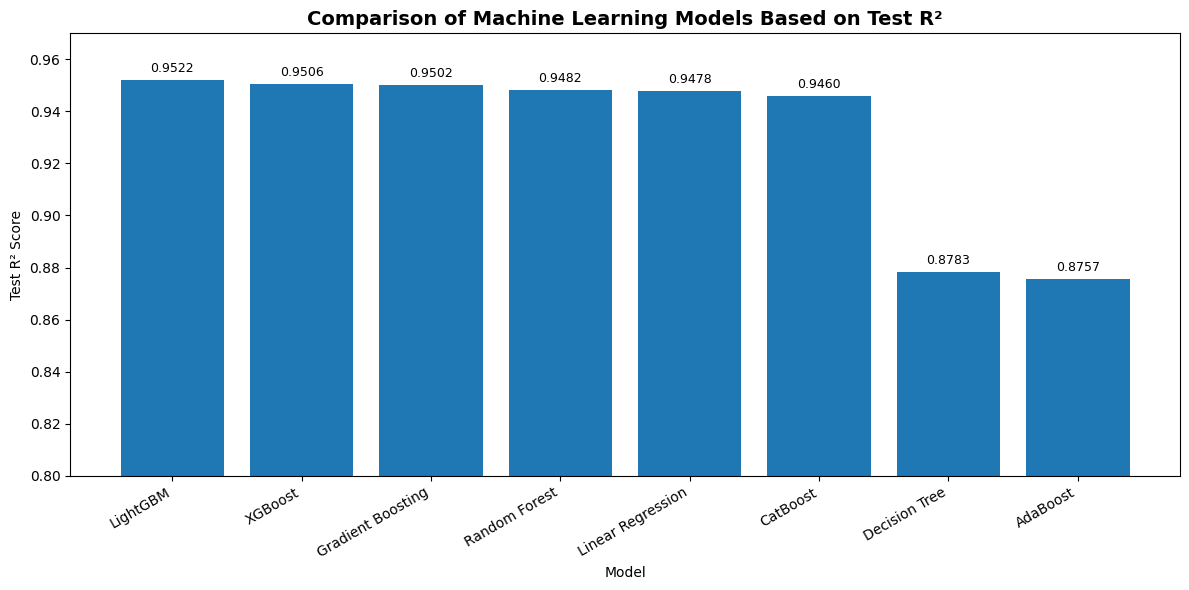

In [55]:
# ============================================================
# Test R² Comparison
# ============================================================

plt.figure(figsize=(12, 6))                                # Set figure size

bars = plt.bar(                                            # Bar chart of models vs Test R²
    model_comparison['Model'],                             # X-axis: model names
    model_comparison['Test R²']                            # Y-axis: Test R² scores
)

# Add chart title and axis labels
plt.title(
    'Comparison of Machine Learning Models Based on Test R²',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Model')                                        # Label x-axis
plt.ylabel('Test R² Score')                                # Label y-axis
plt.xticks(rotation=30, ha='right')                        # Rotate labels for readability
plt.ylim(0.80, 0.97)                                       # Set y-axis range for focus

# Display R² value above each bar
for bar, value in zip(bars, model_comparison['Test R²']):
    plt.text(
        bar.get_x() + bar.get_width()/2,                   # Center text above bar
        value + 0.003,                                     # Slightly above bar height
        f'{value:.4f}',                                    # Format to 4 decimals
        ha='center',
        fontsize=9
    )

plt.tight_layout()                                         # Optimize spacing
plt.show()                                                 # Display plot


### **Interpretation of Test R² Comparison**

* **LightGBM** achieved the highest Test R² of **0.9522**, indicating the strongest predictive performance among the evaluated models.

* **XGBoost (0.9506)** and **Gradient Boosting (0.9502)** followed closely, showing similarly strong performance.

* **Random Forest (0.9482)** and **Linear Regression (0.9478)** also achieved high Test R² values, indicating good predictive capability.

* **CatBoost (0.9460)** performed slightly lower than the other stronger models but still explained a large proportion of the variation in one-hour-ahead PM2.5 concentrations.

* **Decision Tree (0.8783)** and **AdaBoost (0.8757)** recorded substantially lower Test R² values, indicating weaker predictive performance on the unseen testing data.

### **Overall Observation**

* The Test R² comparison confirms that **LightGBM was the best-performing model**, with **XGBoost and Gradient Boosting** providing very competitive results.

* The relatively small differences among the top-performing models indicate that **LightGBM, XGBoost, and Gradient Boosting all provided strong predictive performance**, while Decision Tree and AdaBoost were comparatively weaker.


### **6.6.4 Training vs Testing R² Comparison**

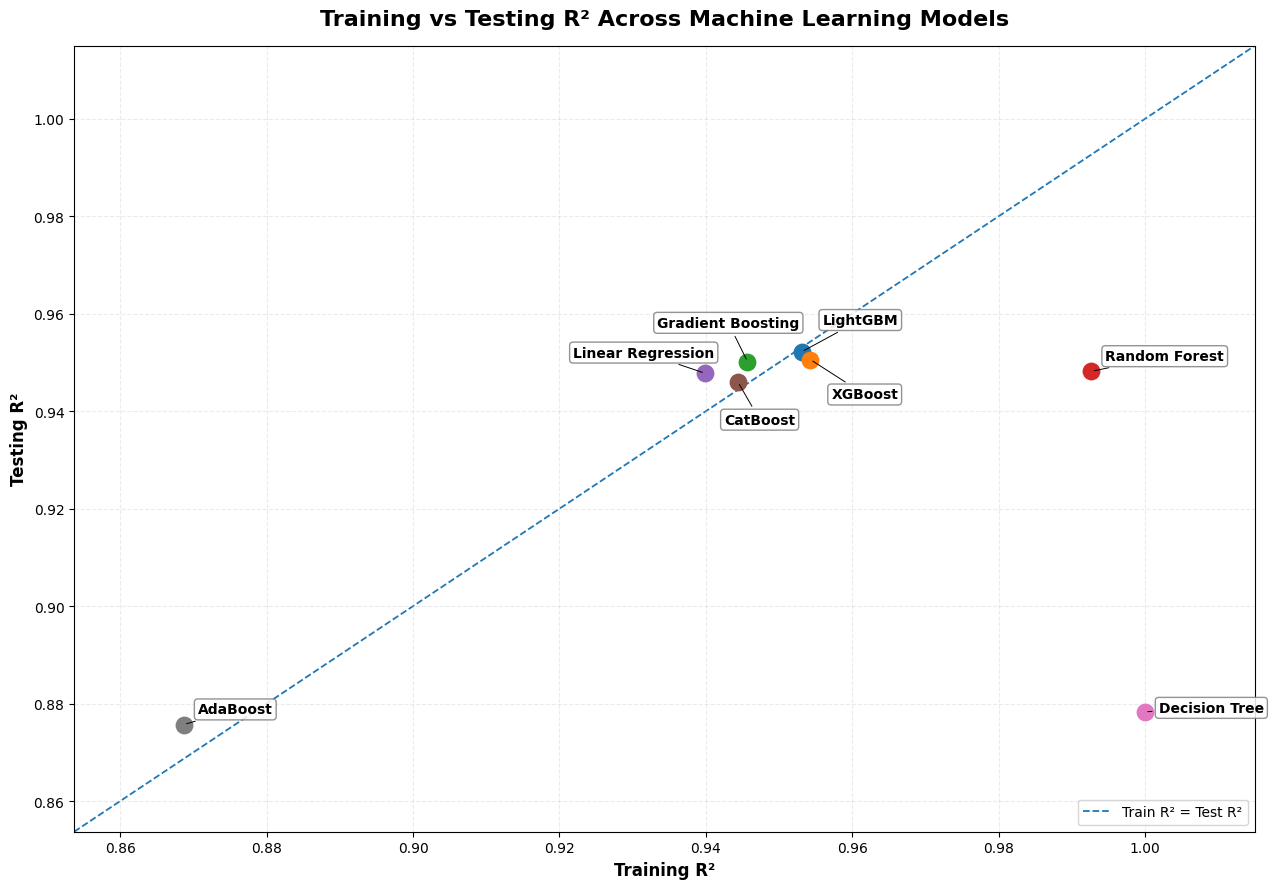

In [56]:
# ============================================================
# Training vs Testing R² Comparison
# ============================================================

import matplotlib.pyplot as plt                             # For plotting
import numpy as np                                          # For numerical operations

# Create larger figure for better readability
plt.figure(figsize=(13, 9))                                 # Set figure size (width=13, height=9)

# ------------------------------------------------------------
# Plot each model
# ------------------------------------------------------------

for _, row in model_comparison.iterrows():                  # Iterate through each model row
    plt.scatter(
        row['Train R²'],                                    # X-axis: Training R²
        row['Test R²'],                                     # Y-axis: Testing R²
        s=140,                                              # Marker size
        zorder=3                                            # Draw points above grid/lines
    )

# ------------------------------------------------------------
# Custom label positions to prevent overlap
# ------------------------------------------------------------

label_offsets = {                                           # Dictionary of manual label offsets
    'Linear Regression': (-95, 12),
    'Decision Tree': (10, 0),
    'Random Forest': (10, 8),
    'XGBoost': (15, -28),
    'Gradient Boosting': (-65, 25),
    'AdaBoost': (10, 8),
    'LightGBM': (15, 20),
    'CatBoost': (-10, -30)
}

# Add model labels
for _, row in model_comparison.iterrows():                  # Iterate again to annotate each point
    offset = label_offsets.get(                             # Get offset if defined, else default
        row['Model'],
        (10, 10)
    )

    plt.annotate(
        row['Model'],                                       # Label text = model name
        xy=(row['Train R²'], row['Test R²']),               # Coordinates of the point
        xytext=offset,                                      # Offset for readability
        textcoords='offset points',                         # Offset measured in points
        fontsize=10,                                        # Label font size
        fontweight='bold',                                  # Bold labels
        arrowprops=dict(                                    # Arrow from label to point
            arrowstyle='-',
            linewidth=0.7
        ),
        bbox=dict(                                          # Background box for label
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='gray',
            alpha=0.85
        )
    )

# ------------------------------------------------------------
# Automatically determine appropriate axis range
# ------------------------------------------------------------

all_r2 = np.concatenate([                                  # Combine Train + Test R² values
    model_comparison['Train R²'].values,
    model_comparison['Test R²'].values
])

min_r2 = all_r2.min()                                      # Minimum R² across all models
max_r2 = all_r2.max()                                      # Maximum R² across all models

padding = 0.015                                            # Small padding around limits

axis_min = min_r2 - padding                                # Lower axis bound
axis_max = max_r2 + padding                                # Upper axis bound

# ------------------------------------------------------------
# Reference line: Train R² = Test R²
# ------------------------------------------------------------

plt.plot(
    [axis_min, axis_max],                                  # X-axis range
    [axis_min, axis_max],                                  # Y-axis range (same for diagonal)
    linestyle='--',                                        # Dashed line
    linewidth=1.3,                                         # Line thickness
    label='Train R² = Test R²',                            # Legend label
    zorder=1                                               # Draw behind points
)

# ------------------------------------------------------------
# Titles and labels
# ------------------------------------------------------------

plt.title(
    'Training vs Testing R² Across Machine Learning Models', # Chart title
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Training R²',                                         # X-axis label
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Testing R²',                                          # Y-axis label
    fontsize=12,
    fontweight='bold'
)

# Apply dynamic axis limits
plt.xlim(axis_min, axis_max)                               # Set x-axis range
plt.ylim(axis_min, axis_max)                               # Set y-axis range

# Improve tick readability
plt.xticks(fontsize=10)                                    # X-axis tick font size
plt.yticks(fontsize=10)                                    # Y-axis tick font size

# Add grid
plt.grid(
    alpha=0.25,                                            # Transparency
    linestyle='--'                                         # Dashed gridlines
)

# Add reference-line legend
plt.legend(
    loc='lower right',                                     # Legend position
    fontsize=10                                            # Legend font size
)

# Optimize layout
plt.tight_layout()                                         # Adjust spacing for readability

# Display plot
plt.show()                                                 # Render chart


### **Interpretation of Training vs Testing R²**

* The plot compares **training R² with testing R²** for all evaluated machine learning models. The dashed diagonal line represents equal training and testing performance.

* **LightGBM, XGBoost, and Gradient Boosting** are positioned close to the diagonal line, indicating that their training and testing R² values are relatively similar. This suggests **good generalisation with limited evidence of overfitting**.

* **Linear Regression and CatBoost** also lie close to the diagonal, showing relatively consistent performance between the training and testing datasets.

* **Random Forest** is noticeably below the diagonal line. Its training R² (**0.9927**) is considerably higher than its testing R² (**0.9482**), indicating **some degree of overfitting**.

* **Decision Tree** shows the largest deviation from the diagonal, with a training R² of **1.0000** compared with a testing R² of **0.8783**. This indicates **strong overfitting**, as the model performs almost perfectly on the training data but substantially worse on unseen data.

* **AdaBoost** shows relatively similar training and testing R² values (**0.8687 and 0.8757**, respectively). Although this indicates consistent generalisation, its overall predictive performance is considerably lower than that of the other models.

### **Overall Observation**

* The plot indicates that **LightGBM provides a strong balance between high predictive performance and generalisation**.

* **Decision Tree and Random Forest** show the clearest signs of overfitting, while the boosting models generally demonstrate more consistent training and testing performance.


### **6.6.5 Leading Model Selection**

In [57]:
# ============================================================
# Leading Model Based on Test R²
# ============================================================

# Identify the model with the highest Test R²
top_r2_model = model_comparison.loc[                       # Select row with max Test R²
    model_comparison['Test R²'].idxmax()                   # idxmax() returns index of max value
]

print("=" * 70)
print("LEADING MODEL BASED ON TEST R²")
print("=" * 70)

print(f"Model      : {top_r2_model['Model']}")              # Print model name

print("\nTraining Performance")                            # Training metrics header
print(f"MAE        : {top_r2_model['Train MAE']:.2f}")     # Training Mean Absolute Error
print(f"RMSE       : {top_r2_model['Train RMSE']:.2f}")    # Training Root Mean Squared Error
print(f"R²         : {top_r2_model['Train R²']:.4f}")      # Training R² score

print("\nTesting Performance")                             # Testing metrics header
print(f"MAE        : {top_r2_model['Test MAE']:.2f}")      # Testing Mean Absolute Error
print(f"RMSE       : {top_r2_model['Test RMSE']:.2f}")     # Testing Root Mean Squared Error
print(f"R²         : {top_r2_model['Test R²']:.4f}")       # Testing R² score


LEADING MODEL BASED ON TEST R²
Model      : LightGBM

Training Performance
MAE        : 9.77
RMSE       : 17.33
R²         : 0.9531

Testing Performance
MAE        : 9.67
RMSE       : 18.26
R²         : 0.9522


### **Interpretation**

### **Leading Model: LightGBM**

* **LightGBM** was identified as the leading model based on its **highest Test R² of 0.9522**.

* The model achieved a **Training MAE of 9.77 µg/m³**, **Training RMSE of 17.33 µg/m³**, and **Training R² of 0.9531**.

* On the unseen chronological testing dataset, LightGBM achieved a **Test MAE of 9.67 µg/m³**, **Test RMSE of 18.26 µg/m³**, and **Test R² of 0.9522**.

* The close training and testing R² values (**0.9531 vs. 0.9522**) indicate **consistent performance and good generalisation** to the unseen testing period.

* Overall, LightGBM provided the **best combination of low forecasting error and high explanatory power** among the evaluated models and was therefore selected as the leading model for one-hour-ahead PM2.5 forecasting.



## **6.7 Time-Series Cross-Validation**

* To further evaluate the robustness and temporal generalizability of the **selected LightGBM model**, time-series cross-validation was performed. LightGBM was selected based on its superior performance on the chronological testing dataset, achieving the lowest testing **MAE (9.67 µg/m³)** and **RMSE (18.26 µg/m³)**, and the highest testing **R² (0.9522)** among the evaluated models.

*  A **five-fold expanding-window time-series cross-validation** strategy was used. The training window expands chronologically across the folds, while each validation fold consists of the immediately following time block. This approach preserves temporal order and provides a realistic assessment of the model's ability to generalize to future observations.

* Model performance across the five validation folds was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**. The mean performance and variation across the folds were examined to assess the **stability and temporal robustness of the selected LightGBM model**.


In [ ]:
# ============================================================
# 6.7 Time-Series Cross-Validation - LightGBM
# ============================================================

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Prepare chronological training data for cross-validation
# ------------------------------------------------------------

# Obtain timestamps corresponding to the training observations
cv_datetime = datetime_time.loc[X_train.index]             # Align timestamps with training indices

# Identify unique timestamps in chronological order
unique_times = np.sort(cv_datetime.unique())               # Sorted unique time points

# Divide the training period into 6 chronological blocks
# Block 1 = initial training window
# Blocks 2-6 = five sequential validation periods
time_blocks = np.array_split(unique_times, 6)

# Store results from each validation fold
cv_results = []

print("=" * 70)
print("LIGHTGBM TIME-SERIES CROSS-VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Perform expanding-window chronological cross-validation
# ------------------------------------------------------------

for fold in range(1, 6):

    # Training uses all earlier time blocks
    train_times = np.concatenate(time_blocks[:fold])

    # Validation uses the immediately following time block
    val_times = time_blocks[fold]

    # Create masks based on timestamps
    train_mask_cv = cv_datetime.isin(train_times)
    val_mask_cv = cv_datetime.isin(val_times)

    # Select training observations
    X_cv_train = X_train.loc[train_mask_cv]
    y_cv_train = y_train.loc[train_mask_cv]

    # Select validation observations
    X_cv_val = X_train.loc[val_mask_cv]
    y_cv_val = y_train.loc[val_mask_cv]

    # --------------------------------------------------------
    # Initialize LightGBM using the same settings as the
    # original selected LightGBM model
    # --------------------------------------------------------

    cv_model = LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbosity=-1
    )

    # Train model on earlier observations
    cv_model.fit(X_cv_train, y_cv_train)

    # Predict the subsequent validation period
    y_cv_pred = cv_model.predict(X_cv_val)

    # --------------------------------------------------------
    # Calculate validation metrics
    # --------------------------------------------------------

    fold_mae = mean_absolute_error(y_cv_val, y_cv_pred)    # Mean Absolute Error
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val, y_cv_pred)) # Root Mean Squared Error
    fold_r2 = r2_score(y_cv_val, y_cv_pred)                # R² score

    # Store fold results
    cv_results.append({
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R²': fold_r2
    })

    # --------------------------------------------------------
    # Display fold results
    # --------------------------------------------------------

    print(f"\nFold {fold}")
    print(f"Training observations   : {len(X_cv_train):,}")
    print(f"Validation observations : {len(X_cv_val):,}")
    print(f"Training period         : {pd.Timestamp(train_times.min())} to {pd.Timestamp(train_times.max())}")
    print(f"Validation period       : {pd.Timestamp(val_times.min())} to {pd.Timestamp(val_times.max())}")
    print(f"MAE                     : {fold_mae:.2f}")
    print(f"RMSE                    : {fold_rmse:.2f}")
    print(f"R²                      : {fold_r2:.4f}")


# ------------------------------------------------------------
# Cross-validation summary
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)

display(cv_results_df.round({'MAE': 2, 'RMSE': 2, 'R²': 4}))

# ------------------------------------------------------------
# Average performance across folds
# ------------------------------------------------------------

print("\nAverage Performance")
print(f"Mean MAE  : {cv_results_df['MAE'].mean():.2f}")
print(f"Mean RMSE : {cv_results_df['RMSE'].mean():.2f}")
print(f"Mean R²   : {cv_results_df['R²'].mean():.4f}")

# ------------------------------------------------------------
# Variation across folds
# ------------------------------------------------------------

print("\nVariation Across Folds")
print(f"MAE Std Dev  : {cv_results_df['MAE'].std():.4f}")
print(f"RMSE Std Dev : {cv_results_df['RMSE'].std():.4f}")
print(f"R² Std Dev   : {cv_results_df['R²'].std():.4f}")


LIGHTGBM TIME-SERIES CROSS-VALIDATION

Fold 1
Training observations   : 54,722
Validation observations : 55,272
Training period         : 2013-03-01 00:00:00 to 2013-09-11 05:00:00
Validation period       : 2013-09-11 06:00:00 to 2014-03-25 12:00:00
MAE                     : 20.32
RMSE                    : 38.56
R²                      : 0.8258

Fold 2
Training observations   : 109,994
Validation observations : 54,259
Training period         : 2013-03-01 00:00:00 to 2014-03-25 12:00:00
Validation period       : 2014-03-25 13:00:00 to 2014-10-05 18:00:00
MAE                     : 9.37
RMSE                    : 15.99
R²                      : 0.9235

Fold 3
Training observations   : 164,253
Validation observations : 54,294
Training period         : 2013-03-01 00:00:00 to 2014-10-05 18:00:00
Validation period       : 2014-10-05 19:00:00 to 2015-04-18 18:00:00
MAE                     : 10.92
RMSE                    : 19.87
R²                      : 0.9498

Fold 4
Training observations   : 

,Fold,MAE,RMSE,R²
0,1,20.32,38.56,0.8258
1,2,9.37,15.99,0.9235
2,3,10.92,19.87,0.9498
3,4,7.83,13.40,0.9418
4,5,11.49,24.33,0.9422



Average Performance
Mean MAE  : 11.98
Mean RMSE : 22.43
Mean R²   : 0.9166

Variation Across Folds
MAE Std Dev  : 4.8721
RMSE Std Dev : 9.9146
R² Std Dev   : 0.0517


### **Note:**

* Cross-validation was performed using **chronological time-based folds** rather than random sampling. Observations sharing the same timestamp were kept within the same fold to preserve temporal integrity across the **12 monitoring stations** and prevent observations from the same hour from being divided between the training and validation sets.


### **Interpretation**

### **Time-Series Cross-Validation Results**

* The five-fold expanding-window time-series cross-validation of the selected **LightGBM model** produced a mean **MAE of 11.98 µg/m³**, mean **RMSE of 22.43 µg/m³**, and mean **R² of 0.9166** across the validation folds.

* Performance varied across the chronological validation periods. **Fold 4** achieved the strongest performance, with an **MAE of 7.83 µg/m³**, **RMSE of 13.40 µg/m³**, and **R² of 0.9418**.

* **Fold 1** showed the weakest performance, with an **MAE of 20.32 µg/m³**, **RMSE of 38.56 µg/m³**, and **R² of 0.8258**. This indicates that the model's predictive performance was lower during the earliest validation period.

* Across the remaining folds, the model achieved **R² values between 0.9235 and 0.9498**, indicating relatively strong predictive performance during these periods.

* The **R² standard deviation of 0.0517** indicates some variation in model performance across different chronological periods. The MAE and RMSE standard deviations were **4.87 µg/m³** and **9.91 µg/m³**, respectively.

### **Overall Observation**

* The cross-validation results indicate that **LightGBM provides generally strong predictive performance across most chronological validation periods**, although performance is not completely consistent across all periods.

* The lower performance in Fold 1 contributes substantially to the overall variation, while the subsequent folds show considerably stronger and more consistent performance.

* These results provide additional evidence of the **temporal generalizability of LightGBM**, while also highlighting that forecasting accuracy can vary depending on the underlying characteristics of the time period being predicted.


## **6.8 Feature Importance Analysis**

* Feature importance analysis was performed for the **selected LightGBM model**, which achieved the strongest overall performance on the chronological testing dataset.

* The analysis was conducted to identify the predictor variables that contributed most to the model's **one-hour-ahead PM2.5 forecasts**.

* Since LightGBM is a tree-based ensemble model, feature importance was evaluated using **gain-based feature importance**. Gain measures the contribution of each feature to reducing prediction error across the trees in the ensemble.

* The features were ranked according to their total gain, with higher importance values indicating a greater contribution to the model's predictive decisions.

* The **top 15 most important predictor variables** were examined to identify the environmental, meteorological, temporal, and location-related variables that contributed most to the one-hour-ahead PM2.5 predictions.


### **6.8.1 Feature Importance Using Gain-Based Importance**

TOP 15 FEATURES - LIGHTGBM


,Feature,Importance,Importance (%)
0,PM2.5,1.033017e+10,98.17
1,PM10,4.549376e+07,0.43
2,WSPM,3.770443e+07,0.36
3,hour,2.050212e+07,0.19
4,DEWP,1.634332e+07,0.16
5,TEMP,1.320760e+07,0.13
6,CO,1.087234e+07,0.10
7,RAIN,9.248278e+06,0.09
8,NO2,7.026382e+06,0.07
9,SO2,6.685264e+06,0.06


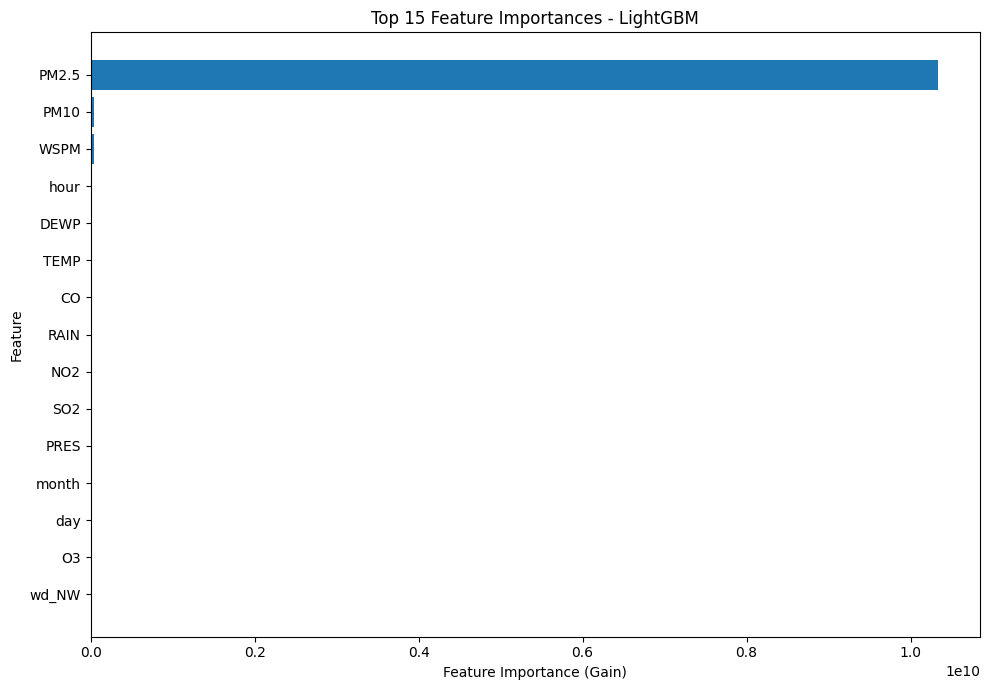

In [66]:
# ============================================================
# 6.8 Feature Importance Analysis - LightGBM
#     Using Gain-Based Feature Importance
# ============================================================

# ------------------------------------------------------------
# Extract feature importance from the fitted LightGBM model
# ------------------------------------------------------------

# Get feature importance based on total gain
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,                           # Predictor names
    'Importance': lgbm_model.booster_.feature_importance( # Gain-based importance
        importance_type='gain'
    )
})

# ------------------------------------------------------------
# Calculate percentage contribution
# ------------------------------------------------------------

total_importance = feature_importance['Importance'].sum() # Total gain across all features

feature_importance['Importance (%)'] = (
    feature_importance['Importance'] / total_importance * 100
)

# ------------------------------------------------------------
# Sort features by importance
# ------------------------------------------------------------

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Select top 15 features
# ------------------------------------------------------------

top_features = feature_importance.head(15)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("TOP 15 FEATURES - LIGHTGBM")
print("=" * 70)

display(
    top_features.round({
        'Importance': 2,
        'Importance (%)': 2
    })
)

# ------------------------------------------------------------
# Plot top 15 features
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'][::-1],                        # Reverse order for top at top
    top_features['Importance'][::-1]                      # Importance scores
)

plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - LightGBM")

plt.tight_layout()
plt.show()


### **Interpretation**

* **Current-hour PM2.5 is by far the most influential predictor**, accounting for approximately **98.17% of the total gain-based feature importance**.

* This indicates that the PM2.5 concentration observed at the current hour provides the **strongest information for predicting PM2.5 concentration one hour ahead**.

* The dominance of current-hour PM2.5 suggests **strong short-term persistence in PM2.5 concentrations**, where current pollution levels are highly informative about near-future pollution levels.

* Other predictors, including **PM10, WSPM, hour, DEWP, TEMP, CO, RAIN, NO2, SO2, PRES, month, day, O3, and wind direction**, provide additional information, but their individual contributions are substantially smaller.

* Overall, the results indicate that **current-hour PM2.5 is the primary predictor of the one-hour-ahead forecast**, while meteorological, pollutant, and temporal variables provide supplementary predictive information.


## **6.9 SHAP Analysis - LightGBM**

* **SHAP (SHapley Additive exPlanations)** analysis was performed on the **selected LightGBM model** to provide additional interpretability for the one-hour-ahead PM2.5 forecasts. While the gain-based feature importance analysis identifies the relative contribution of predictors at the global model level, SHAP analysis provides a more detailed explanation of how individual predictor values contribute to the model's predictions.

* A representative sample of the **chronological testing dataset** was used for the SHAP analysis to improve computational efficiency while ensuring that the explanations were based on observations from the unseen testing period.

* The **SHAP summary plot** was used to identify the predictors with the greatest overall influence on the model's forecasts and to examine how higher or lower feature values influenced the predicted **next-hour PM2.5 concentration**.

* This analysis complements the gain-based feature importance analysis by providing an additional model-interpretability perspective on the factors influencing the **one-hour-ahead PM2.5 forecasts**.


### **6.9.1 SHAP Analysis Setup**

In [68]:
# ============================================================
# 6.9.1 SHAP Analysis Setup - LightGBM
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Select representative observations from the chronological
# testing dataset
# ------------------------------------------------------------

X_shap = X_test.sample(
    n=min(5000, len(X_test)),       # Use up to 5,000 unseen test observations
    random_state=42                 # Fixed seed for reproducibility
)

# ------------------------------------------------------------
# Create SHAP TreeExplainer for the selected LightGBM model
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    lgbm_model                      # Final fitted LightGBM model
)

# ------------------------------------------------------------
# Calculate SHAP values for the test observations
# ------------------------------------------------------------

shap_values = explainer(
    X_shap                          # Compute SHAP values for sampled test set
)

# ------------------------------------------------------------
# Display analysis information
# ------------------------------------------------------------

print("=" * 70)
print("SHAP ANALYSIS - LIGHTGBM")
print("=" * 70)

print("Observations used for SHAP analysis:", len(X_shap))       # Number of test samples
print("Number of predictor variables:", X_shap.shape[1])         # Feature count
print("SHAP values shape:", shap_values.values.shape)            # Dimensions of SHAP output


SHAP ANALYSIS - LIGHTGBM
Observations used for SHAP analysis: 5000
Number of predictor variables: 41
SHAP values shape: (5000, 41)


### **Interpretation**

* The SHAP analysis was performed using **5,000 observations from the chronological testing dataset** and all **41 predictor variables**. The resulting SHAP value matrix had a shape of **(5,000, 41)**, indicating that a SHAP contribution was calculated for each predictor for every sampled test observation.

* This provides a basis for examining the **LightGBM model's predictions at both the global and individual levels**: globally, SHAP values can identify the predictors with the greatest overall influence, while at the individual level, they show how specific predictor values contribute to each one-hour-ahead PM2.5 prediction.


### **6.9.2 SHAP Summary Plot**

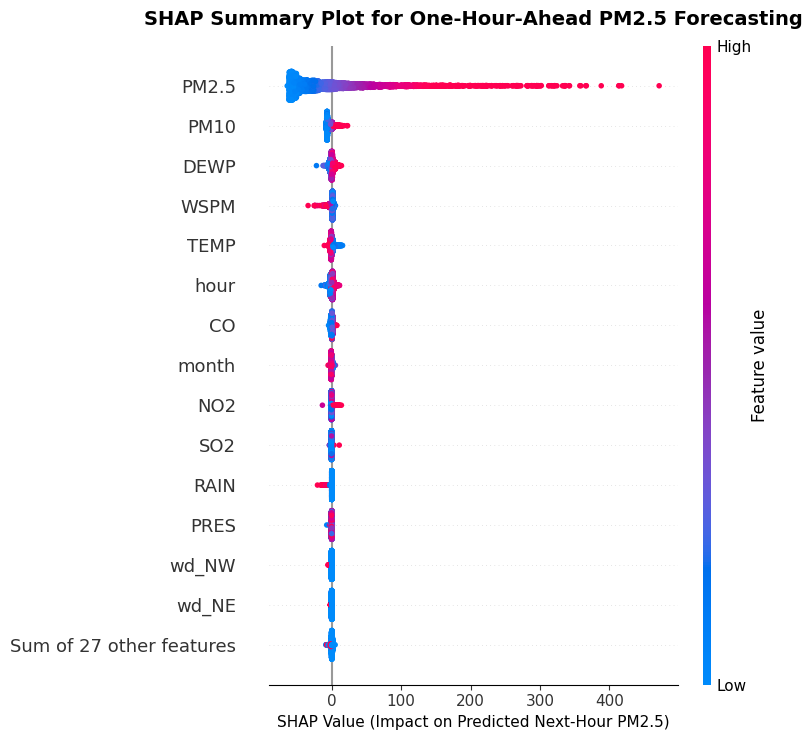

In [69]:
# ============================================================
# 6.9.2 SHAP Summary Plot - LightGBM
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Convert SHAP feature values to numeric format for plotting
# ------------------------------------------------------------

X_shap_numeric = X_shap.astype(float)                      # Ensure numeric dtype for plotting

# Create a clean SHAP Explanation object
shap_explanation = shap.Explanation(
    values=np.asarray(shap_values.values, dtype=float),    # SHAP values
    base_values=np.asarray(shap_values.base_values, dtype=float), # Base values (expected prediction)
    data=X_shap_numeric.to_numpy(dtype=float),             # Feature matrix
    feature_names=X_shap_numeric.columns.tolist()          # Feature names
)

# ------------------------------------------------------------
# Create SHAP beeswarm summary plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))                                # Set figure size

shap.plots.beeswarm(
    shap_explanation,                                      # SHAP explanation object
    max_display=15,                                        # Show top 15 features
    show=False                                             # Prevent auto-display
)

# Add customized title
plt.title(
    'SHAP Summary Plot for One-Hour-Ahead PM2.5 Forecasting',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# Add clear x-axis label
plt.xlabel(
    'SHAP Value (Impact on Predicted Next-Hour PM2.5)',
    fontsize=11
)

plt.tight_layout()                                         # Adjust layout for neatness

# Display plot
plt.show()


### **Interpretation of the SHAP Summary Plot**

* **PM2.5 is the most influential predictor** of the one-hour-ahead PM2.5 forecast by a very large margin. Its SHAP values extend substantially farther from zero than those of the other predictors, indicating a much stronger influence on the model's predictions.

* For **PM2.5**, higher feature values (red points) are predominantly associated with **positive SHAP values**, meaning that higher current PM2.5 concentrations generally increase the predicted next-hour PM2.5 concentration. Lower PM2.5 values (blue points) are generally associated with lower or negative SHAP values.

* **PM10** is the second most influential predictor, although its overall impact is considerably smaller than that of PM2.5. **DEWP, WSPM, TEMP, hour, CO, month, NO2, SO2, RAIN, PRES, wd_NW, and wd_NE** have progressively smaller overall SHAP impacts.

* The plot therefore indicates that the LightGBM model's one-hour-ahead predictions are driven primarily by **current PM2.5 concentration**, with PM10 and meteorological and temporal variables providing additional, but substantially smaller, contributions.

* Importantly, **SHAP values describe the contribution of each feature to the model's predictions and should not be interpreted as evidence of causal relationships**.


### **6.9.3 SHAP Feature Importance**

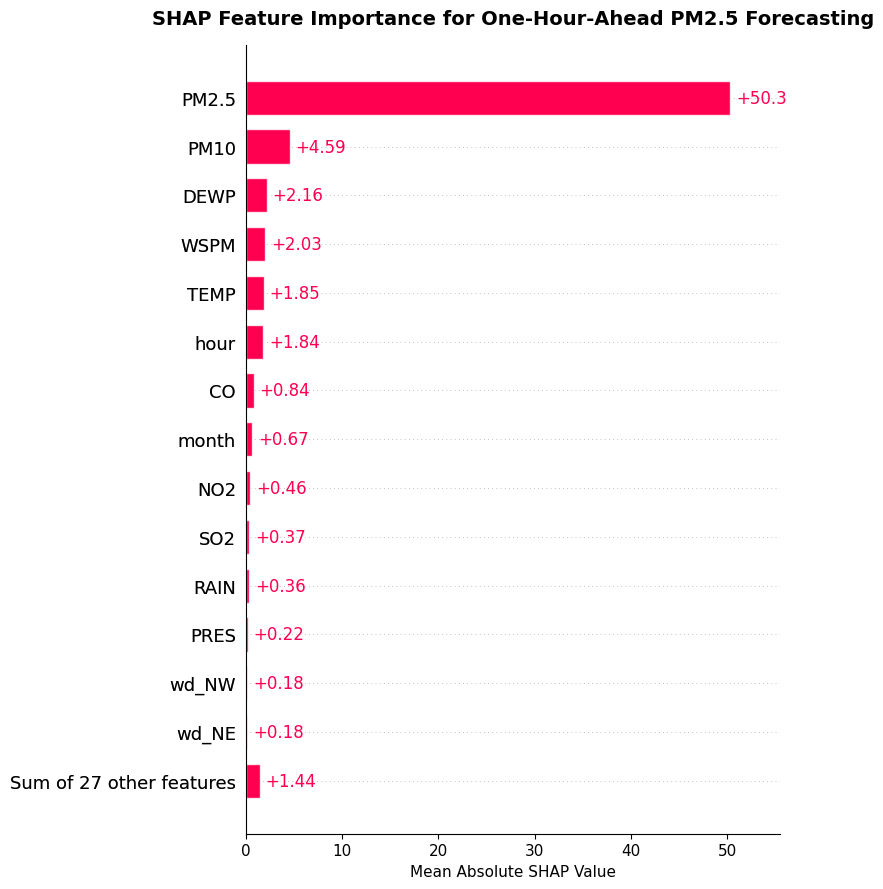

In [70]:
# ============================================================
# 6.9.3 SHAP Feature Importance - LightGBM
# ============================================================

import shap
import matplotlib.pyplot as plt

# Create SHAP feature importance bar plot
# Importance is based on mean absolute SHAP values
shap.plots.bar(
    shap_explanation,                                     # SHAP explanation object
    max_display=15,                                       # Show top 15 features
    show=False                                            # Prevent auto-display
)

# Add customized title
plt.title(
    'SHAP Feature Importance for One-Hour-Ahead PM2.5 Forecasting',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# Add clear x-axis label
plt.xlabel(
    'Mean Absolute SHAP Value',                           # Average magnitude of impact
    fontsize=11
)

# Improve plot spacing
plt.tight_layout()

# Display plot
plt.show()


### **Interpretation of SHAP Feature Importance**

* The mean absolute SHAP values show that **PM2.5 is the dominant predictor** of the one-hour-ahead PM2.5 forecasts, with a mean absolute SHAP value of **50.3**. This is substantially higher than the other predictors.

* **PM10** is the second most influential feature (**4.59**), followed by **DEWP (2.16), WSPM (2.03), TEMP (1.85), and hour (1.84)**. Other variables, including **CO, month, NO2, SO2, RAIN, PRES, wd_NW, and wd_NE**, have considerably smaller average contributions.

* These results are consistent with the **gain-based LightGBM feature-importance analysis**, which also identified **PM2.5 as overwhelmingly the most influential predictor**. The SHAP analysis therefore provides additional evidence that the current PM2.5 concentration is the primary source of predictive information for forecasting the next-hour PM2.5 concentration, while PM10, meteorological conditions, and temporal variables provide smaller complementary contributions.

* The mean absolute SHAP values represent the **average magnitude of each feature's contribution to the model's predictions**. They indicate feature influence, but **should not be interpreted as causal effects**.


### **6.9.4 Comparison of Feature Importance Methods - LightGBM**
 **Gain-Based Importance vs SHAP Importance**

In [71]:
# ============================================================
# 6.9.4 Comparison of Feature Importance Methods - LightGBM
#     Gain-Based Importance vs SHAP Importance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Calculate mean absolute SHAP importance
# ------------------------------------------------------------

shap_importance = pd.DataFrame({
    'Feature': X_shap.columns,                            # Predictor names
    'SHAP Importance': np.abs(shap_values.values).mean(axis=0)  # Mean absolute SHAP values
})

# Sort SHAP importance from highest to lowest
shap_importance = shap_importance.sort_values(
    by='SHAP Importance',
    ascending=False
).reset_index(drop=True)

# Add SHAP rank
shap_importance['SHAP Rank'] = shap_importance.index + 1

# ------------------------------------------------------------
# Prepare LightGBM gain-based importance
# ------------------------------------------------------------

gain_importance = feature_importance[['Feature', 'Importance']].copy()
gain_importance = gain_importance.rename(columns={'Importance': 'Gain Importance'})

# Add Gain rank
gain_importance['Gain Rank'] = (
    gain_importance['Gain Importance']
    .rank(method='min', ascending=False)
    .astype(int)
)

# ------------------------------------------------------------
# Merge both importance measures
# ------------------------------------------------------------

importance_comparison = pd.merge(
    gain_importance,
    shap_importance[['Feature', 'SHAP Importance', 'SHAP Rank']],
    on='Feature',
    how='inner'
)

# ------------------------------------------------------------
# Sort according to LightGBM gain importance
# ------------------------------------------------------------

importance_comparison = importance_comparison.sort_values(
    by='Gain Importance',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Display top 15 features
# ------------------------------------------------------------

print("=" * 80)
print("LIGHTGBM FEATURE IMPORTANCE COMPARISON")
print("GAIN-BASED IMPORTANCE VS SHAP IMPORTANCE")
print("=" * 80)

display(
    importance_comparison[
        ['Feature', 'Gain Importance', 'Gain Rank', 'SHAP Importance', 'SHAP Rank']
    ].head(15).round(3)
)


LIGHTGBM FEATURE IMPORTANCE COMPARISON
GAIN-BASED IMPORTANCE VS SHAP IMPORTANCE


,Feature,Gain Importance,Gain Rank,SHAP Importance,SHAP Rank
0,PM2.5,1.033017e+10,1,50.304,1
1,PM10,4.549376e+07,2,4.592,2
2,WSPM,3.770443e+07,3,2.031,4
3,hour,2.050212e+07,4,1.840,6
4,DEWP,1.634332e+07,5,2.164,3
5,TEMP,1.320760e+07,6,1.851,5
6,CO,1.087234e+07,7,0.844,7
7,RAIN,9.248278e+06,8,0.356,11
8,NO2,7.026382e+06,9,0.464,9
9,SO2,6.685264e+06,10,0.367,10


### **Interpretation**

The comparison between LightGBM gain-based feature importance and SHAP importance shows **strong agreement among the most influential predictors** of one-hour-ahead PM2.5 forecasts.

* **PM2.5 is by far the dominant predictor**, ranking first under both methods. It has a gain importance of **98.17%** and the highest SHAP importance (**50.304**), indicating that the current PM2.5 concentration makes the largest contribution to predicting the next-hour concentration.

* **PM10 is the second most influential predictor** in both analyses, ranking **2nd** for both gain-based and SHAP importance.

* **WSPM, DEWP, TEMP, hour, and CO** consistently appear among the higher-ranked predictors, although their exact rankings differ slightly between the two methods.

* The differences in rankings for variables such as **RAIN, month, day, O3, and wind-direction variables** indicate that their influence is more moderate and method-dependent.

* Overall, the agreement between the two approaches provides **additional confidence that PM2.5, PM10, meteorological variables, and selected temporal variables are important predictors** in the LightGBM model.

* The differences between gain-based and SHAP rankings are expected because **gain importance measures the contribution of a feature to tree-splitting improvements**, whereas **SHAP importance measures the average magnitude of that feature's contribution to individual predictions**.

**Overall, the results confirm that the LightGBM model relies most strongly on the current PM2.5 concentration, with PM10 and several meteorological and temporal variables providing additional predictive information.**


### **6.9.5 Comparative Visualization of Feature Importance**

**LightGBM Gain-Based Importance vs SHAP Importance**

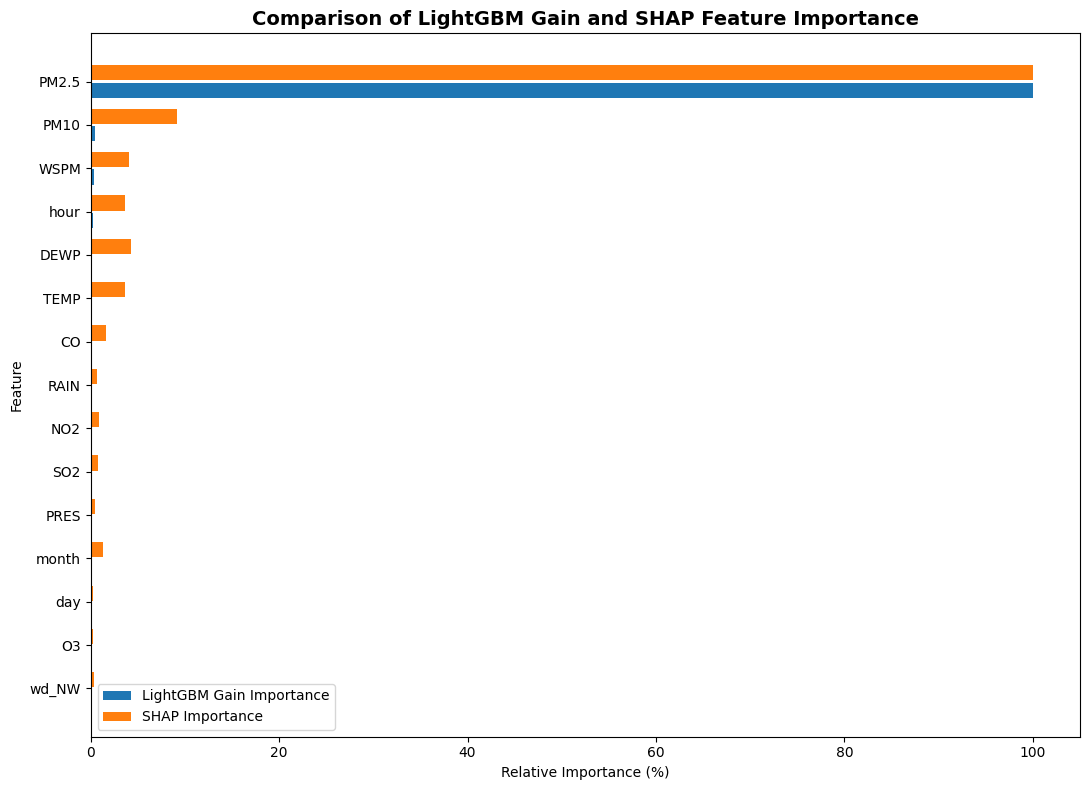

In [72]:
# ============================================================
# Top 15 Feature Importance Comparison
# ============================================================

comparison_plot = importance_comparison.head(15).copy()    # Keep top 15 features

# Normalize both measures to 0–100 for visual comparison
comparison_plot['Gain Score (%)'] = (
    comparison_plot['Gain Importance']
    / comparison_plot['Gain Importance'].max() * 100       # Scale Gain importance
)

comparison_plot['SHAP Score (%)'] = (
    comparison_plot['SHAP Importance']
    / comparison_plot['SHAP Importance'].max() * 100       # Scale SHAP importance
)

# Reverse order so the highest-ranked feature appears at the top
comparison_plot = comparison_plot.sort_values(
    by='Gain Importance',
    ascending=True
)

# ------------------------------------------------------------
# Create comparison plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))                                # Set figure size

y = range(len(comparison_plot))                            # Y positions for bars

# Horizontal bars for Gain importance
plt.barh(
    [i - 0.2 for i in y],                                  # Shift down slightly
    comparison_plot['Gain Score (%)'],
    height=0.35,
    label='LightGBM Gain Importance'
)

# Horizontal bars for SHAP importance
plt.barh(
    [i + 0.2 for i in y],                                  # Shift up slightly
    comparison_plot['SHAP Score (%)'],
    height=0.35,
    label='SHAP Importance'
)

# Y-axis labels = feature names
plt.yticks(
    y,
    comparison_plot['Feature']
)

# Axis labels and title
plt.xlabel('Relative Importance (%)')
plt.ylabel('Feature')
plt.title(
    'Comparison of LightGBM Gain and SHAP Feature Importance',
    fontsize=14,
    fontweight='bold'
)

plt.legend()                                               # Add legend
plt.tight_layout()                                         # Adjust layout
plt.show()                                                 # Display plot


### **Interpretation**

The comparison plot shows that the **LightGBM gain-based importance and SHAP importance identify a broadly similar pattern of influential predictors**, particularly among the top features.

* **PM2.5 is clearly the dominant predictor** under both methods, with a relative importance of approximately **100%** in the normalized comparison. This indicates that the current PM2.5 concentration has by far the greatest influence on the one-hour-ahead PM2.5 predictions.

* **PM10 is the second most influential feature**, although its SHAP importance is noticeably higher relative to its gain-based importance. This confirms that PM10 provides substantial additional predictive information.

* **WSPM, DEWP, TEMP, and hour** form the next group of relatively important predictors. Their rankings differ somewhat between the two approaches, but they consistently appear among the leading variables.

* **CO, RAIN, NO2, SO2, PRES, month, day, O3, and wd_NW** have considerably smaller relative importance compared with PM2.5 and PM10.

* The differences between the blue and orange bars demonstrate that **gain-based importance and SHAP importance are not measuring exactly the same quantity**. Therefore, differences in the magnitude or ranking of individual features are expected.

* Overall, the comparison provides **consistent evidence that current PM2.5 concentration is the primary predictor**, while PM10, meteorological conditions, and temporal variables contribute additional information to the LightGBM model.

**Overall conclusion:** The two interpretability methods provide complementary evidence and strengthen the finding that the LightGBM model's one-hour-ahead PM2.5 forecasts are driven predominantly by the current PM2.5 concentration, with PM10 and selected meteorological and temporal variables playing secondary roles.


## **6.10 Final Model Evaluation**

* Based on the comparative evaluation of the machine learning models, **LightGBM emerged as the best-performing model** for one-hour-ahead PM2.5 forecasting based on the latest chronological testing results.

* On the **chronological training dataset**, LightGBM achieved an **MAE of 9.77 µg/m³**, **RMSE of 17.33 µg/m³**, and **R² of 0.9531**. On the unseen **chronological testing dataset**, the model achieved an **MAE of 9.67 µg/m³**, **RMSE of 18.26 µg/m³**, and **R² of 0.9522**.

* The close similarity between the training and testing performance indicates that the model maintained strong predictive performance on the unseen chronological testing period, with no substantial evidence of overfitting.

* Gain-based feature importance identified **current-hour PM2.5 as the dominant predictor**, followed by **PM10, WSPM, hour, DEWP, and TEMP**.

* SHAP analysis provided a complementary interpretation of the LightGBM model and similarly identified **current-hour PM2.5 as the most influential predictor** of the next-hour PM2.5 forecast.

* The agreement between the gain-based feature importance and SHAP analysis provides consistent evidence regarding the key predictors contributing to the model's one-hour-ahead PM2.5 forecasts.

* Overall, the chronological testing results and model interpretability analyses provide evidence that **LightGBM provides a strong predictive framework for one-hour-ahead PM2.5 forecasting** using the available air-pollution, meteorological, temporal, and location-related information.


# **7. Results and Discussion**

The performance of eight machine learning models -**Linear Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting, AdaBoost, LightGBM, and CatBoost** - was evaluated for **one-hour-ahead PM2.5 forecasting**. Model performance was assessed using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²)** on a chronological testing dataset.

* **LightGBM emerged as the best-performing model based on the latest chronological testing results**, achieving a testing **MAE of 9.67 µg/m³**, **RMSE of 18.26 µg/m³**, and **R² of 0.9522**.

* LightGBM achieved a training **MAE of 9.77 µg/m³**, **RMSE of 17.33 µg/m³**, and **R² of 0.9531**. The close similarity between training and testing performance indicates good generalization to the unseen chronological testing period.

* The results demonstrate that LightGBM was able to capture the relationships between PM2.5 and the available pollutant, meteorological, temporal, and location-related predictors while maintaining strong performance on unseen observations.

* The small difference between the training and testing metrics provides **no substantial indication of overfitting**, supporting the suitability of LightGBM for the forecasting task.


### **Model Robustness and Interpretability**

* **LightGBM was selected as the final forecasting model** based on its strong chronological testing performance, achieving a testing **R² of 0.9522**, **RMSE of 18.26 µg/m³**, and **MAE of 9.67 µg/m³**.

* Gain-based feature importance identified **current-hour PM2.5 as the dominant predictor**, followed by **PM10, WSPM, hour, DEWP, and TEMP**.

* SHAP analysis provided consistent evidence of the dominant role of current-hour PM2.5, with a mean absolute SHAP value of approximately **50.3**, substantially higher than that of the other predictors.

* The agreement between **LightGBM gain-based importance and SHAP importance** strengthens the interpretation that current-hour PM2.5 provides the greatest predictive information for forecasting PM2.5 one hour ahead.

* Other predictors, including **PM10, WSPM, DEWP, TEMP, hour, and CO**, provided additional predictive information, although their individual contributions were considerably smaller than that of current-hour PM2.5.


### **Overall Observation**

The results demonstrate that **LightGBM provided strong predictive performance for one-hour-ahead PM2.5 forecasting**, achieving a testing **R² of 0.9522**, **RMSE of 18.26 µg/m³**, and **MAE of 9.67 µg/m³**.

**LightGBM was selected as the final model** based on its strong chronological testing performance and close agreement between training and testing results, indicating good generalization to unseen future observations.

The feature-importance and SHAP analyses consistently identified **current-hour PM2.5 as the dominant predictor**, while **PM10, WSPM, DEWP, TEMP, hour, and other pollutant and temporal variables** provided additional predictive information.

Overall, the findings support **LightGBM as an effective model for one-hour-ahead PM2.5 forecasting** using the available air-pollution, meteorological, temporal, and location-related information.


# **8. Conclusion**

This study developed and evaluated eight machine learning algorithms—**Linear Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting, AdaBoost, LightGBM, and CatBoost**—for **one-hour-ahead PM2.5 forecasting** using pollutant, meteorological, temporal, and location-related variables from the **Beijing Multi-Site Air Quality Dataset**.

Among the evaluated models, **LightGBM emerged as the final selected model**, achieving a **testing MAE of 9.67 µg/m³**, **RMSE of 18.26 µg/m³**, and **R² of 0.9522** on the unseen chronological testing dataset. The corresponding training performance was an **MAE of 9.77 µg/m³**, **RMSE of 17.33 µg/m³**, and **R² of 0.9531**, indicating strong generalization to the unseen chronological testing period.

Model interpretability analysis using **gain-based feature importance and SHAP values** identified **current-hour PM2.5 as the dominant predictor** of one-hour-ahead PM2.5 concentration. **PM10, WSPM, DEWP, TEMP, hour, and other pollutant and temporal variables** provided additional predictive information, although their individual contributions were substantially smaller than that of current-hour PM2.5.

The agreement between the gain-based and SHAP-based feature importance analyses provides complementary evidence regarding the predictors contributing to the LightGBM forecasts.

Overall, the findings demonstrate that **one-hour-ahead PM2.5 concentrations can be forecast with strong predictive performance using current air-pollution, meteorological, temporal, and location-related information**. The strong influence of current-hour PM2.5 also highlights the importance of short-term temporal persistence in PM2.5 forecasting.

The developed forecasting framework has potential applications in **short-term air-quality monitoring and forecasting**, where timely estimates of future PM2.5 concentrations can support air-quality assessment and decision-making.


## **8.1 Limitations**

* This study used the **Beijing Multi-Site Air Quality Dataset**, covering observations from **12 monitoring stations in Beijing between 2013 and 2017**. Therefore, the findings are specific to the geographical and temporal conditions represented in this dataset and may not directly generalize to other cities, regions, or time periods.

* The forecasting horizon was limited to **one hour ahead**. While this is useful for short-term forecasting, the performance of the developed model for longer forecasting horizons was not evaluated.

* The models were developed using the available **air pollutant, meteorological, temporal, wind-direction, and monitoring-station variables**. Other potentially relevant factors, such as traffic conditions, industrial activity, land-use characteristics, population density, and additional emission-related information, were not available in the dataset.

* The strong predictive performance of the final LightGBM model was influenced substantially by **current-hour PM2.5**, which was identified as the dominant predictor. Consequently, forecasting performance may decrease as the prediction horizon increases and the influence of the most recent PM2.5 observation becomes weaker.

* Although chronological testing and time-series validation were used to assess temporal robustness, the model was evaluated using historical observations from the same overall geographical region. Its performance on completely independent datasets or monitoring networks was not examined.

* The **feature-importance and SHAP analyses describe the predictive contribution of variables within the LightGBM model and should not be interpreted as evidence of causal relationships**. A high feature importance indicates that a variable contributes strongly to prediction, but does not establish that changes in the variable directly cause changes in PM2.5 concentration.


## **8.2 Future Research**

* Future studies may evaluate **longer forecasting horizons**, such as 3-hour, 6-hour, 12-hour, and 24-hour-ahead PM2.5 forecasting, to determine how predictive performance changes as the forecasting horizon increases.

* Additional **lagged and rolling-window features** may be incorporated to capture longer-term temporal patterns and recent trends in pollutant concentrations and meteorological conditions.

* Future research may investigate **dedicated time-series and deep learning approaches**, including models capable of learning more complex temporal dependencies, and compare their performance with the machine learning algorithms evaluated in this study.

* Additional predictors, including **traffic conditions, industrial emissions, land-use characteristics, population-related information, and other environmental variables**, may be incorporated to improve the representation of factors influencing PM2.5 concentrations.

* The forecasting framework may also be evaluated using **more recent datasets and data from other cities or geographical regions** to assess its external generalizability.

* Finally, future research may explore **real-time data integration and model deployment** to develop operational air-quality forecasting systems capable of providing timely PM2.5 predictions for monitoring and decision-support applications.
